# Phase 9 — Ecoli Dataset Preparation for Machine Learning

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook prepares the preprocessed dataset for machine learning by extracting meaningful features from the raw time-series data and assigning binary growth labels.

### Objectives
- Parse and restructure the dataset into a long-format DataFrame
- Engineer time-dependent features from the GVR time series
- Define and assign binary labels based on bacterial growth
- Save the final labelled dataset for use in the modelling phase

### Input
- `ecoli_data.pkl` — cleaned dataset from Phase 8

### Output
- `ecoli_data_ml.csv` — labelled feature matrix ready for modelling

### Features

| Feature | Description |
|---|---|
| `time` | Timepoint of the measurement (hours) |
| `initial_std` | Standard deviation across all tubes at t=0 |
| `current_std` | Standard deviation across all tubes at timepoint t |
| `tube_std` | Cumulative standard deviation of the tube up to t |
| `slope` | Rate of change from the initial GVR value |
| `delta` | Absolute change from the initial GVR value |
| `auc` | Area under the GVR curve up to timepoint t |
| `derivative` | Instantaneous rate of change from t-1 to t |

## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports & Setup](#2-imports--setup)
3. [Data Loading](#3-dataset-loading)
4. [Feature Extraction](#4-feature-extraction)
5. [Feature Engineering](#5-feature-engineering)
6. [Data Quality Check](#6-data-quality)
7. [Label Preparation](#7-label-preparation)
8. [Save Dataset](#8-save-dataset)

## 2. Imports & Setup

In [1]:
# -- Data manipulation ------------------------------------------
import numpy as np
import pandas as pd
from IPython.display import display

# -- Visualisation ----------------------------------------------
import matplotlib.pyplot as plt

# -- Serialisation ----------------------------------------------
import pickle

## 3. Dataset loading

In [2]:
# Load the preprocessed dataset from Phase 1
with open("ecoli_data.pkl", "rb") as f:
    ecoli_data = pickle.load(f)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Feature Extraction

### 4.1 Parse dataset structure

In [3]:
registos = []

for antibiotico in ecoli_data:
    for date in ecoli_data[antibiotico]:
        for concentration in ecoli_data[antibiotico][date]:
            df = ecoli_data[antibiotico][date][concentration]["gvr"]
            chave = antibiotico + "_" + date + "_" + concentration
            antibiotic = antibiotico
            
            colunas = [c for c in df.columns if c != "Time(hrs)"]
            
            df_temp = df.melt(
                id_vars="Time(hrs)",
                value_vars=colunas,
                var_name="concentração",
                value_name="gvr"
            ).rename(columns={"Time(hrs)": "tempo"})
            
            df_temp["experiencia"] = chave
            df_temp["tubo_id"]     = chave + "_" + df_temp["concentração"].astype(str)
            df_temp["antibiotico"] = antibiotic
            
            registos.append(df_temp)

for_ml = pd.concat(registos, ignore_index=True)[
    ["experiencia", "tubo_id", "antibiotico", "concentração", "tempo", "gvr"]
]

display(for_ml)

,experiencia,tubo_id,antibiotico,concentração,tempo,gvr
0,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.000000,0.069883
1,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.166667,0.069883
2,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.333333,-0.139765
3,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.500000,-0.199132
4,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.666667,-0.119479
...,...,...,...,...,...,...
45575,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.333333,0.648233
45576,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.500000,0.663801
45577,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.666667,0.657226
45578,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.833333,0.688446


In [4]:
for antiibiotico in ecoli_data:
    for data in ecoli_data[antiibiotico]:
        for concetração_bacteriana in ecoli_data[antiibiotico][data]:
            print(f"antibiotico={antiibiotico} | date={data} | concentration={concetração_bacteriana}")

antibiotico=ampicillin | date=20230508 | concentration=5e6
antibiotico=ampicillin | date=20230508 | concentration=5e5
antibiotico=ampicillin | date=20230508 | concentration=5e4
antibiotico=ampicillin | date=20230516 | concentration=5e6
antibiotico=ampicillin | date=20230516 | concentration=5e5
antibiotico=ampicillin | date=20230516 | concentration=5e4
antibiotico=ampicillin | date=20230518 | concentration=5e6
antibiotico=ampicillin | date=20230518 | concentration=5e5
antibiotico=ampicillin | date=20230518 | concentration=5e4
antibiotico=ciprofloxacin | date=20250717 | concentration=5e5
antibiotico=ciprofloxacin | date=20250719 | concentration=5e5
antibiotico=ciprofloxacin | date=20250728 | concentration=5e5
antibiotico=gentamicin | date=20250717 | concentration=5e5
antibiotico=gentamicin | date=20250719 | concentration=5e5
antibiotico=gentamicin | date=20250728 | concentration=5e5
antibiotico=tetracycline | date=20240118 | concentration=5e6
antibiotico=tetracycline | date=20240118 | co

In [5]:
for_ml = for_ml.drop_duplicates(subset=["experiencia", "concentração", "tempo"]).reset_index(drop=True)

## 5. Feature Engineering

### 5.1 Compute initial standard deviation per experiment

In [6]:
stds = {}

for exp, grupo in for_ml.groupby("experiencia"):
    anti, date, concentration = exp.split("_")
    antibiotico = grupo["antibiotico"].iloc[0]
    df = ecoli_data[antibiotico][date][concentration]["gvr"]
    std_inicial = np.std(df.iloc[0, 1:])
    stds[exp] = std_inicial
for_ml["std_inicial"] = for_ml["experiencia"].map(stds)

### 5.2 Feature helper functions

In [7]:

def get_slope(gvr_inicial, gvr_atual, tempo):
    """Rate of change from the initial GVR value."""
    if tempo == 0:
        return 0
    resultado = (gvr_atual - gvr_inicial)/tempo
    return resultado

def get_delta(gvr_inicial, gvr_atual):
    """Absolute change from the initial GVR value."""
    return gvr_atual - gvr_inicial 

def get_auc(gvr_ateagora, tempo_ateagora):
    """Area under the GVR curve up to the current timepoint."""
    auc_parcial = np.trapz(gvr_ateagora, tempo_ateagora)
    return auc_parcial


def get_derivada(gvr_serie, tempo_serie, t):
    if t == 0:
        return 0
    return (gvr_serie[t] - gvr_serie[t-1]) / (tempo_serie[t] - tempo_serie[t-1])



### 5.3 Compute features for every timepoint

In [8]:
stds_por_tempo = {}

for exp, grupo in for_ml.groupby("experiencia"):
    anti, date, concentration = exp.split("_")
    antibiotico = grupo["antibiotico"].iloc[0]
    
    df = ecoli_data[antibiotico][date][concentration]["gvr"]
    
    tempos = sorted(grupo["tempo"].unique())
    for t in tempos:
        row = df[df["Time(hrs)"].round(6) == round(t, 6)]
        if len(row) > 0:
            stds_por_tempo[(exp, round(t, 6))] = np.std(df.loc[row.index[0], df.columns[1:]])

for (experiencia, concentração), grupo in for_ml.groupby(["experiencia", "concentração"]):
    idx = grupo.sort_values("tempo").index
    gvr_serie   = grupo.sort_values("tempo")["gvr"].values
    tempo_serie = grupo.sort_values("tempo")["tempo"].values
    gvr_inicial = gvr_serie[0]

    stds_exp = {k[1]: v for k, v in stds_por_tempo.items() if k[0] == experiencia}
    tempos_std = sorted(stds_exp.keys())

    for t, i in enumerate(idx):
        t_key = round(tempo_serie[t], 6)
        std_val = stds_exp.get(t_key, stds_exp[tempos_std[-1]])

        for_ml.at[i, "std_atual"] = std_val
        for_ml.at[i, "std_tubo"]  = np.std(gvr_serie[:t+1])
        for_ml.at[i, "slope"]     = get_slope(gvr_inicial, gvr_serie[t], tempo_serie[t])
        for_ml.at[i, "delta"]     = get_delta(gvr_inicial, gvr_serie[t])
        for_ml.at[i, "AUC"]       = get_auc(gvr_serie[:t+1], tempo_serie[:t+1])
        for_ml.at[i, "Derivada"]  = get_derivada(gvr_serie, tempo_serie, t)

In [9]:
display(for_ml)

,experiencia,tubo_id,antibiotico,concentração,tempo,gvr,std_inicial,std_atual,std_tubo,slope,delta,AUC,Derivada
0,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.000000,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.000000,0.000000
1,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.166667,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.011647,0.000000
2,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.333333,-0.139765,0.008784,0.017568,0.098829,-0.628944,-0.209648,0.005824,-1.257887
3,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.500000,-0.199132,0.008784,0.025127,0.121492,-0.538028,-0.269014,-0.022418,-0.356198
4,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.666667,-0.119479,0.008784,0.024350,0.112185,-0.284042,-0.189362,-0.048969,0.477916
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45337,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.333333,0.648233,0.023087,1.163355,0.271984,0.031497,0.640442,7.913390,-0.121403
45338,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.500000,0.663801,0.023087,1.156492,0.272000,0.032000,0.656010,8.022726,0.093407
45339,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.666667,0.657226,0.023087,1.162899,0.271947,0.031424,0.649435,8.132812,-0.039450
45340,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.833333,0.688446,0.023087,1.206671,0.272131,0.032671,0.680656,8.244951,0.187322


## 6. Data Quality

In [10]:
n_duplicates = (for_ml.duplicated(subset=["experiencia", "concentração", "tempo"]).sum())
print(f"Duplicate rows : {n_duplicates}")

print("\nMissing values per column:")
print(for_ml.isnull().sum())

Duplicate rows : 0

Missing values per column:
experiencia     0
tubo_id         0
antibiotico     0
concentração    0
tempo           0
gvr             0
std_inicial     0
std_atual       0
std_tubo        0
slope           0
delta           0
AUC             0
Derivada        0
dtype: int64


## 7. Label Preparation

### 7.1 Feature Overview per Tube

To support label definition, we first inspect the final feature values for each tube.
The following charts display the cumulative features at the last recorded timepoint.

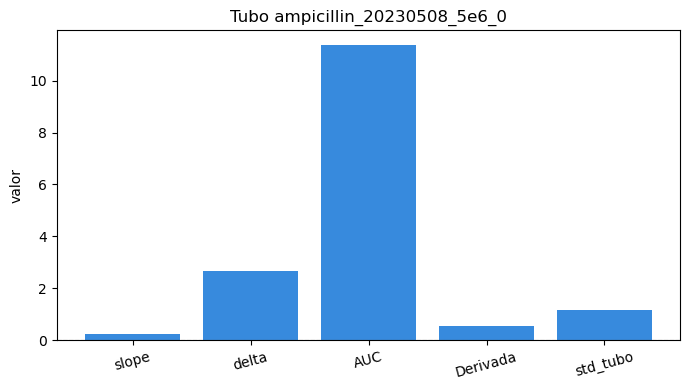

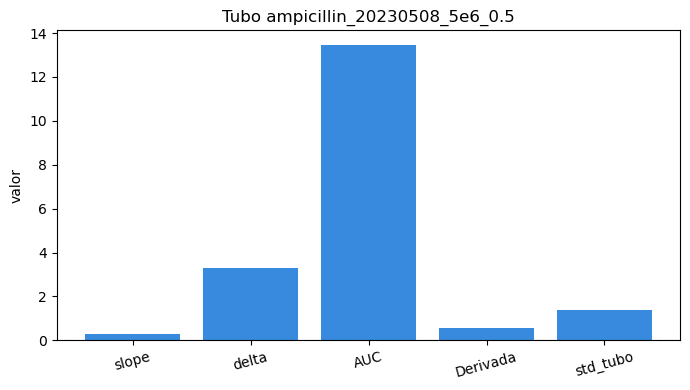

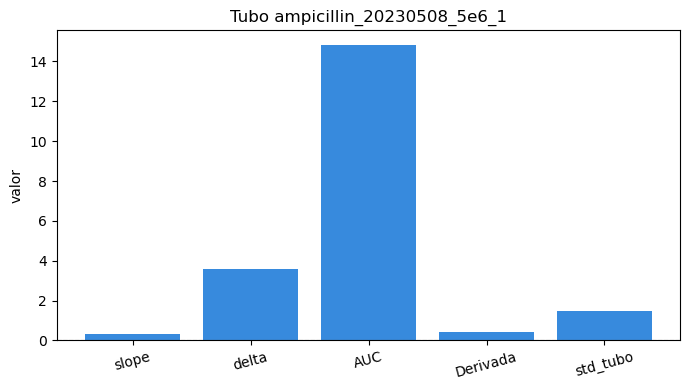

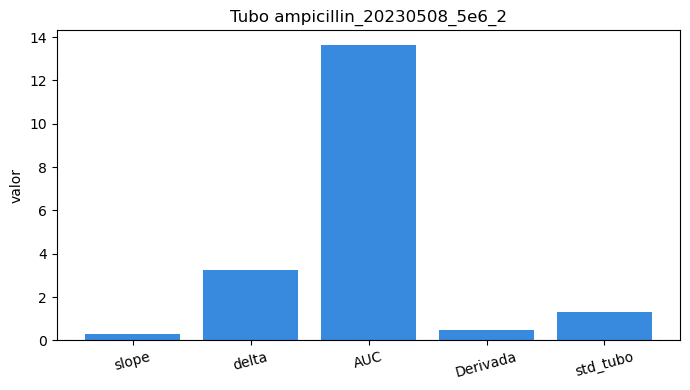

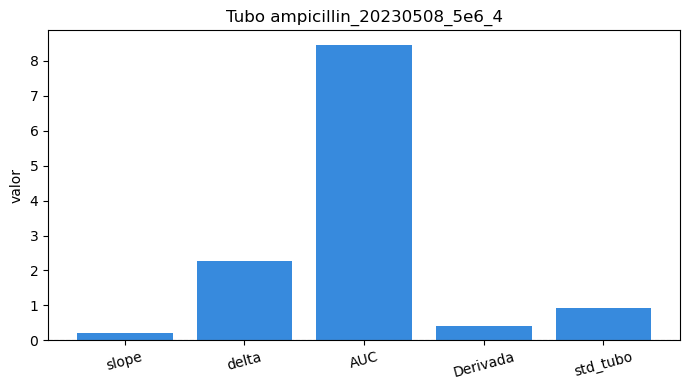

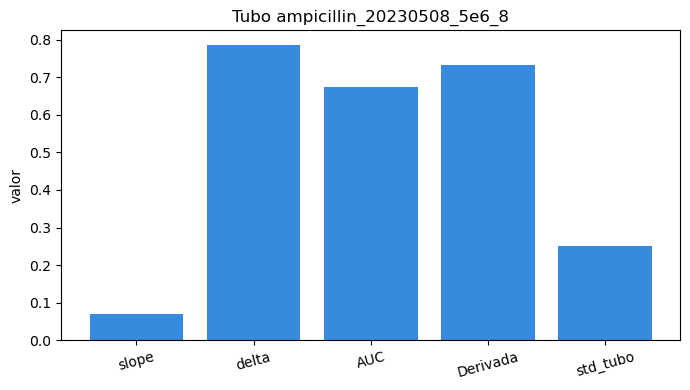

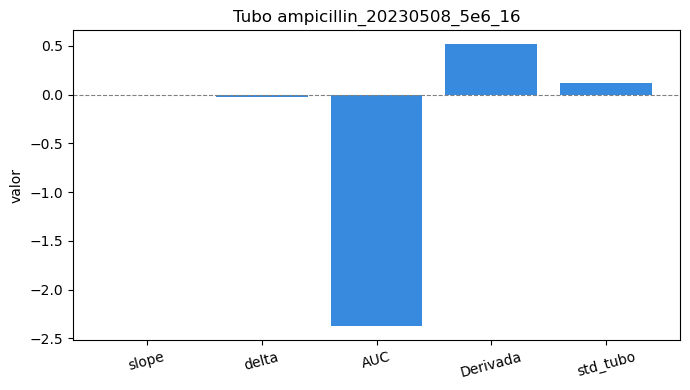

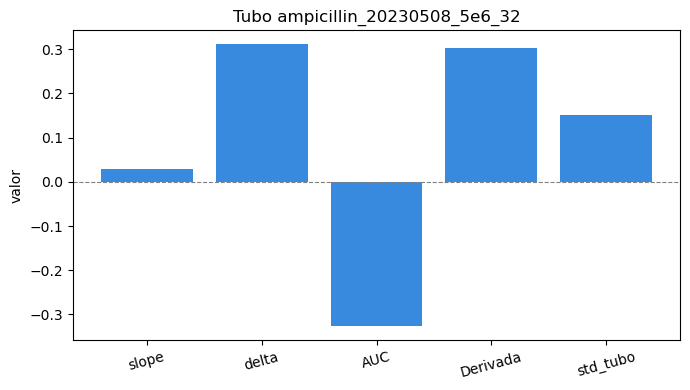

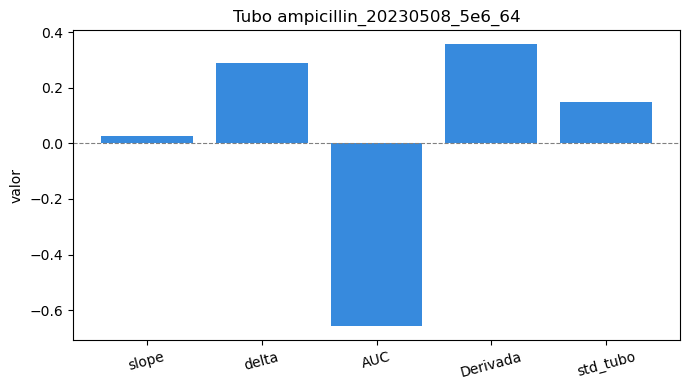

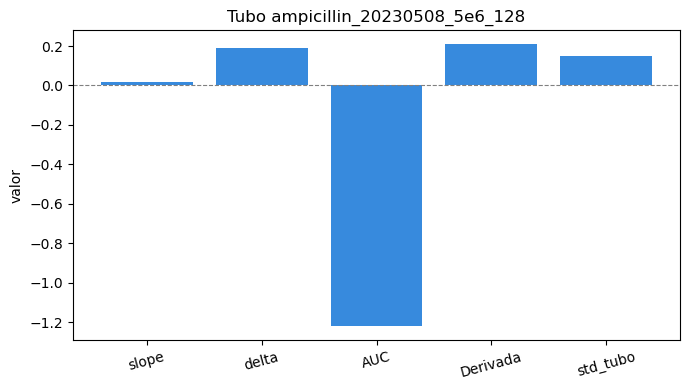

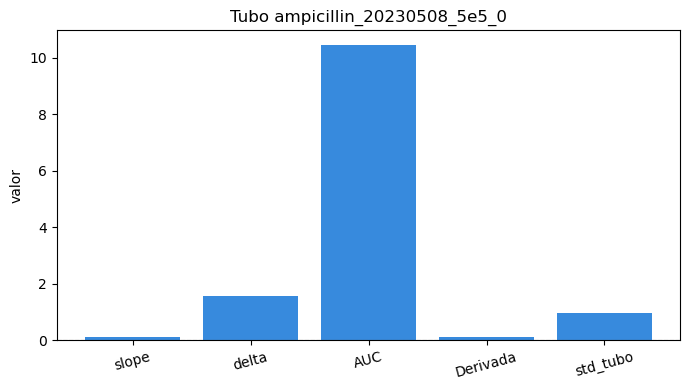

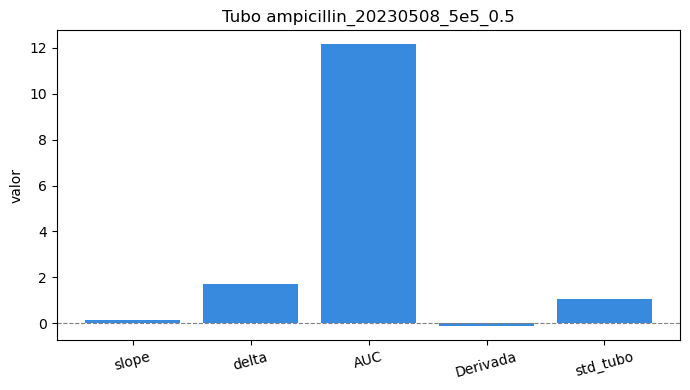

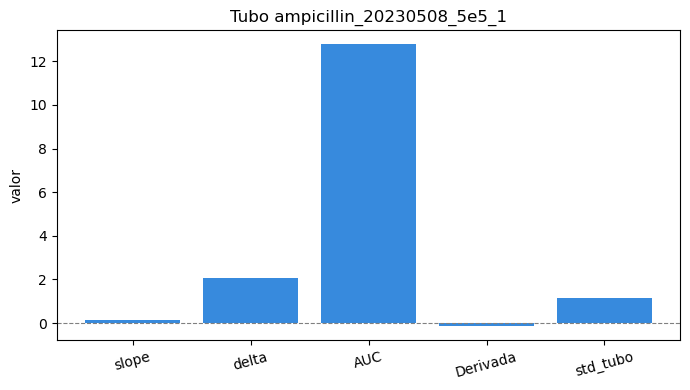

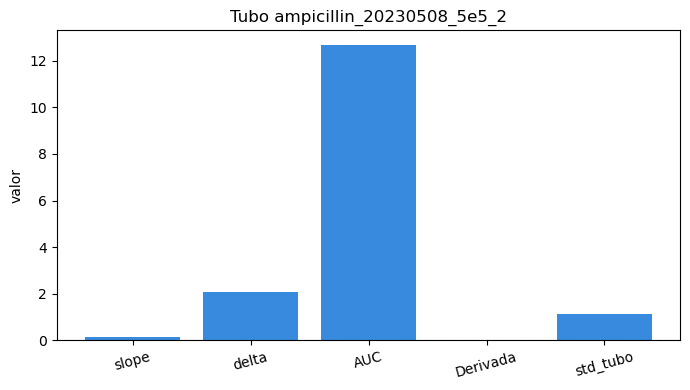

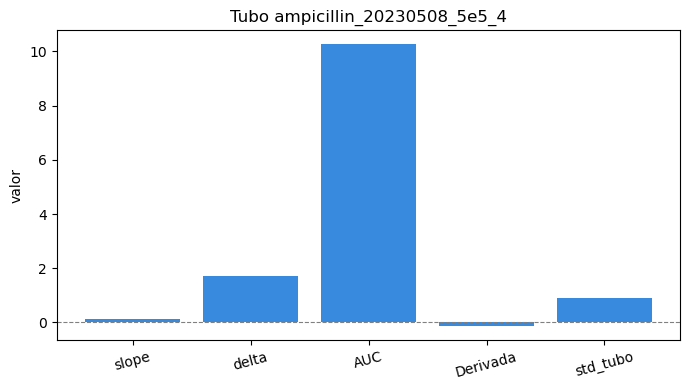

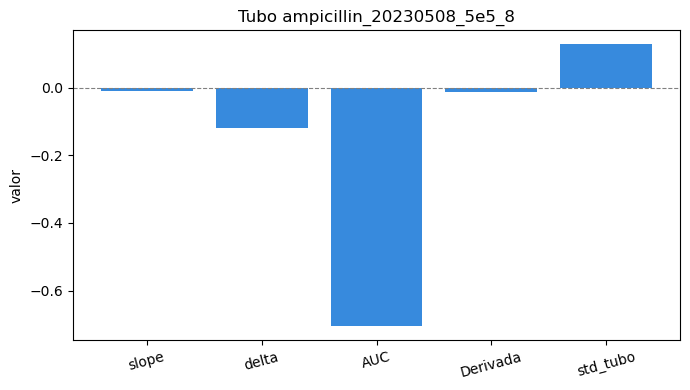

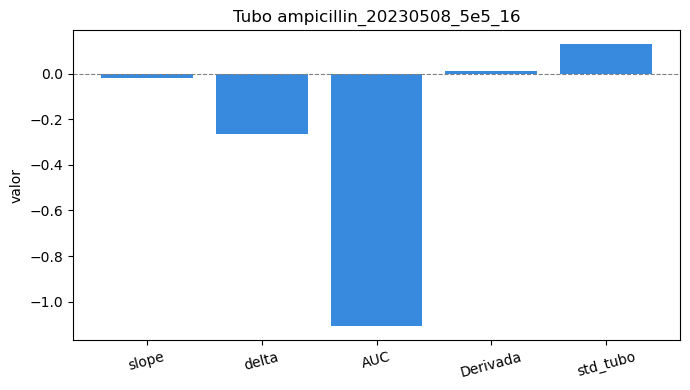

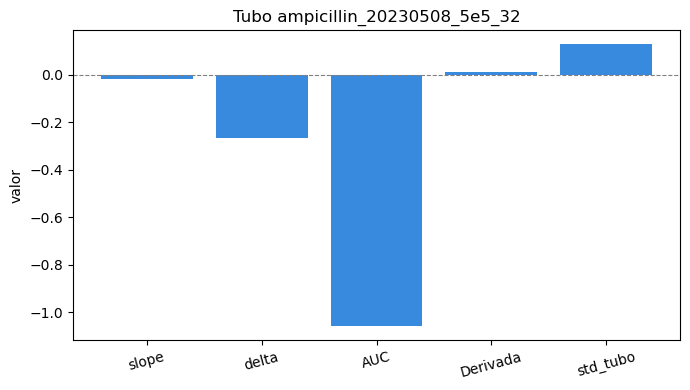

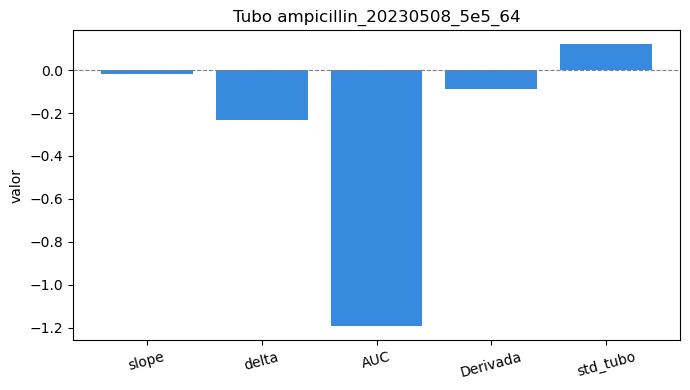

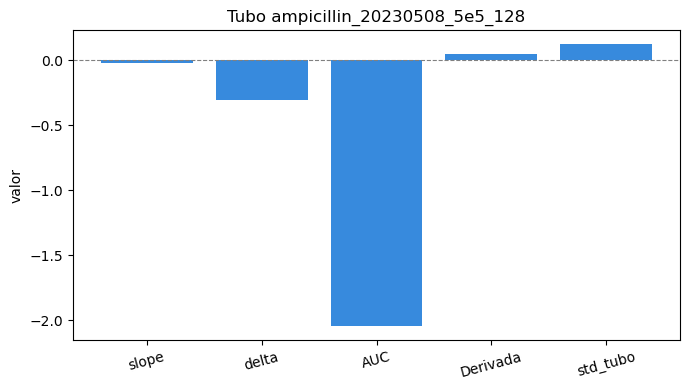

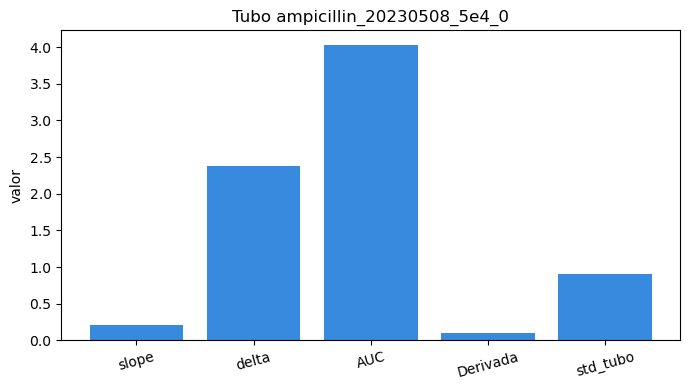

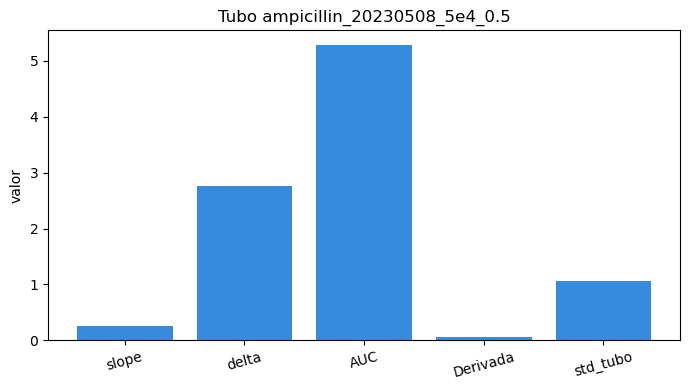

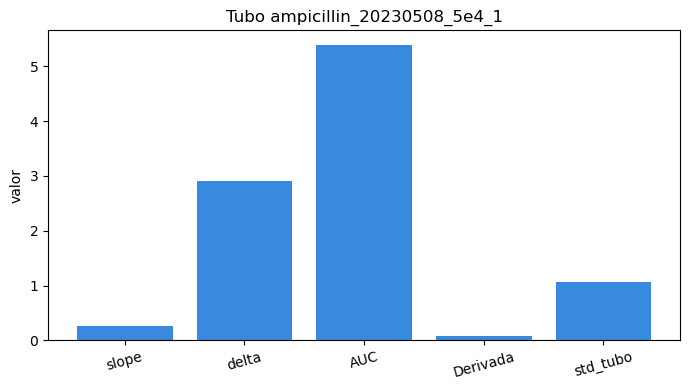

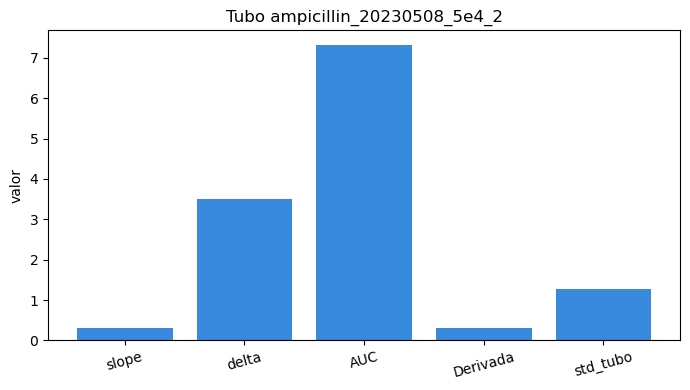

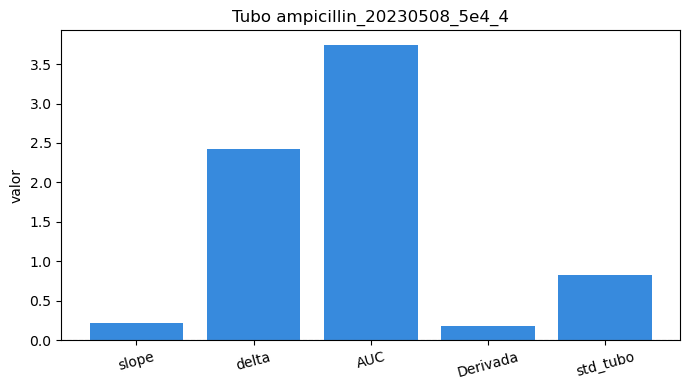

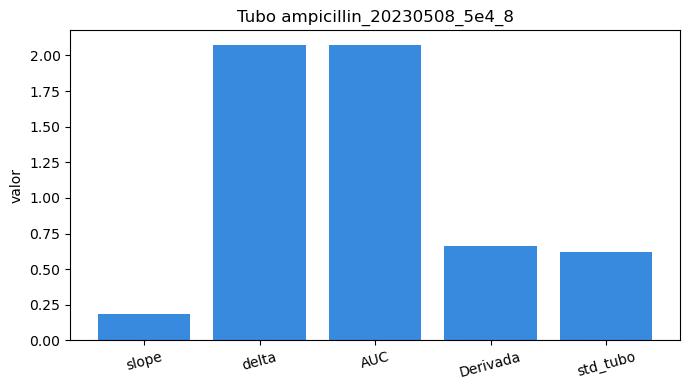

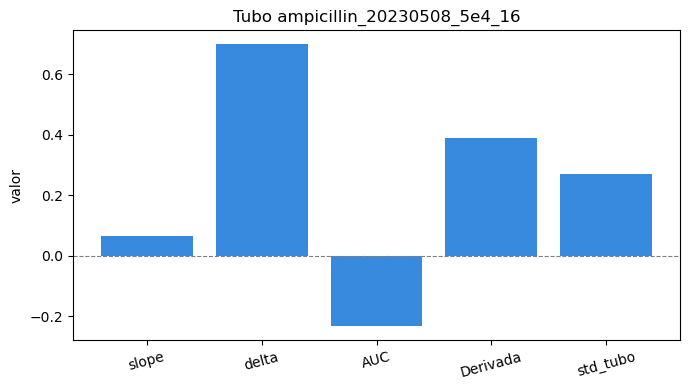

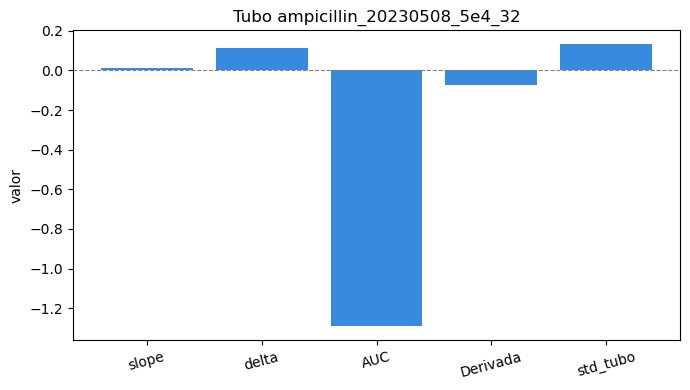

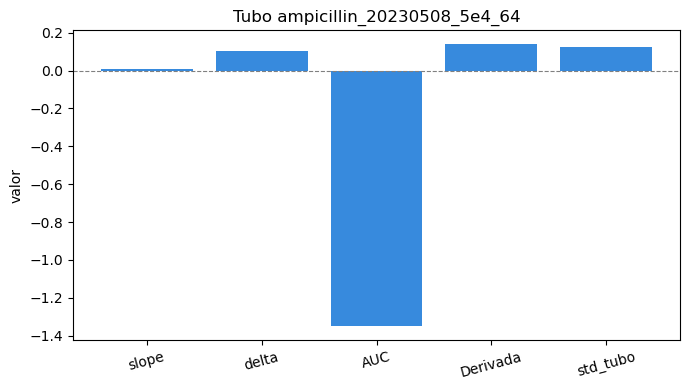

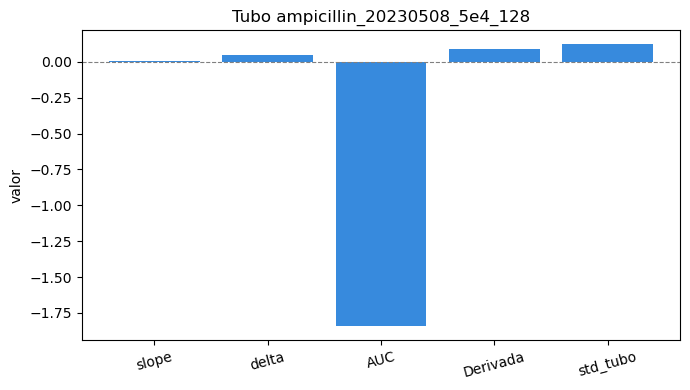

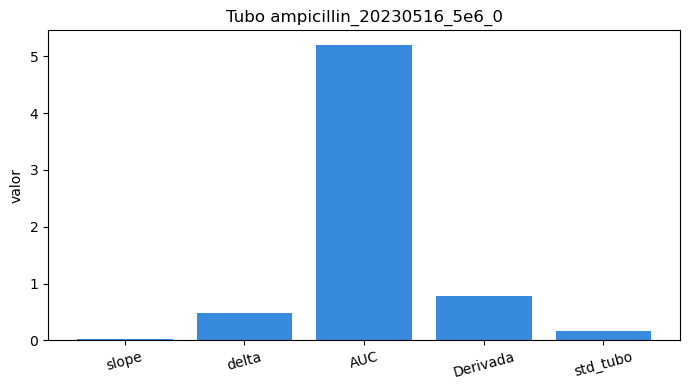

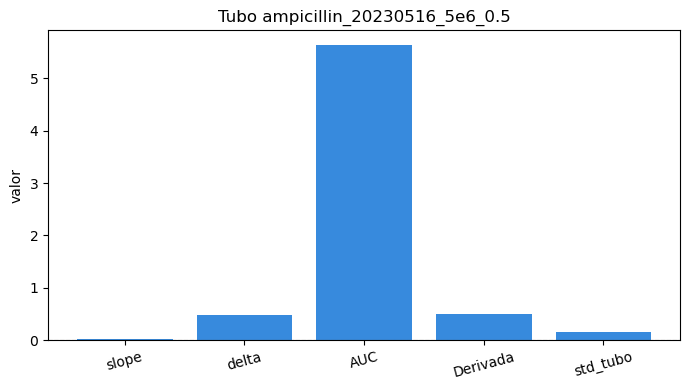

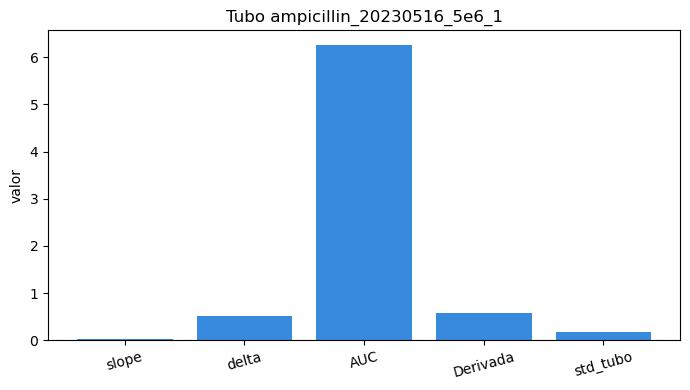

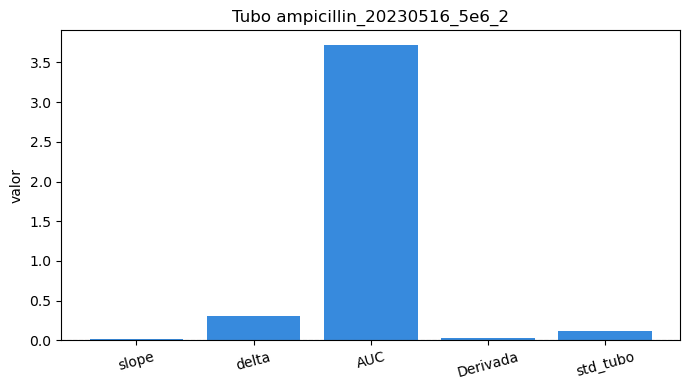

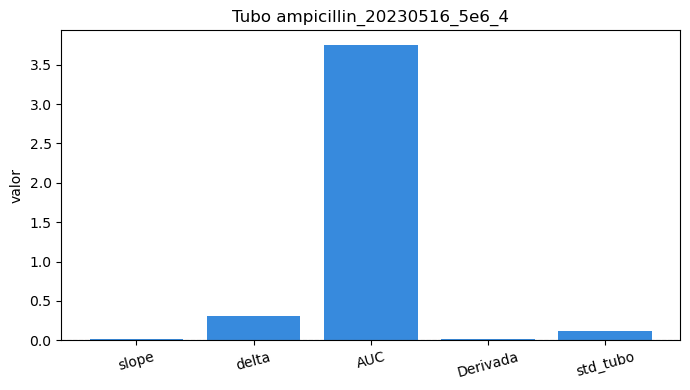

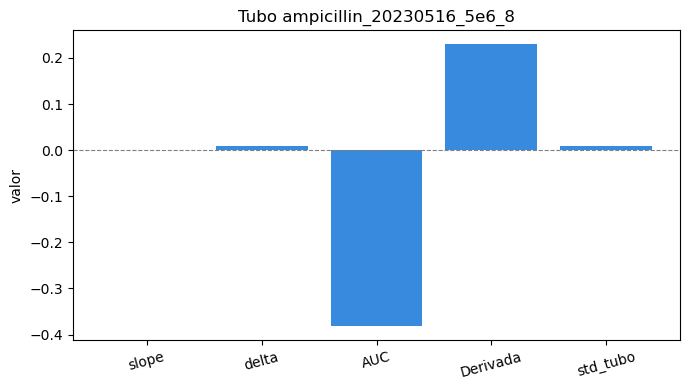

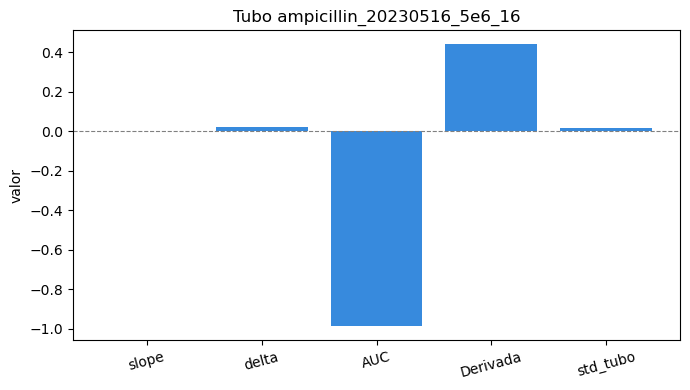

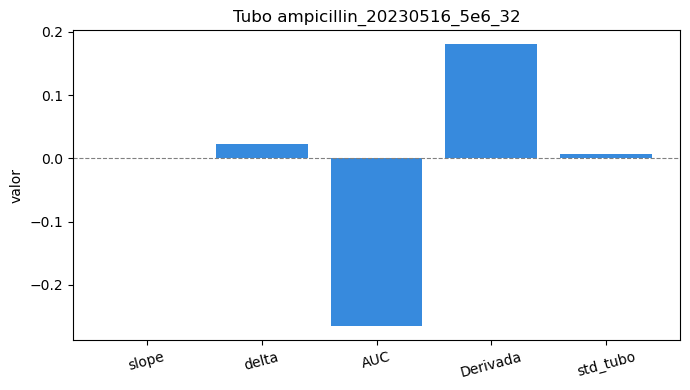

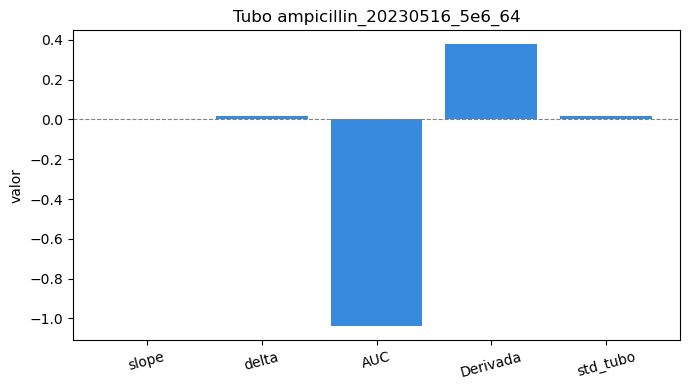

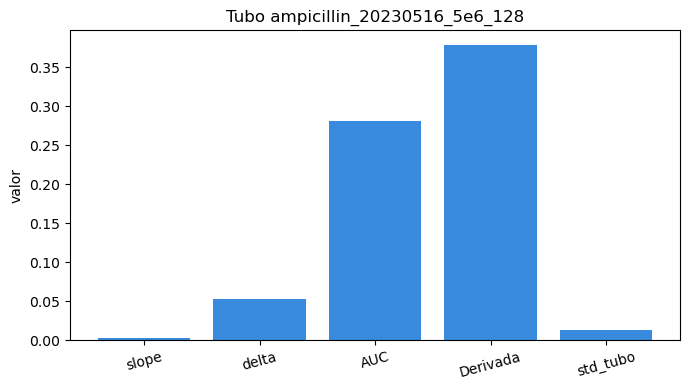

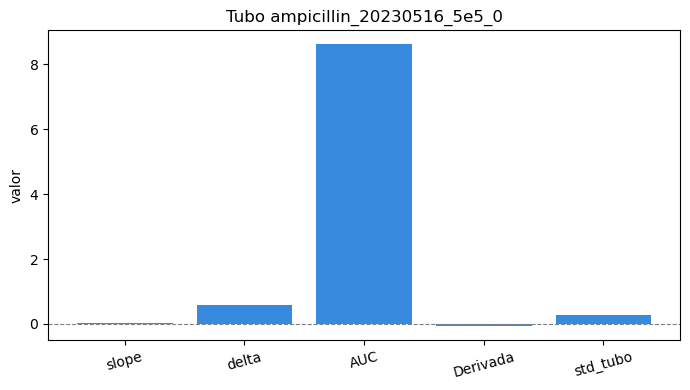

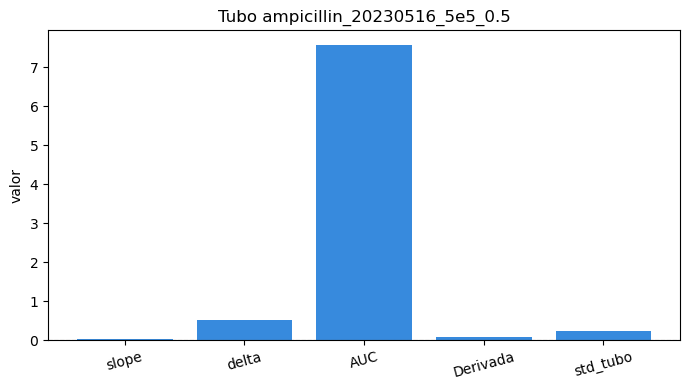

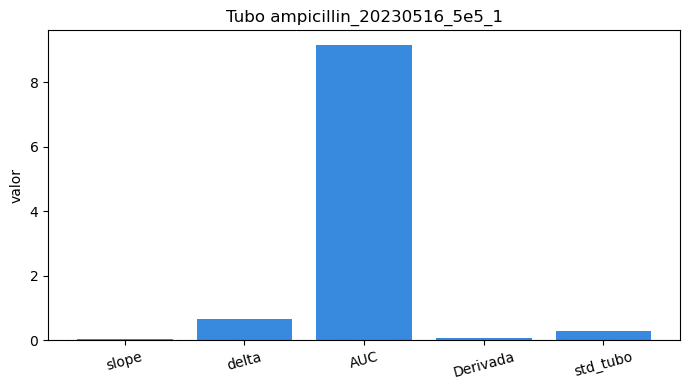

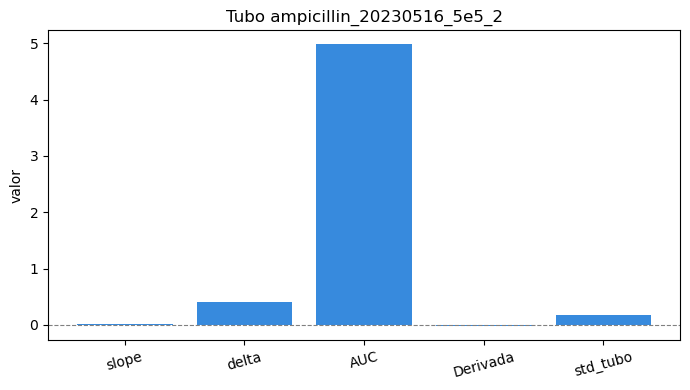

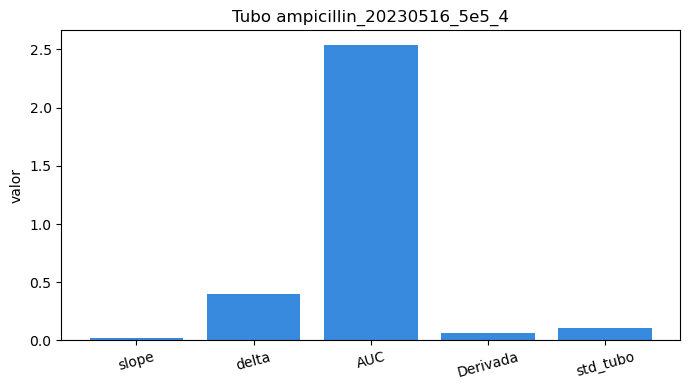

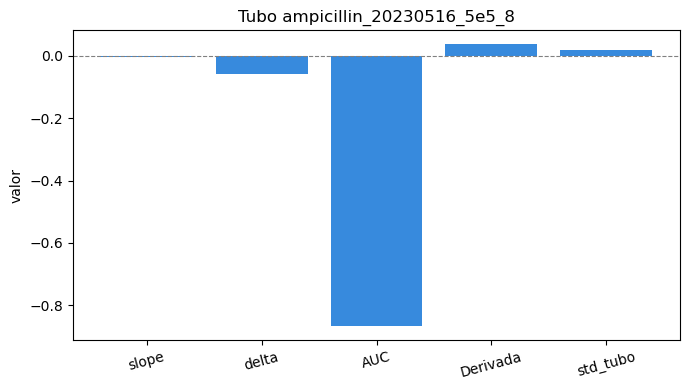

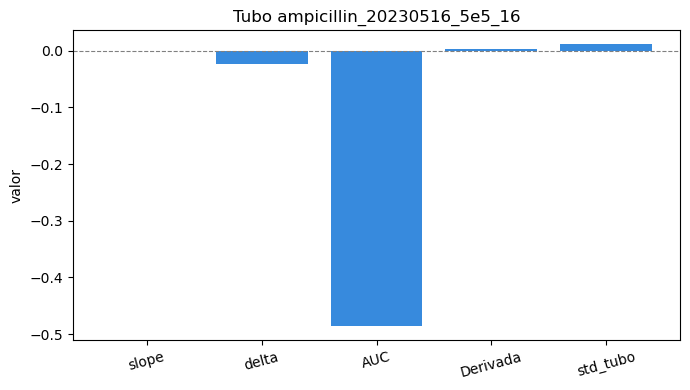

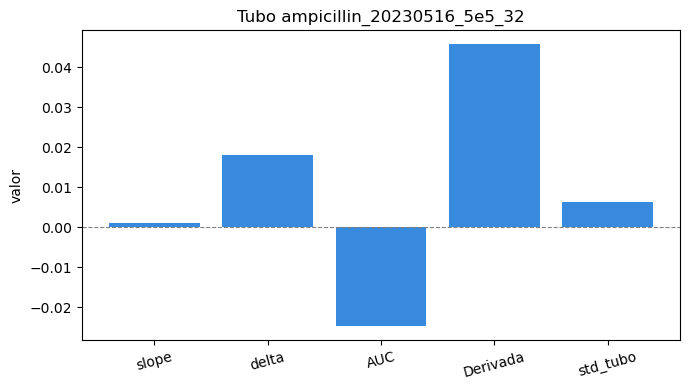

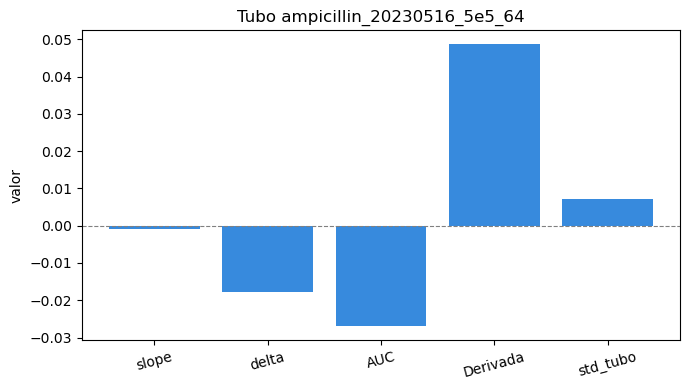

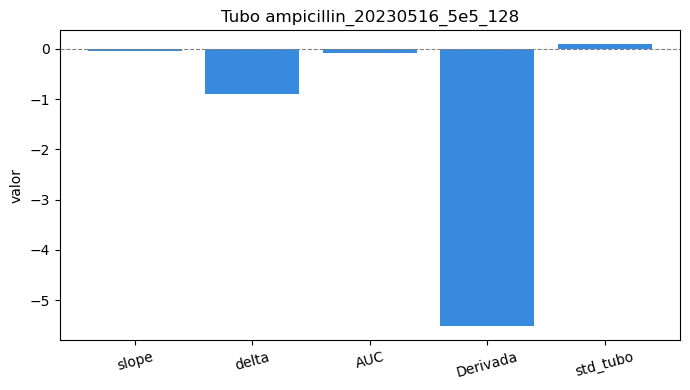

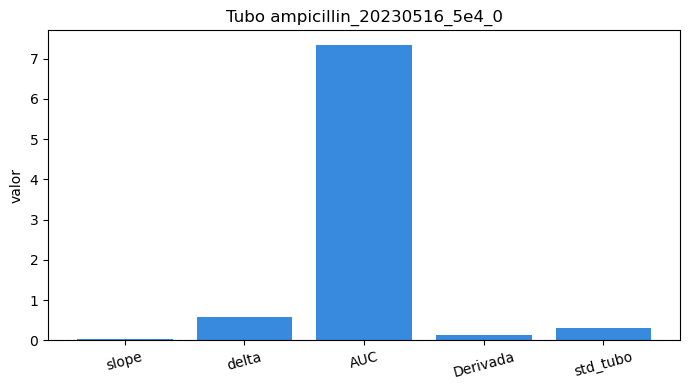

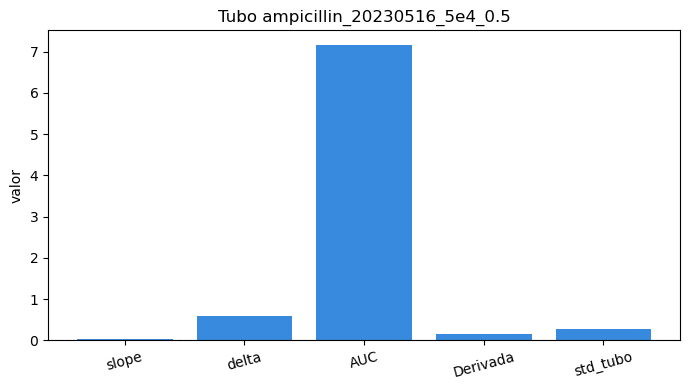

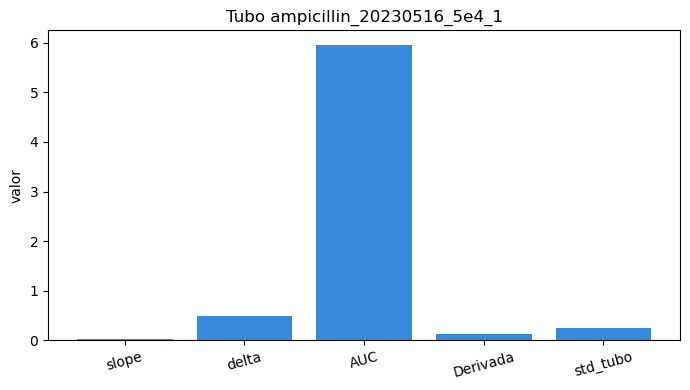

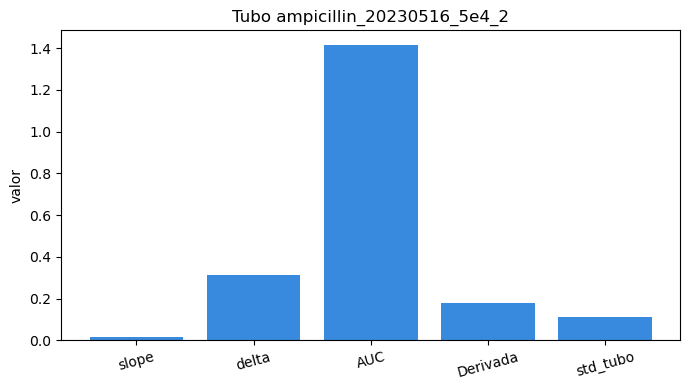

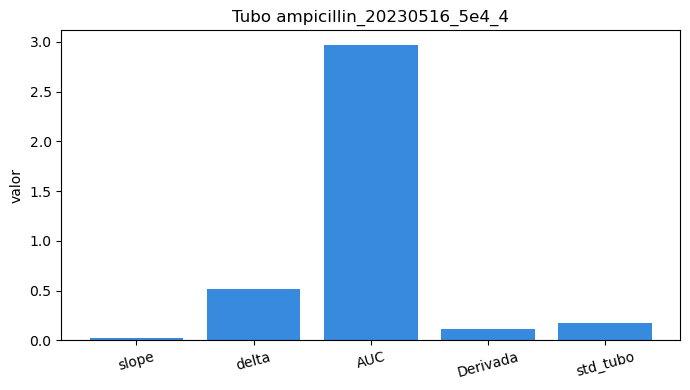

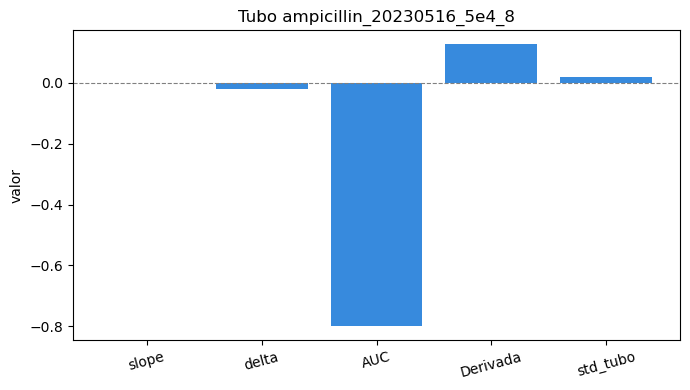

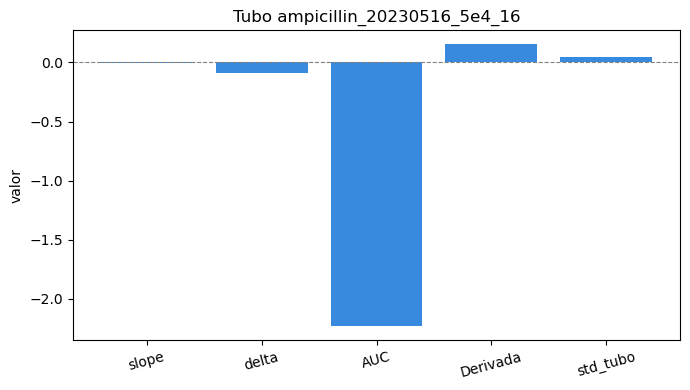

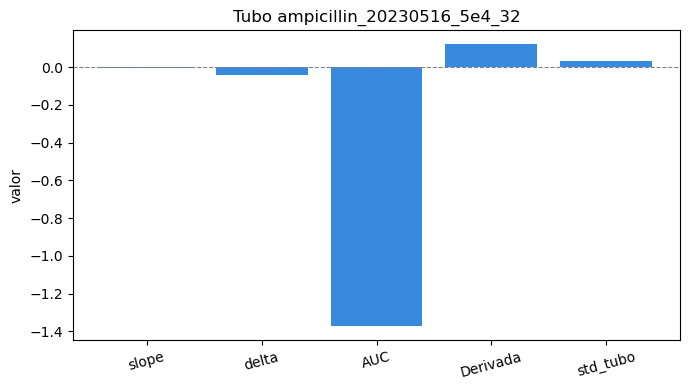

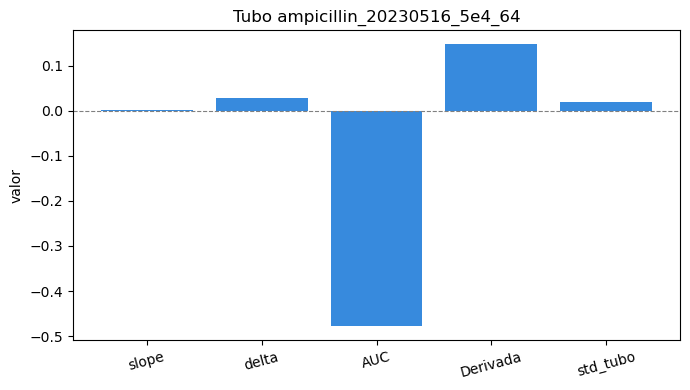

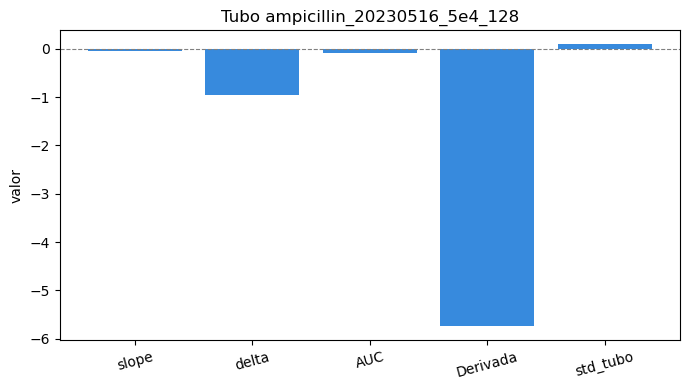

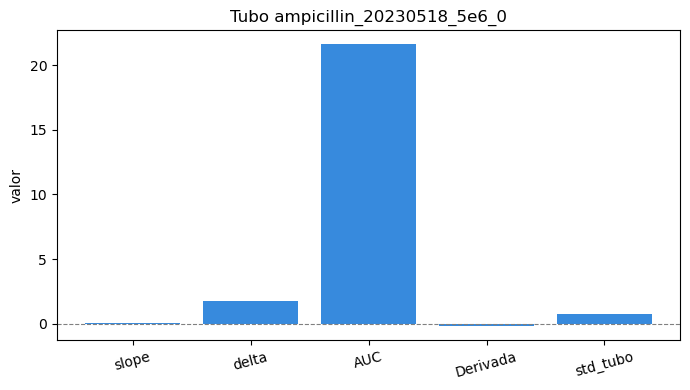

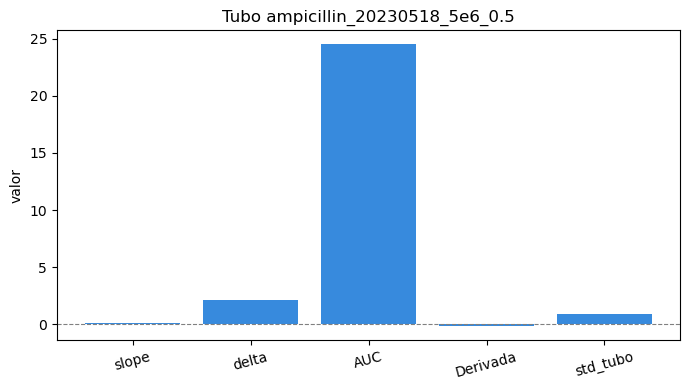

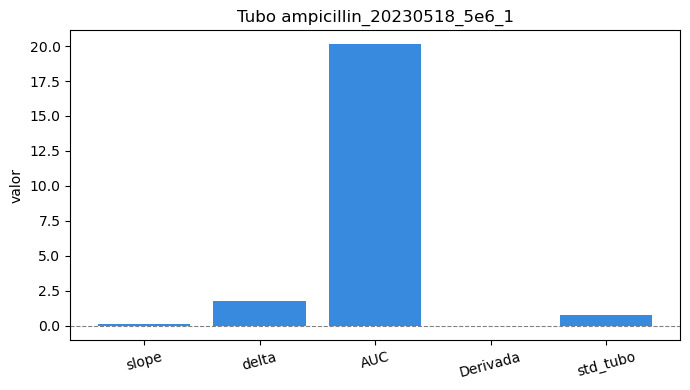

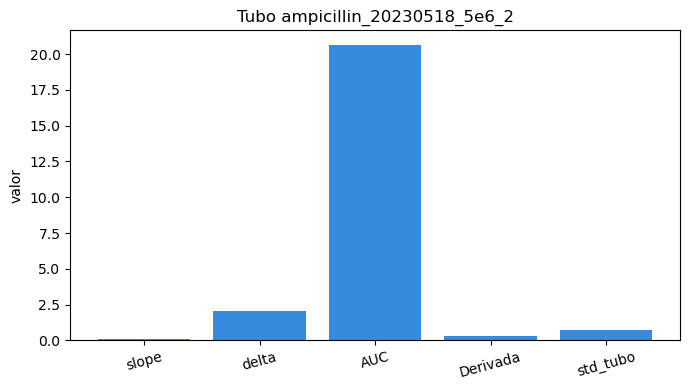

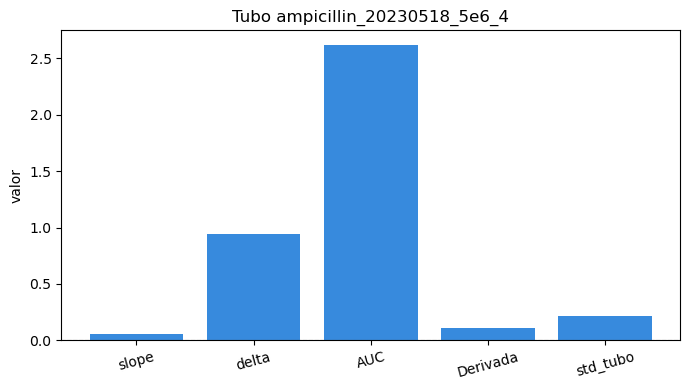

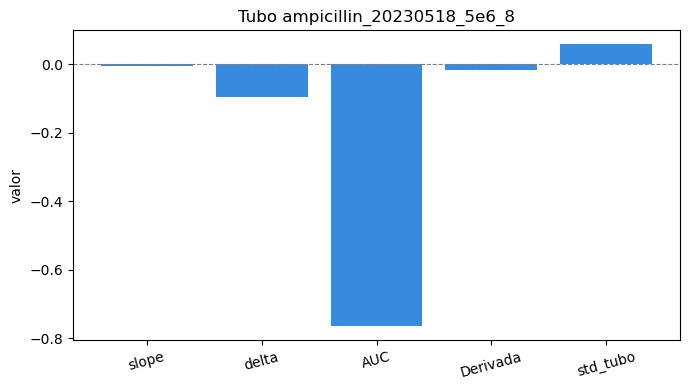

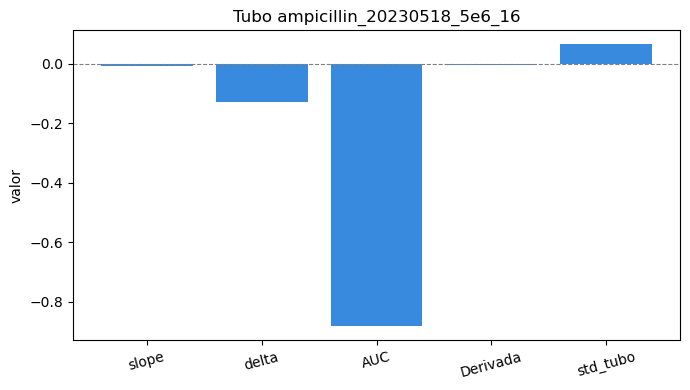

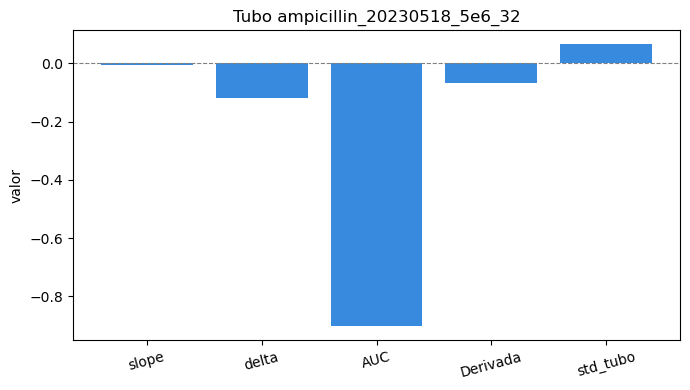

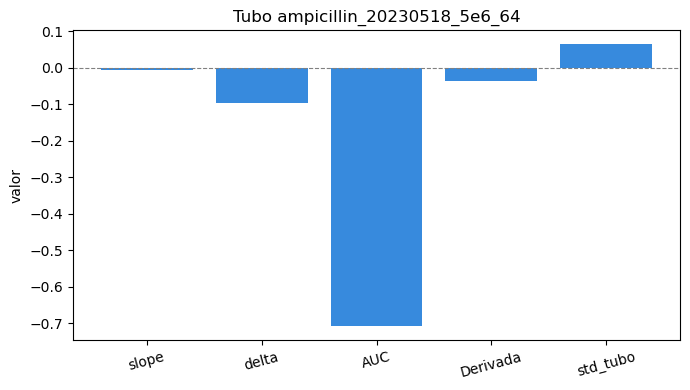

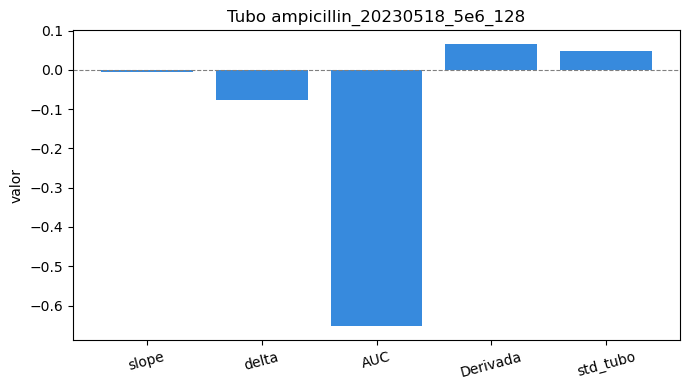

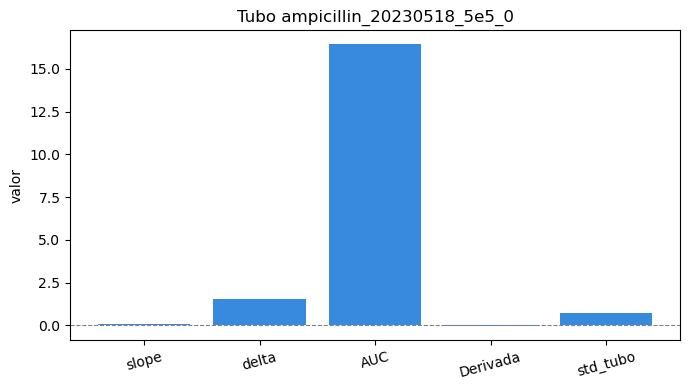

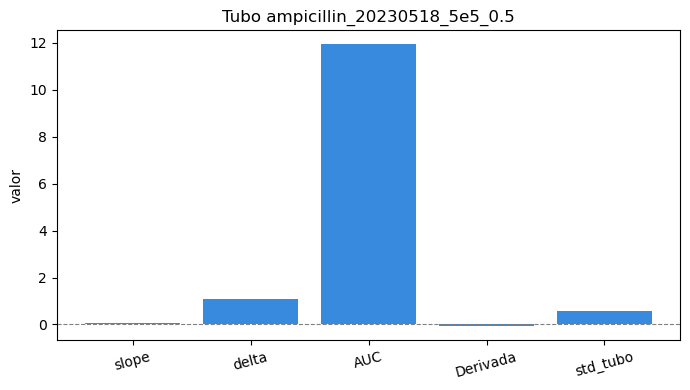

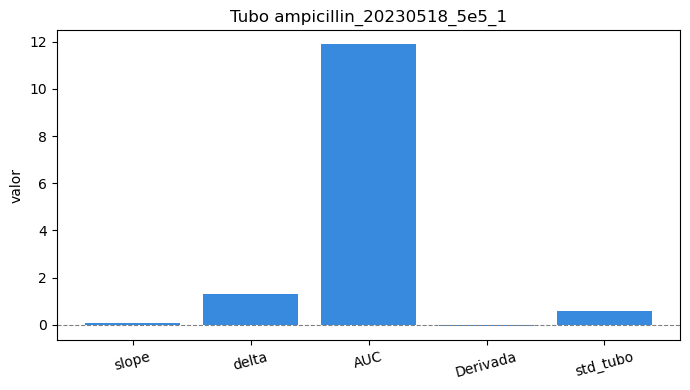

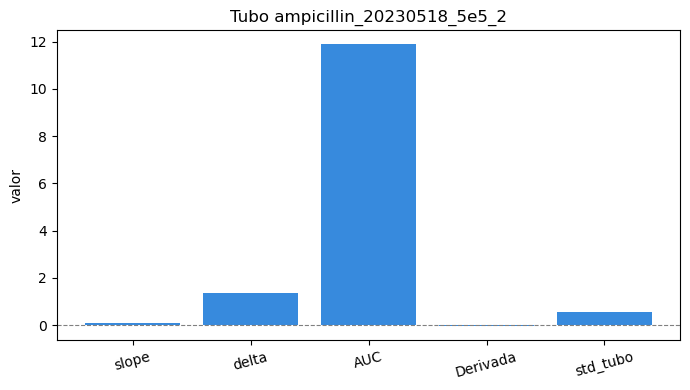

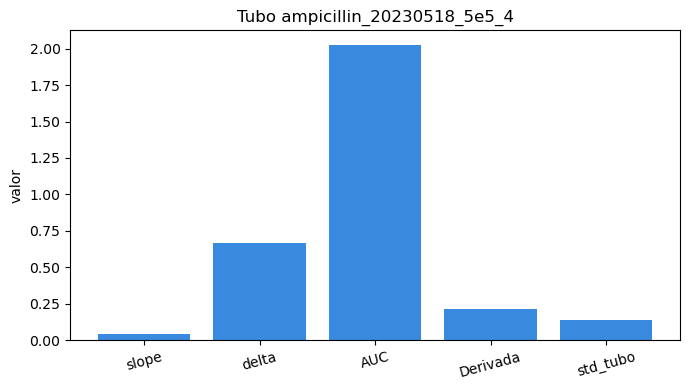

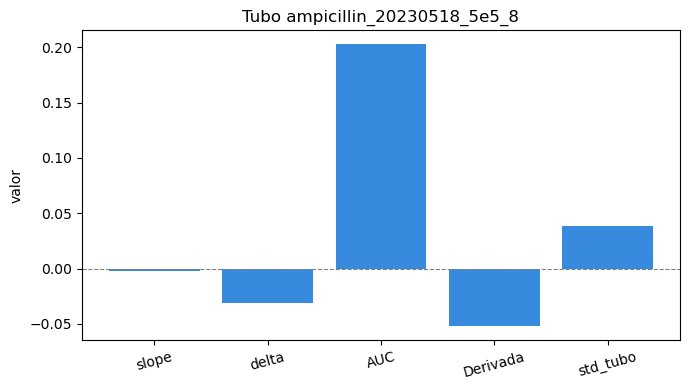

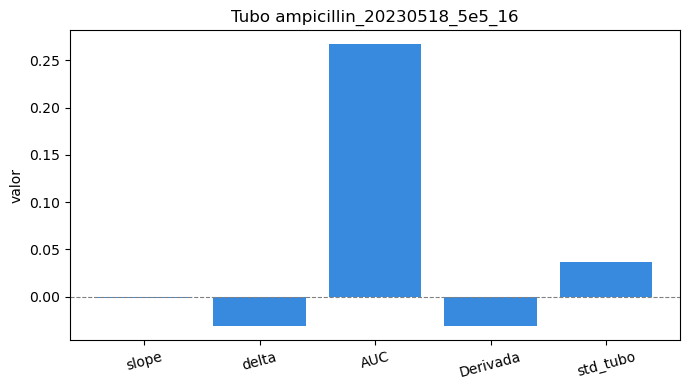

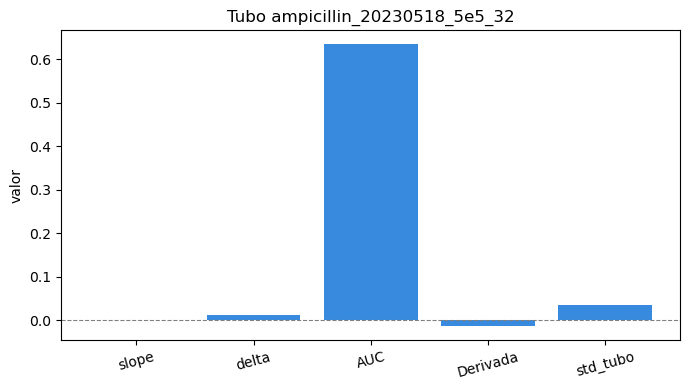

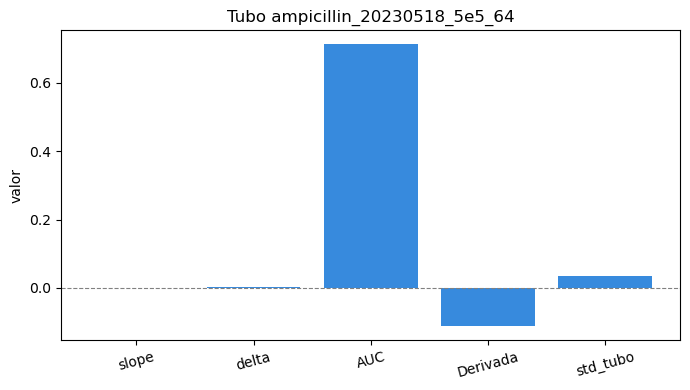

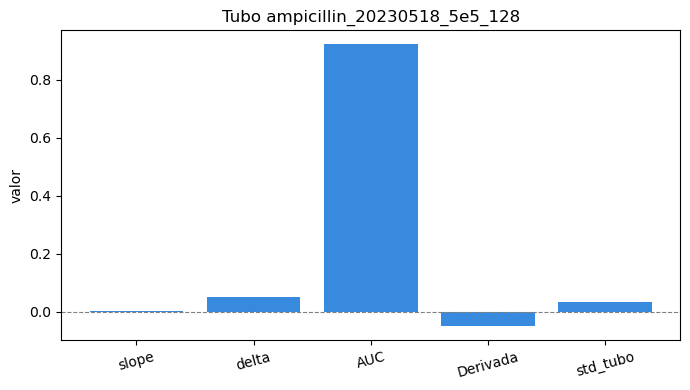

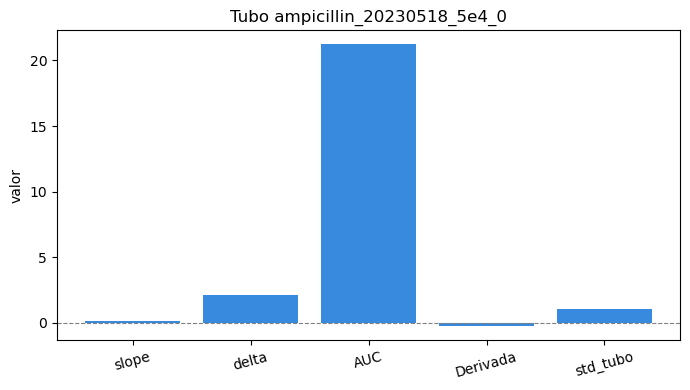

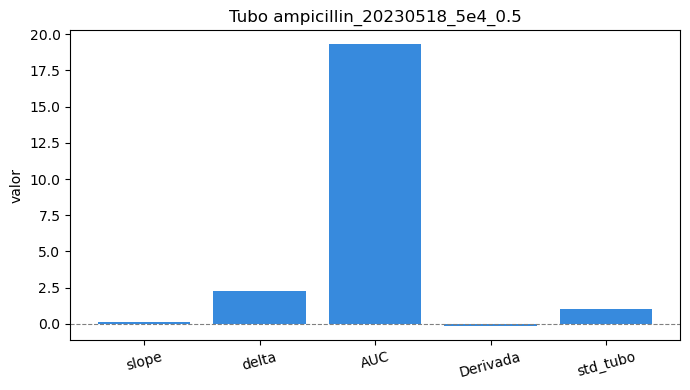

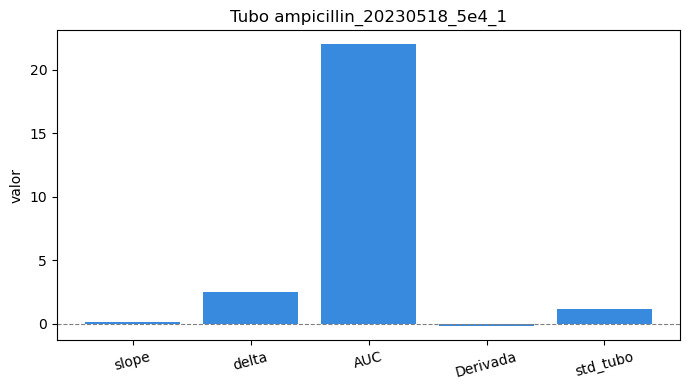

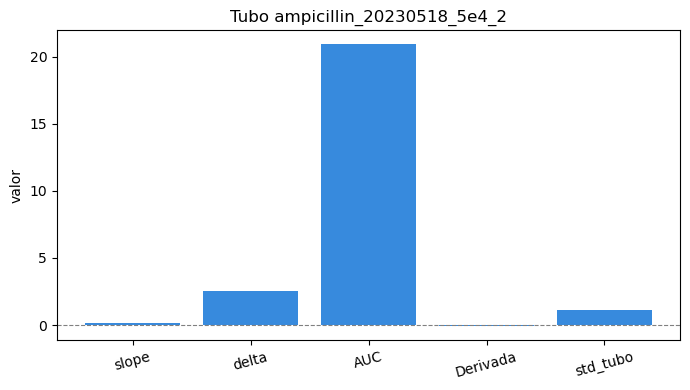

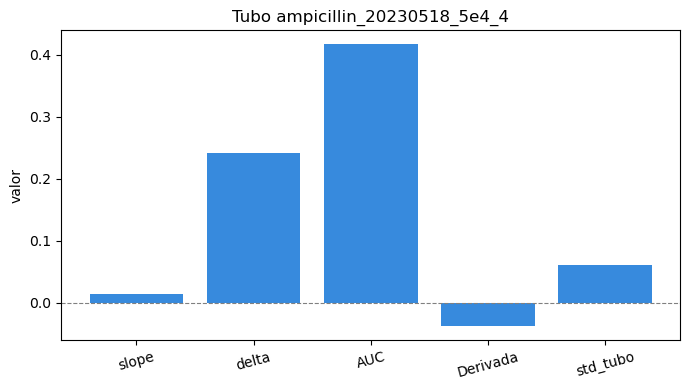

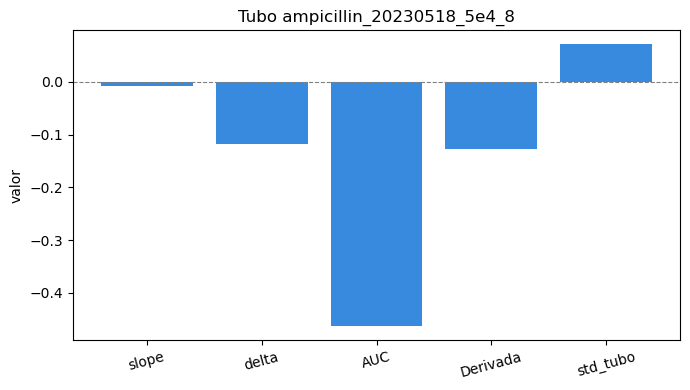

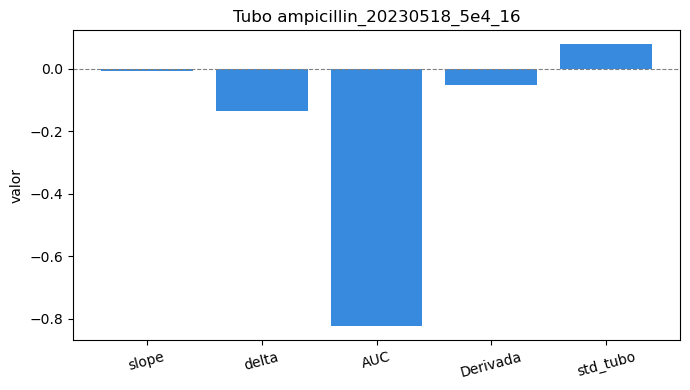

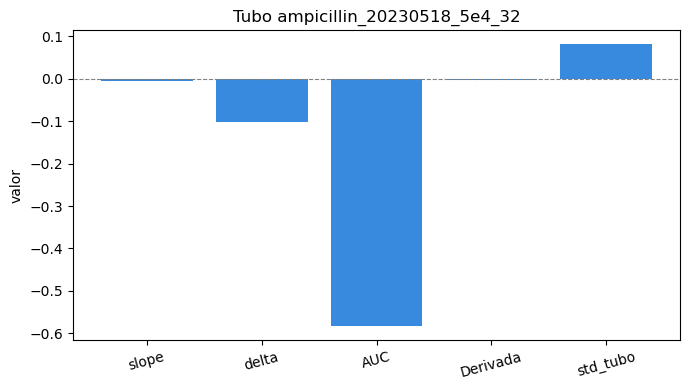

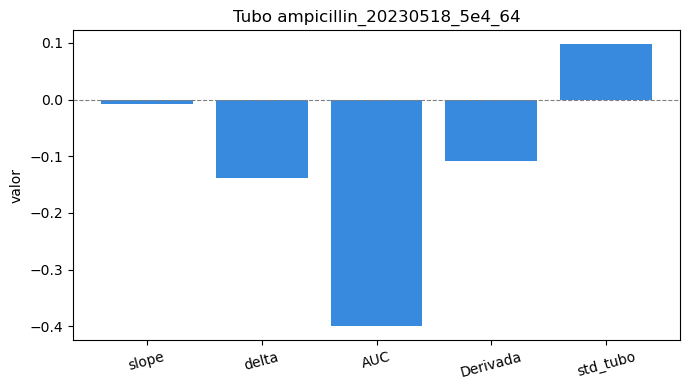

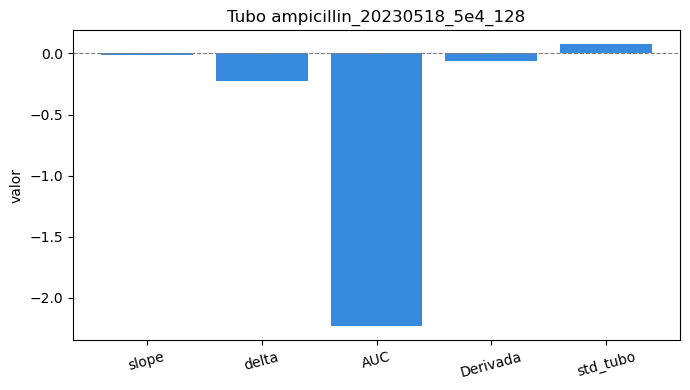

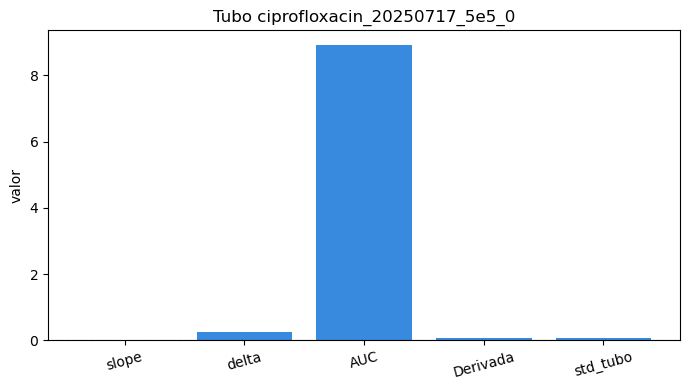

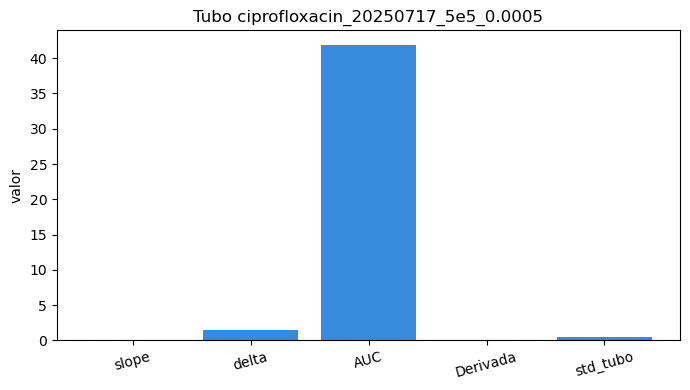

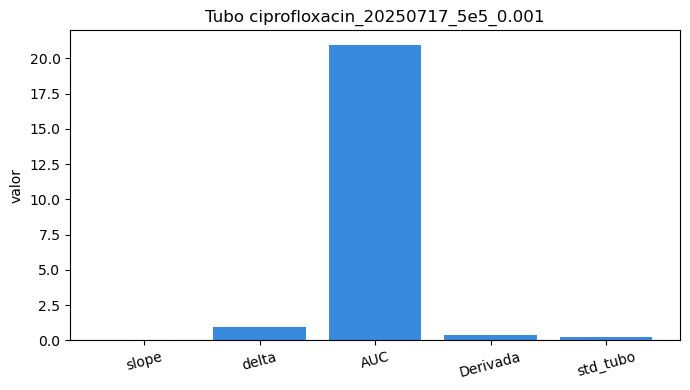

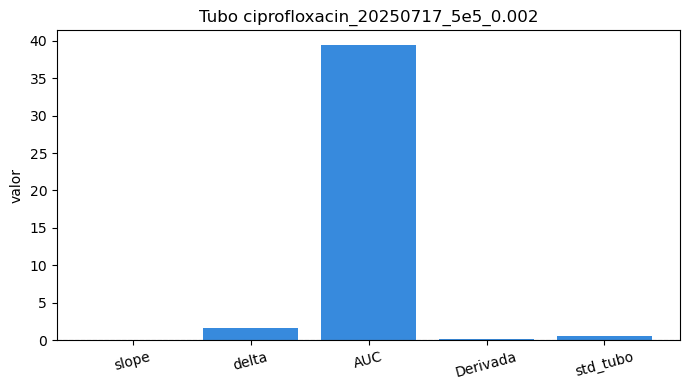

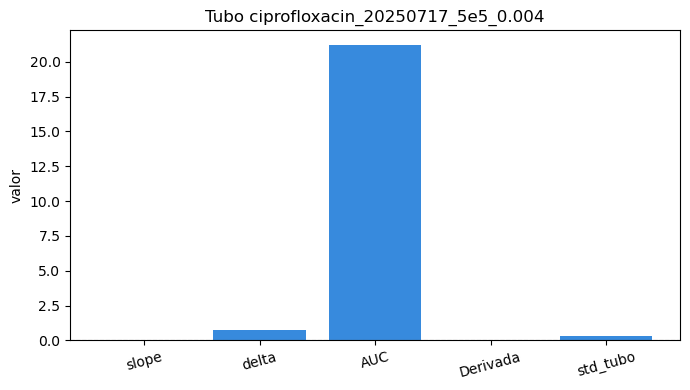

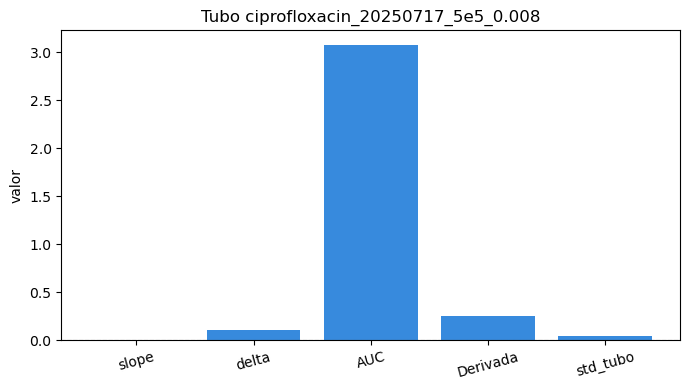

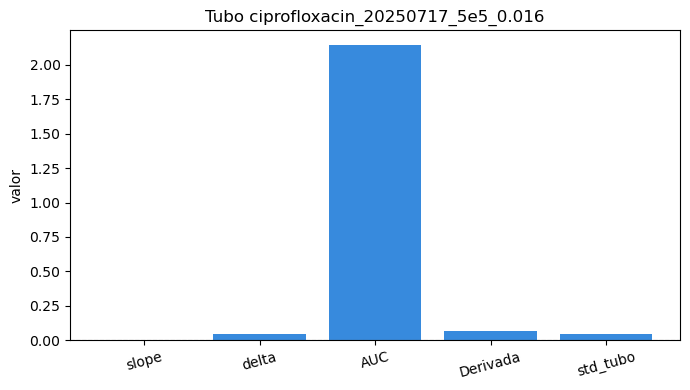

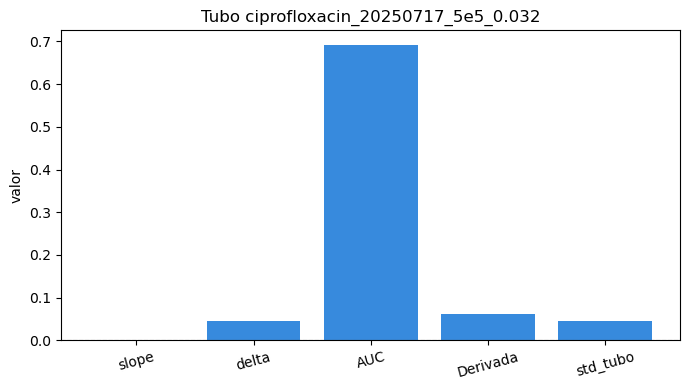

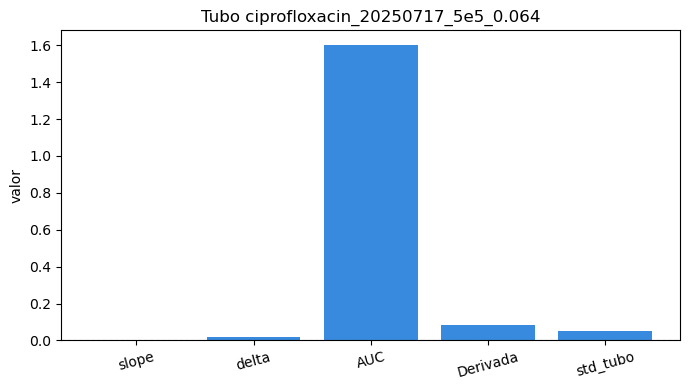

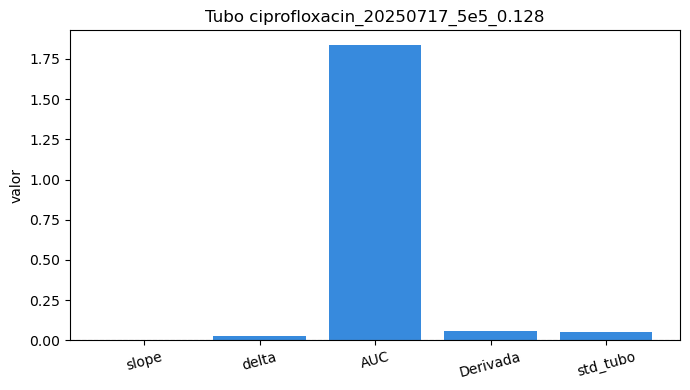

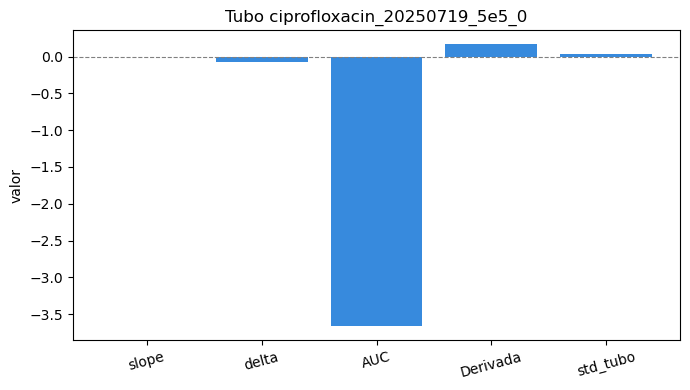

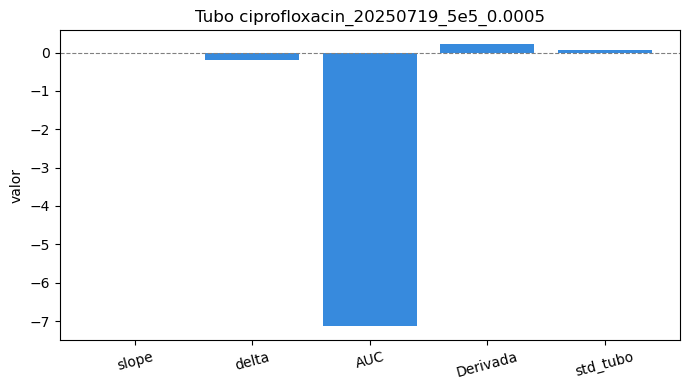

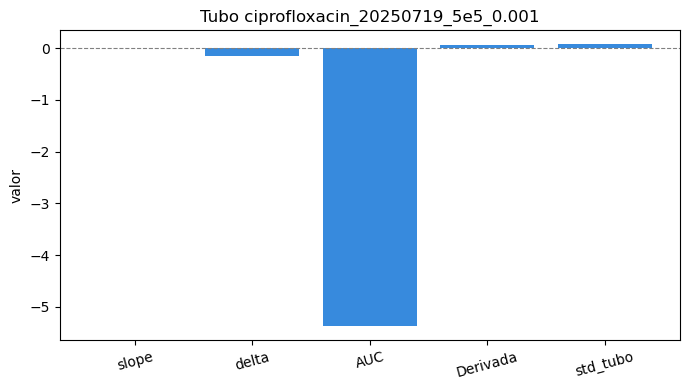

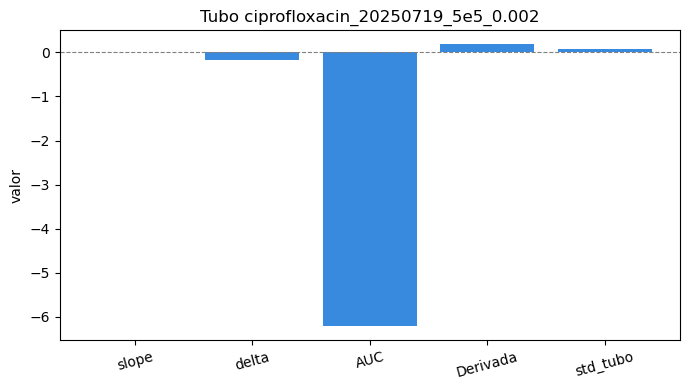

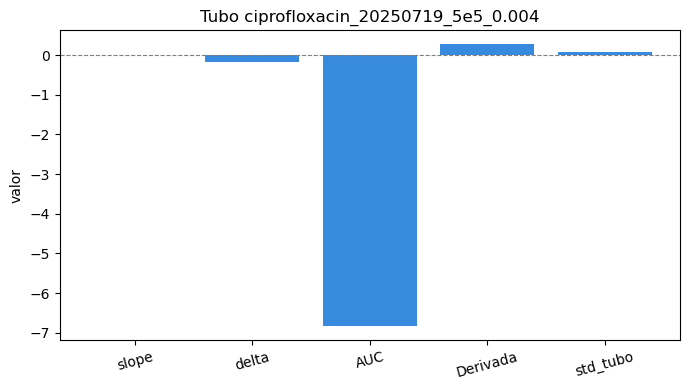

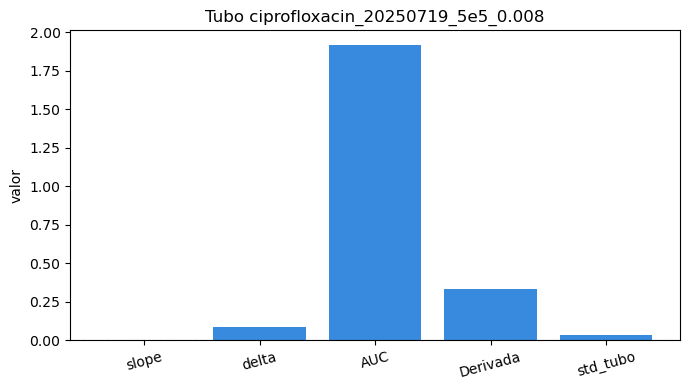

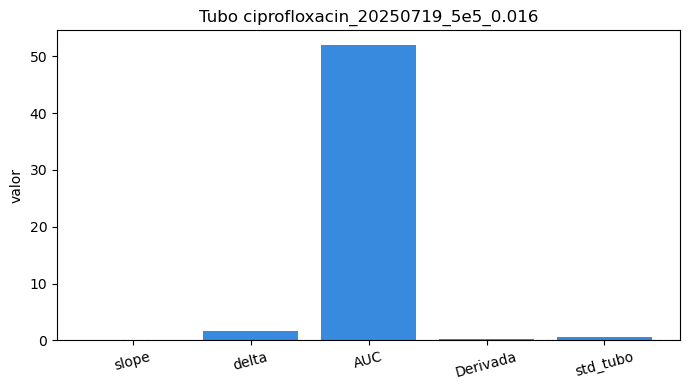

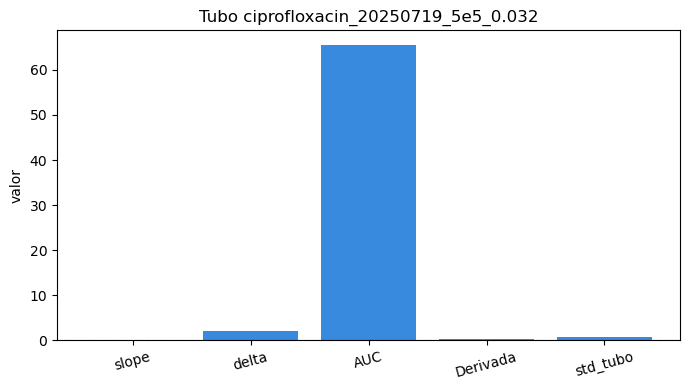

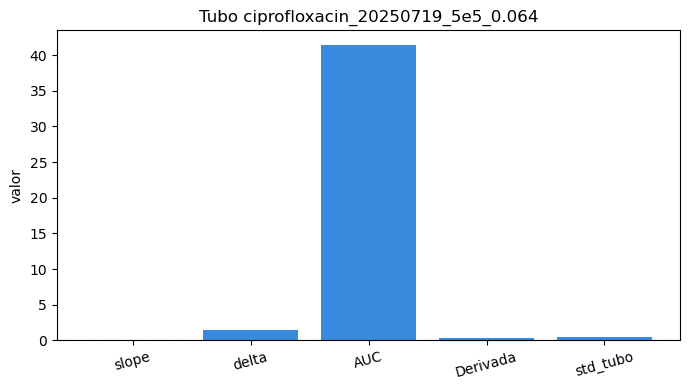

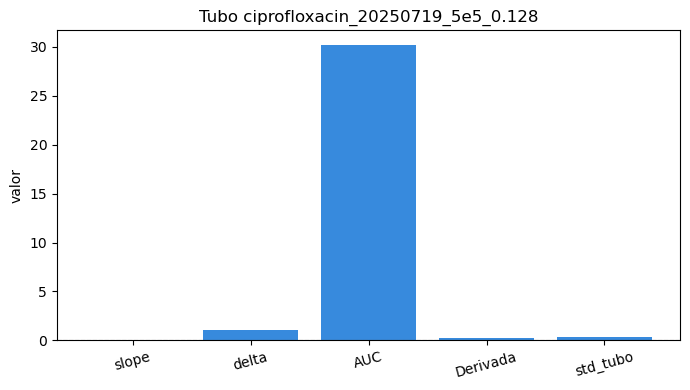

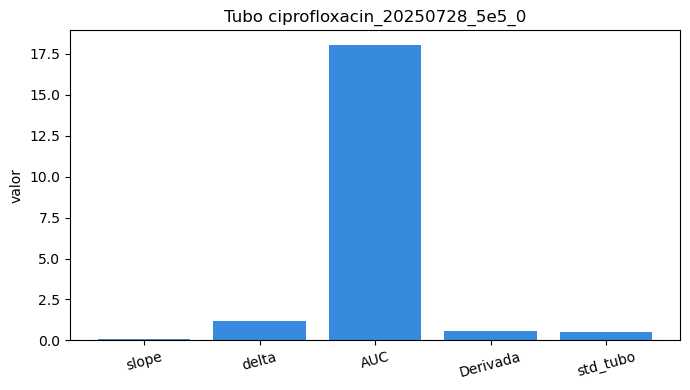

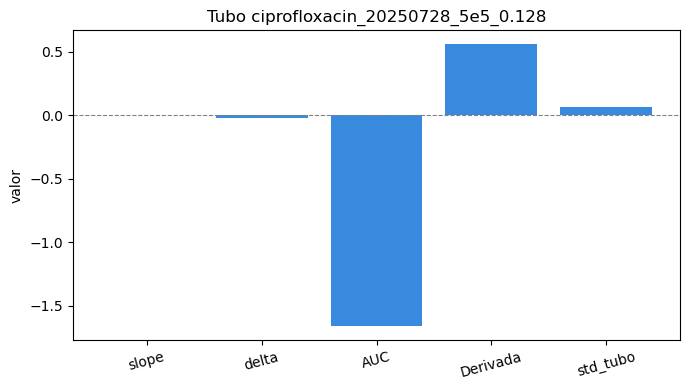

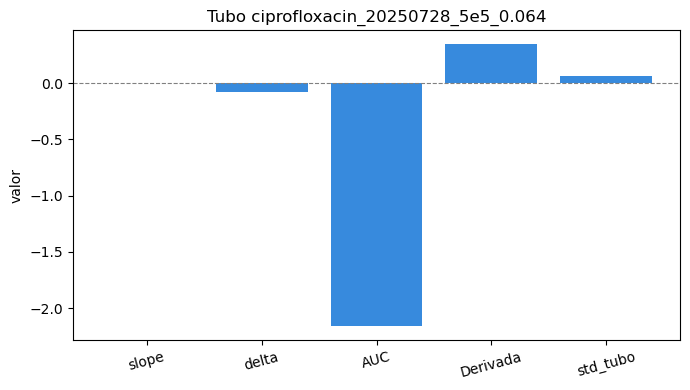

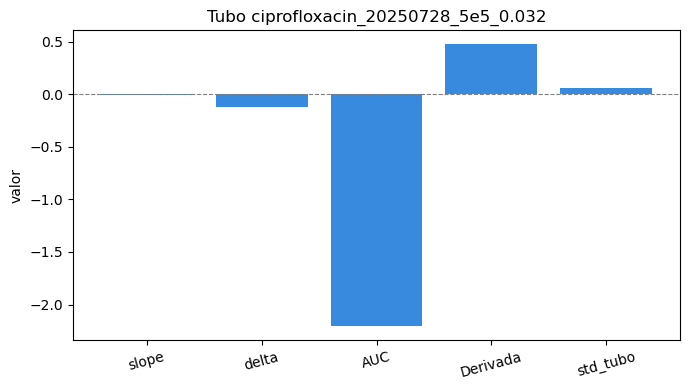

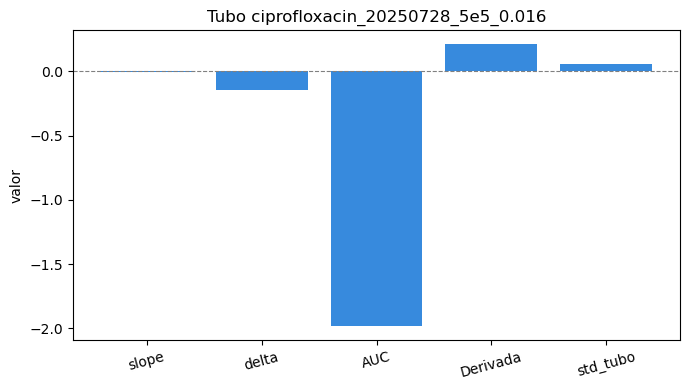

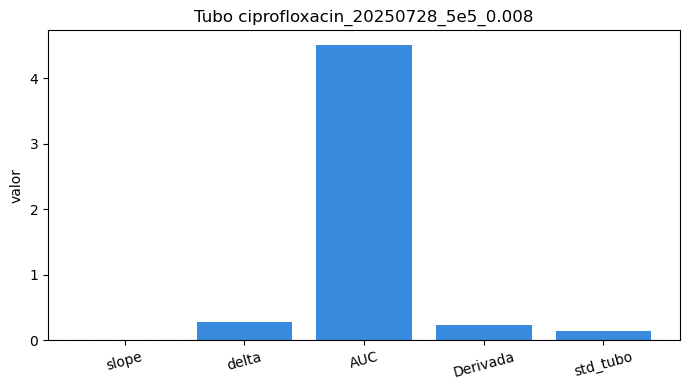

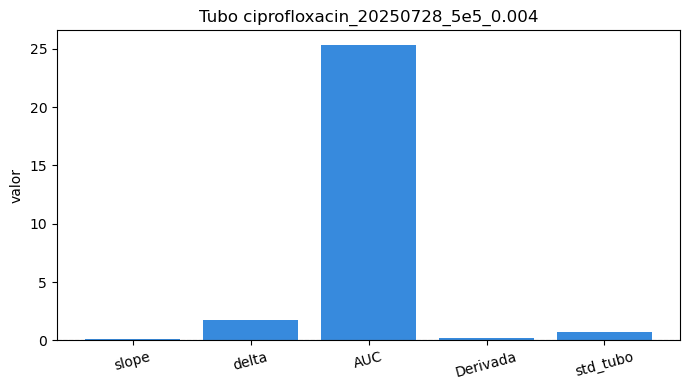

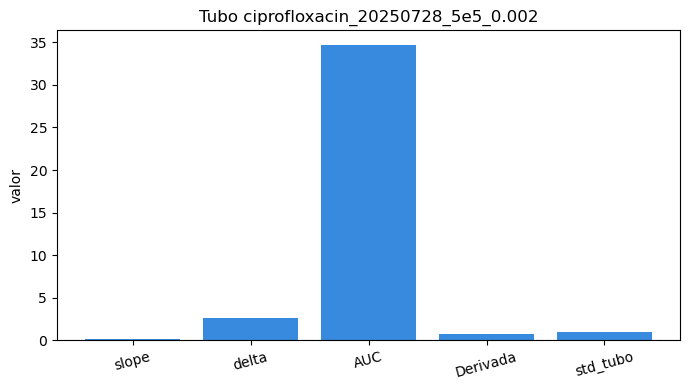

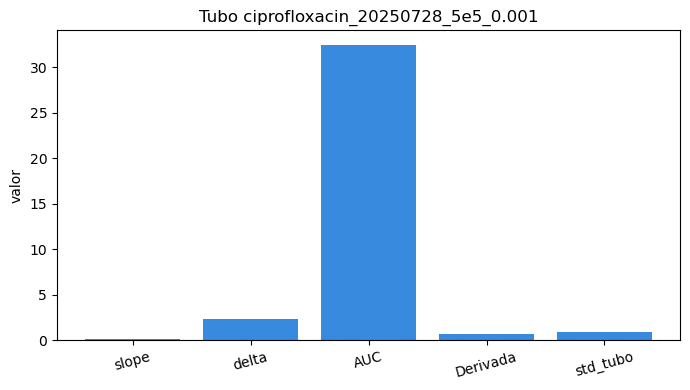

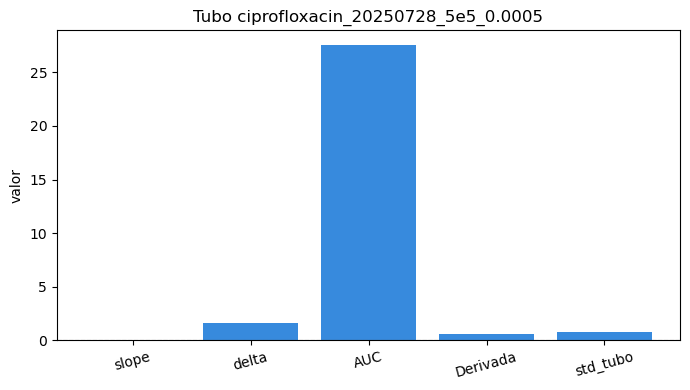

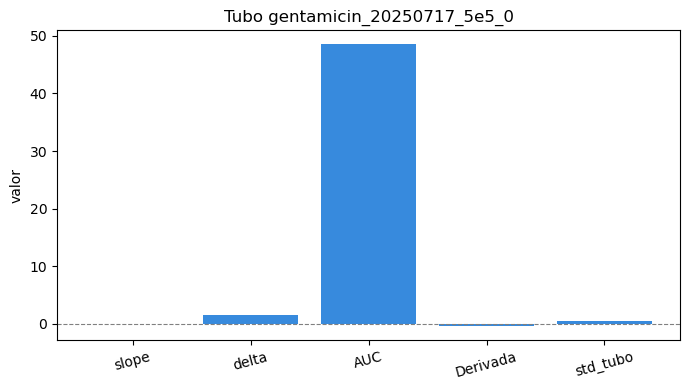

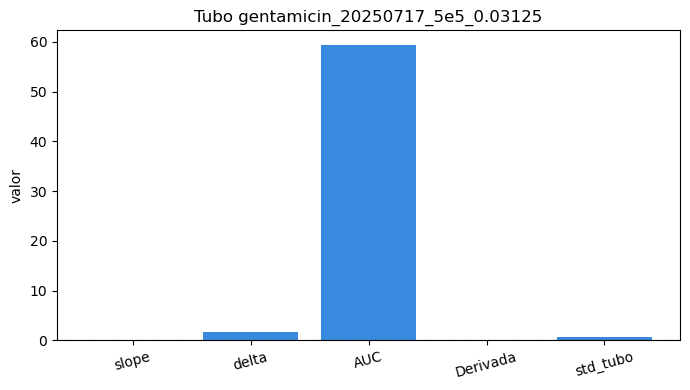

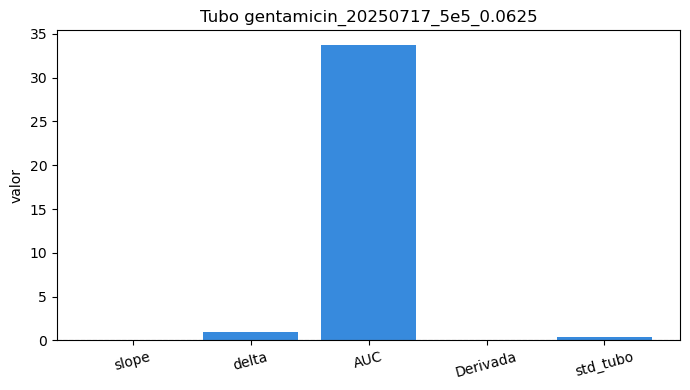

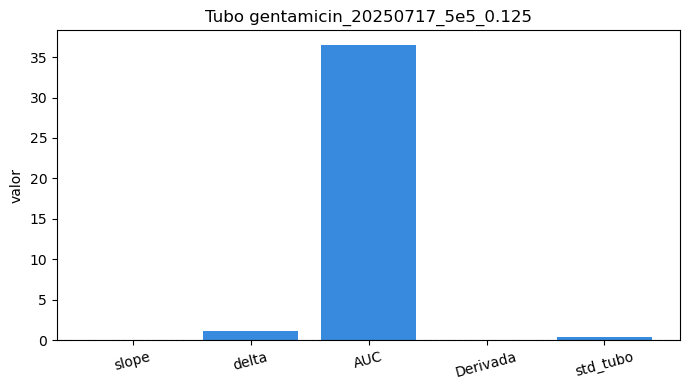

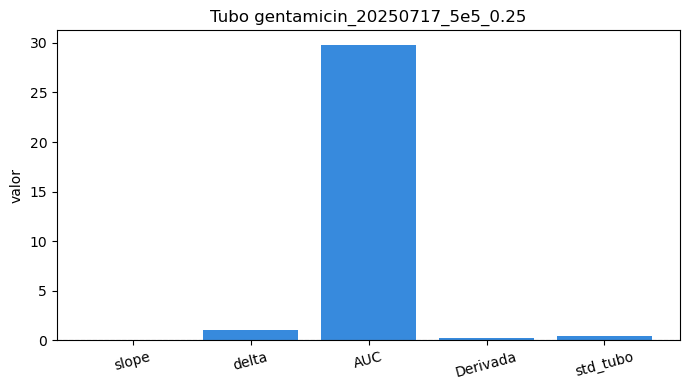

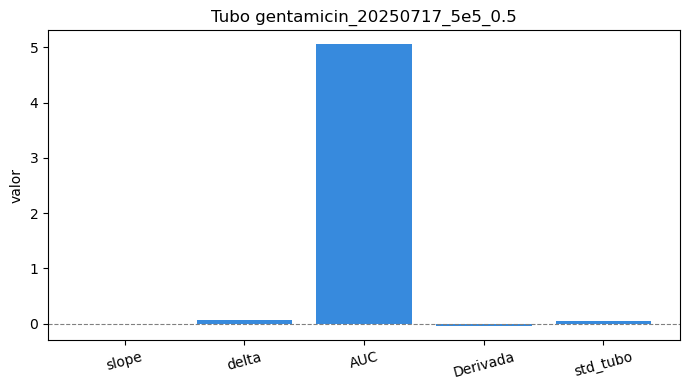

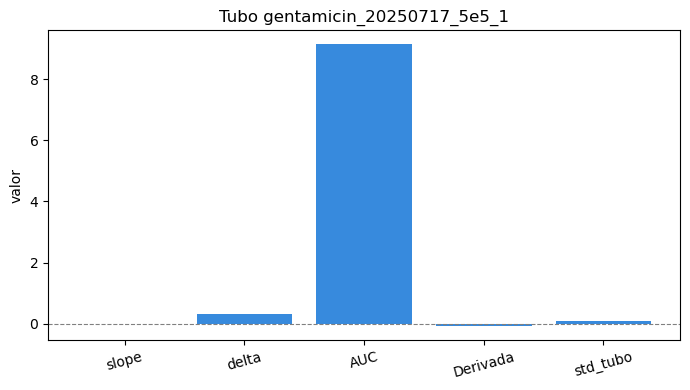

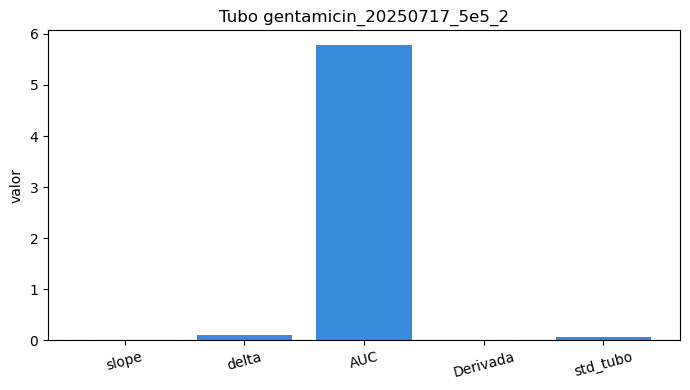

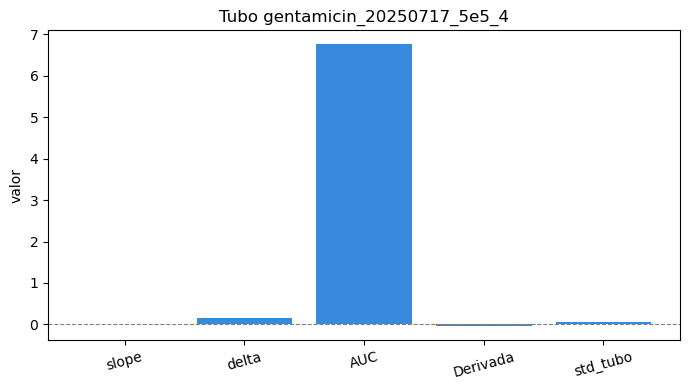

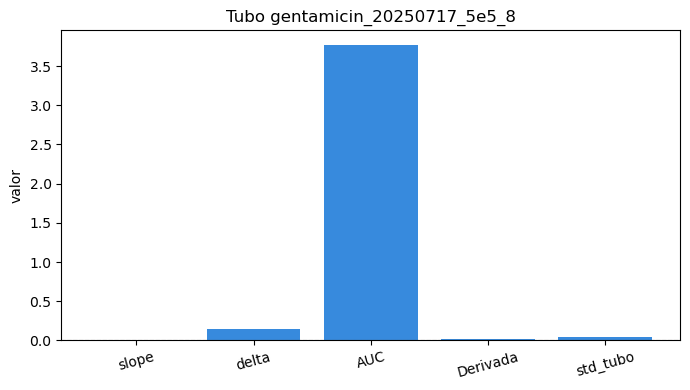

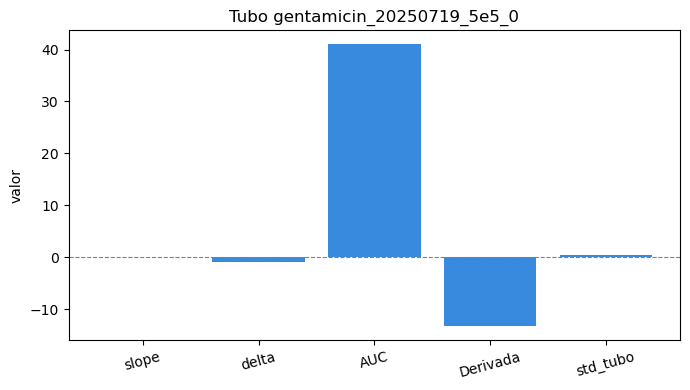

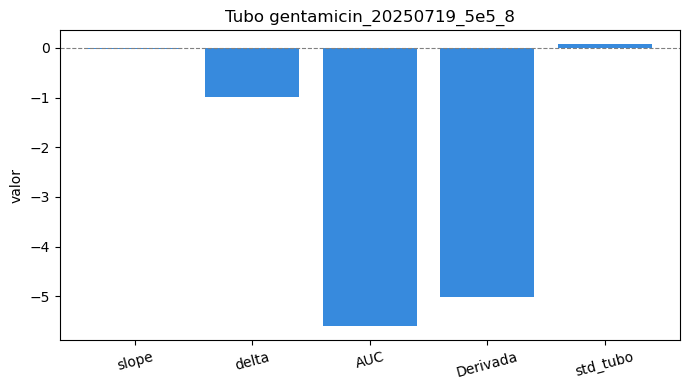

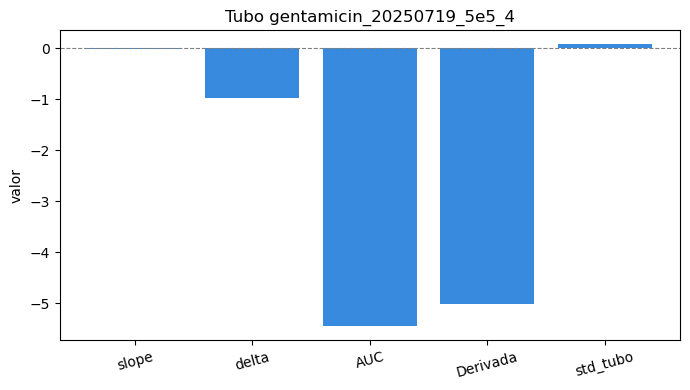

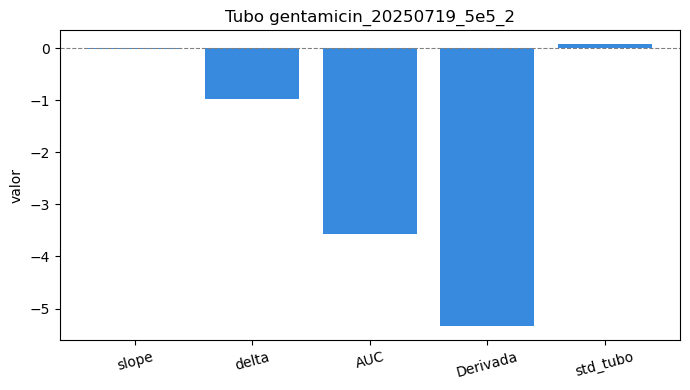

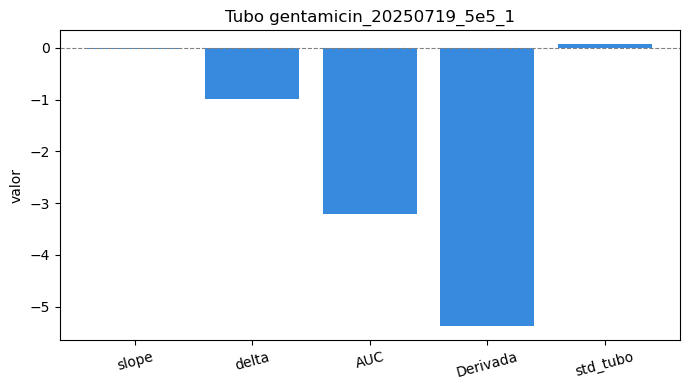

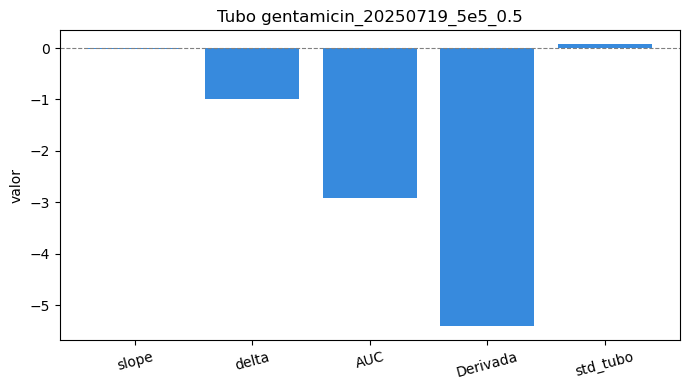

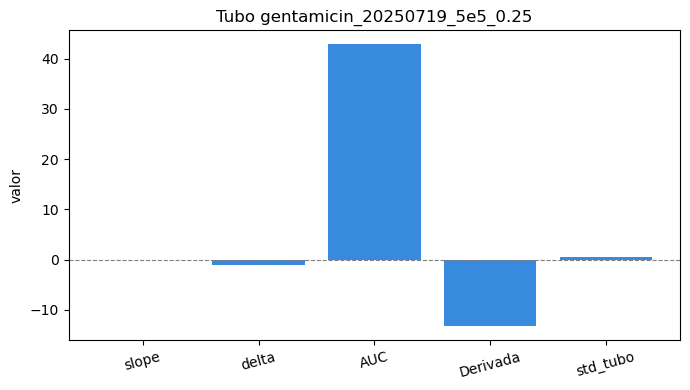

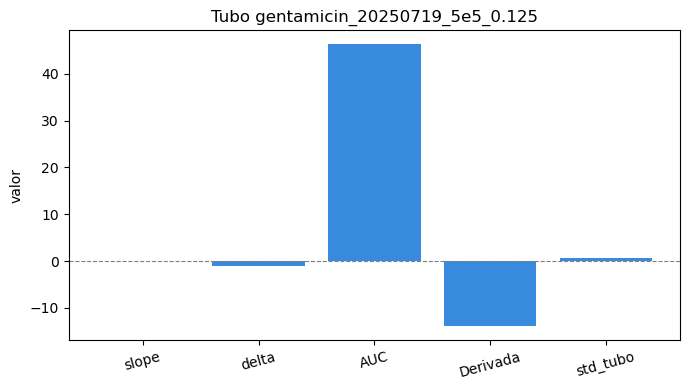

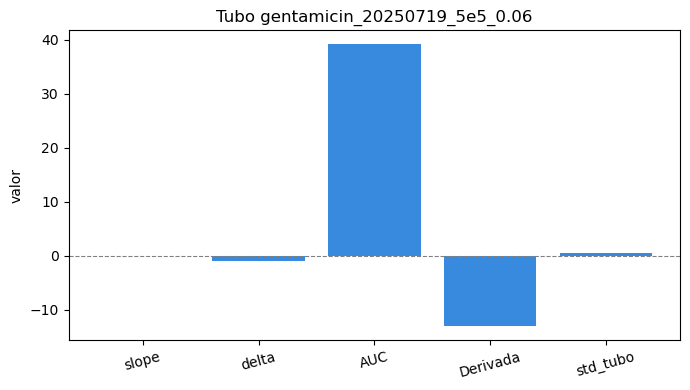

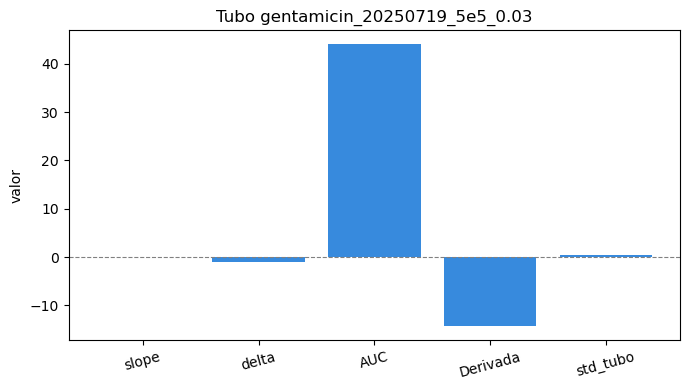

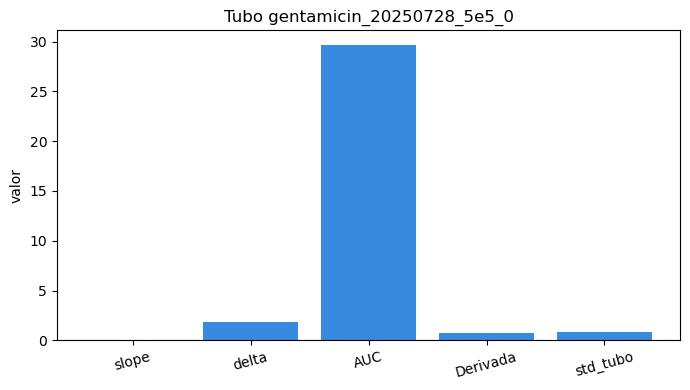

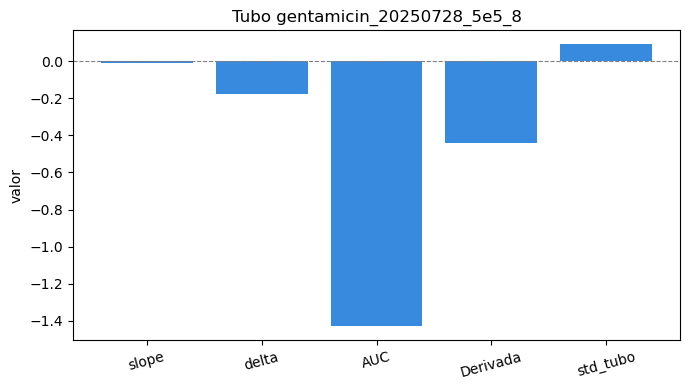

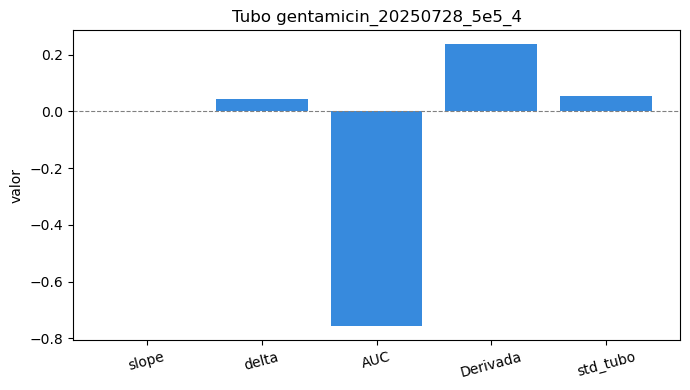

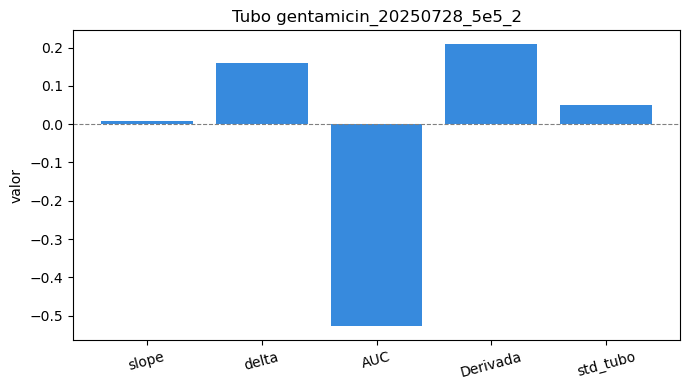

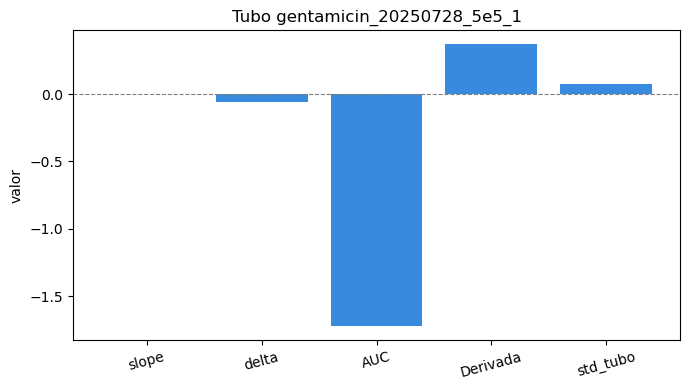

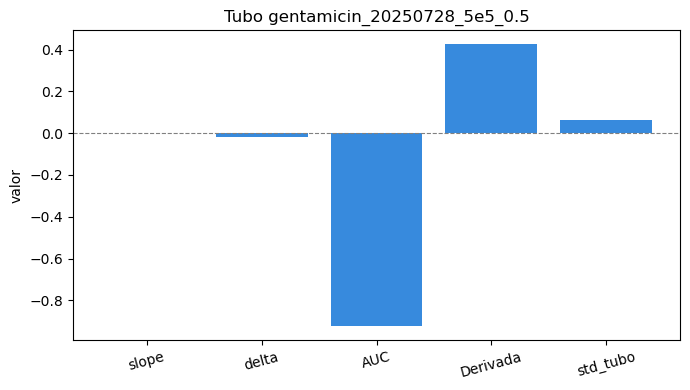

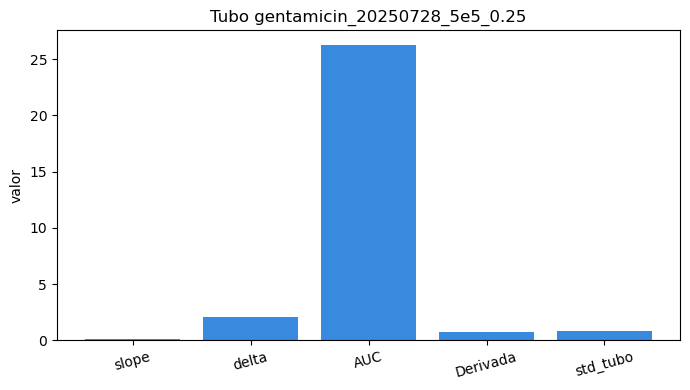

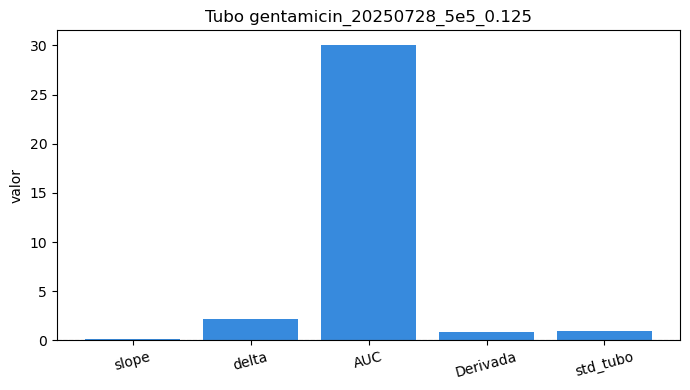

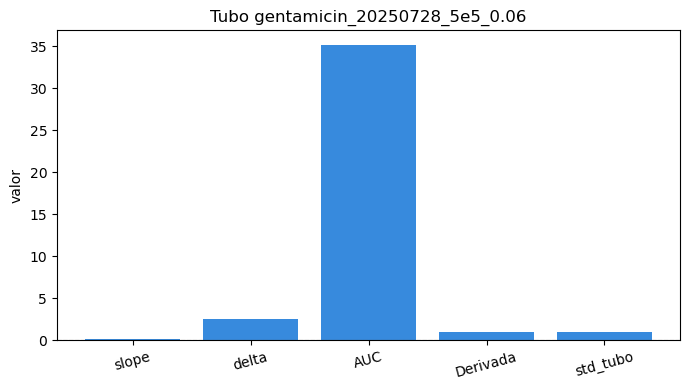

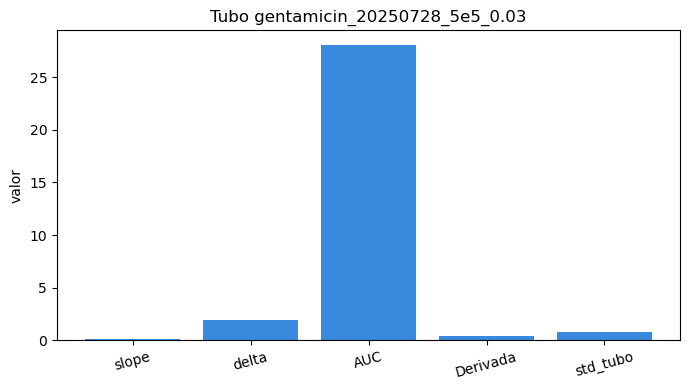

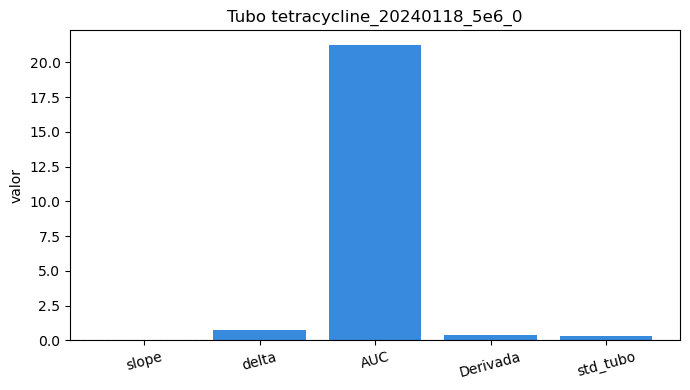

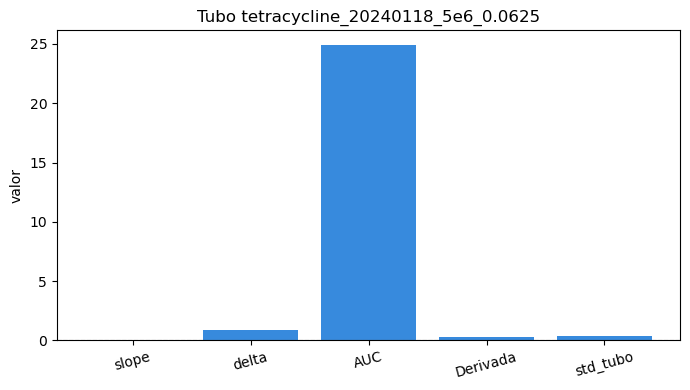

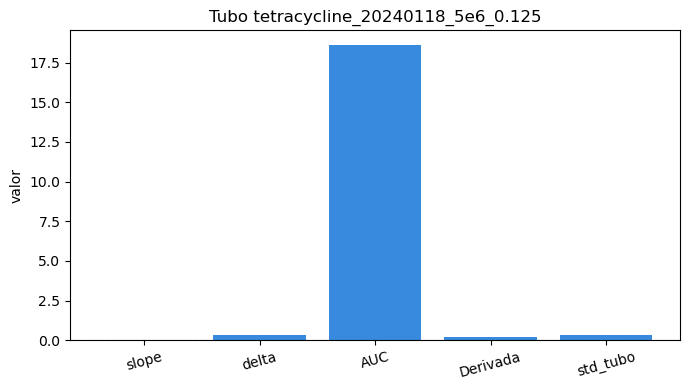

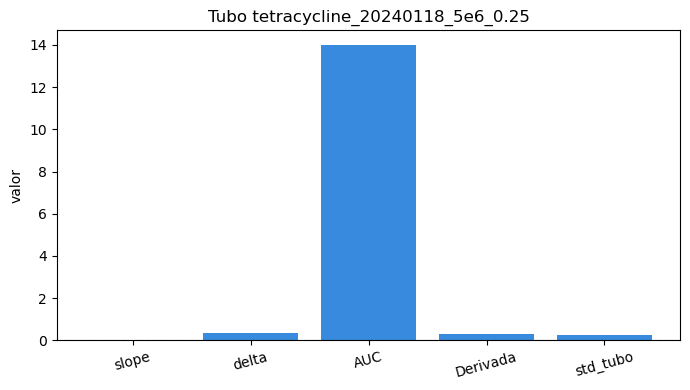

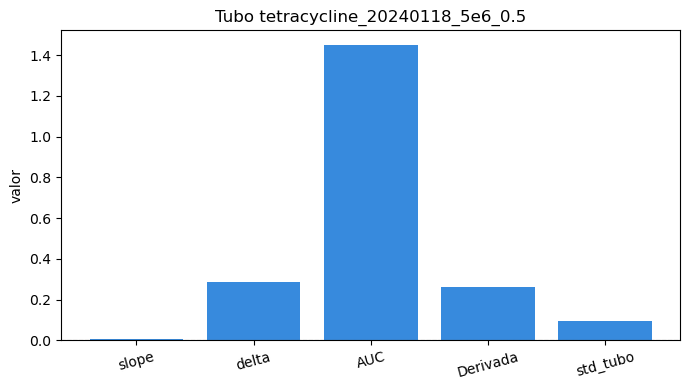

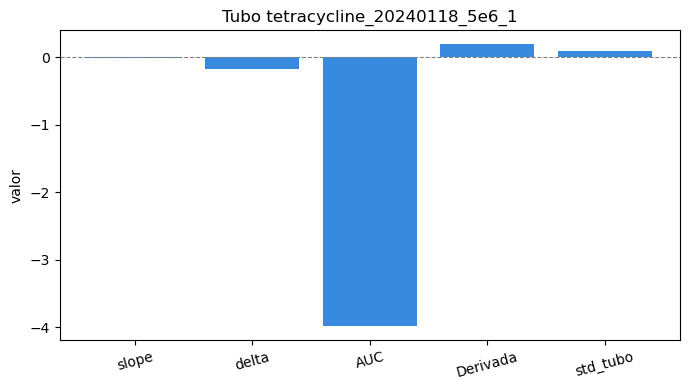

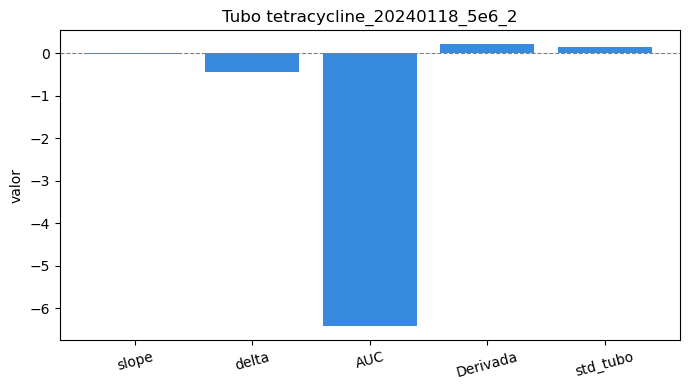

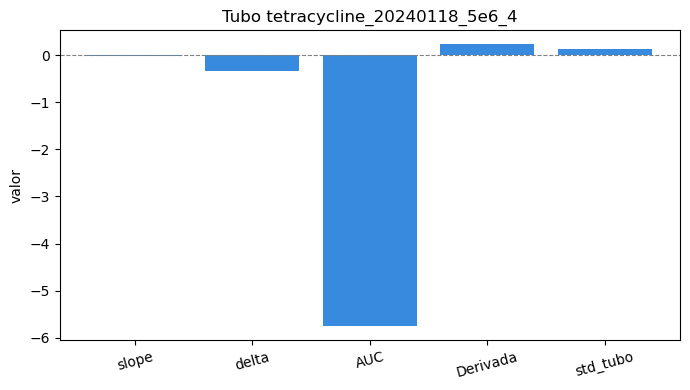

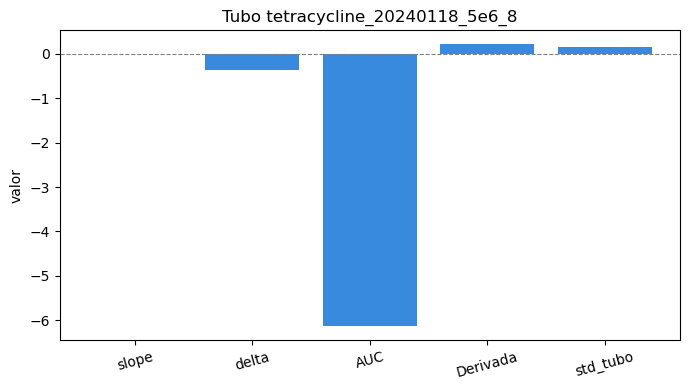

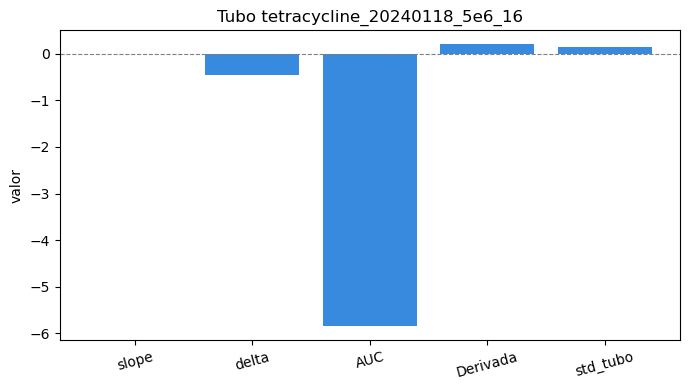

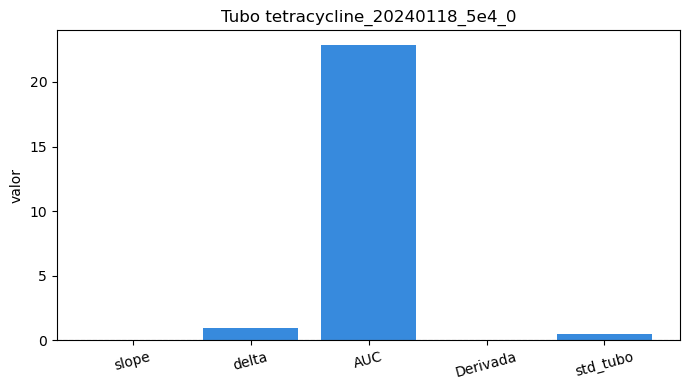

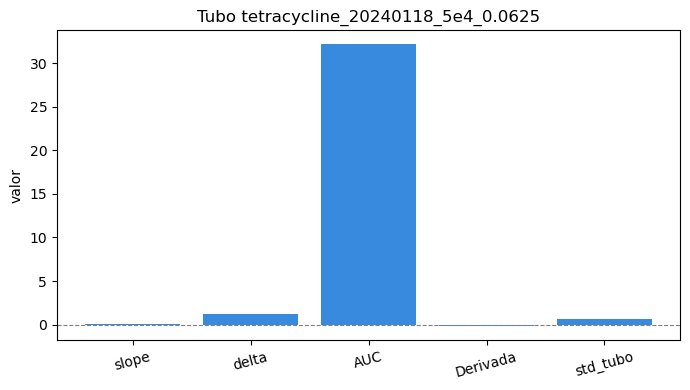

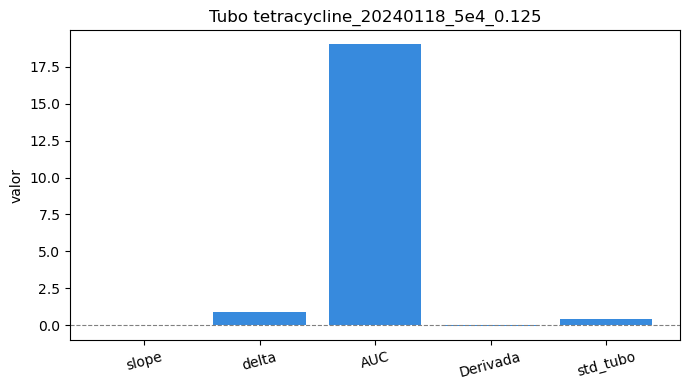

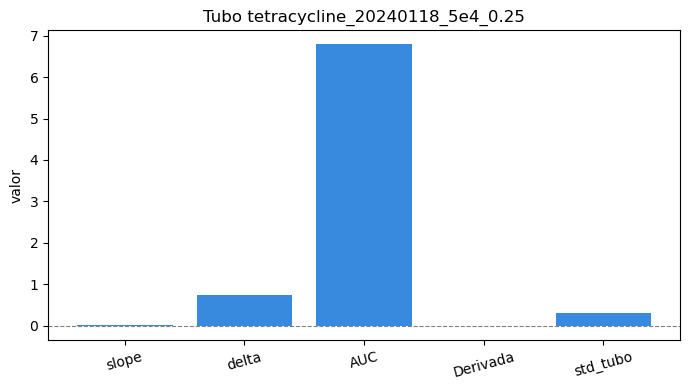

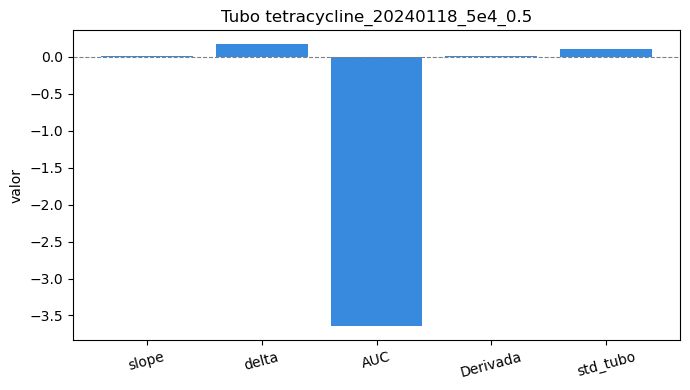

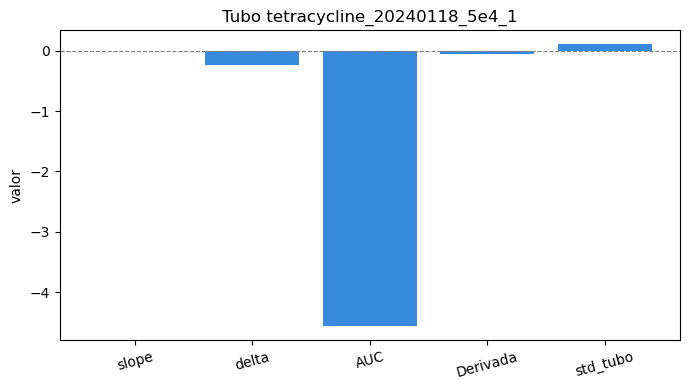

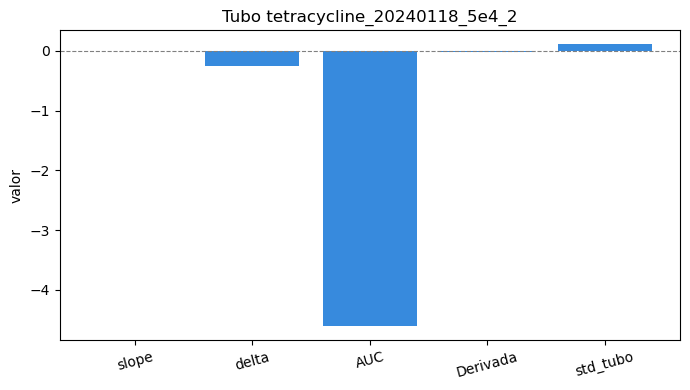

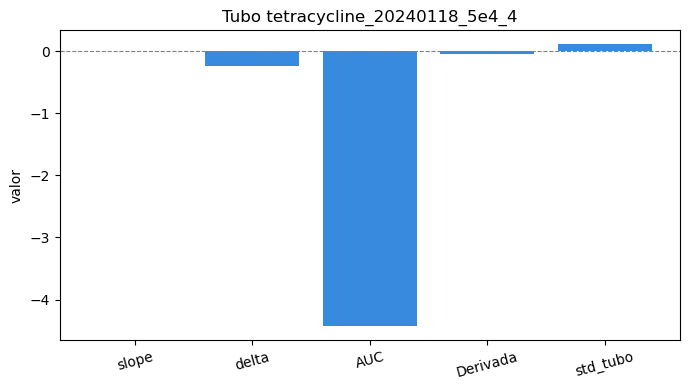

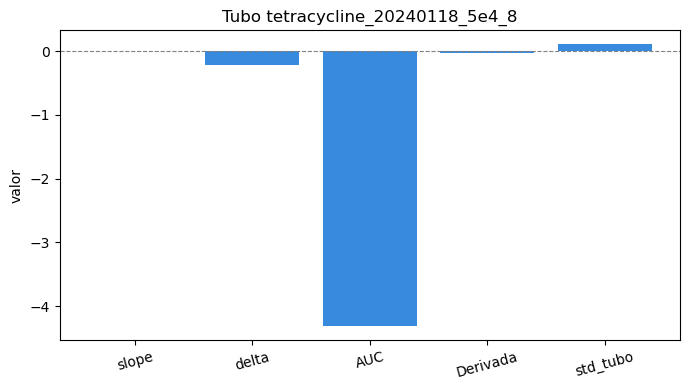

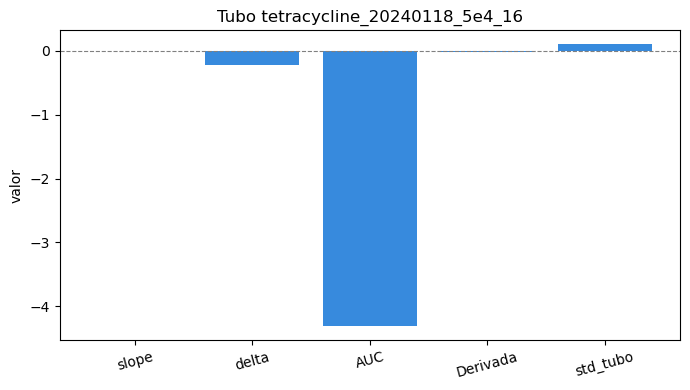

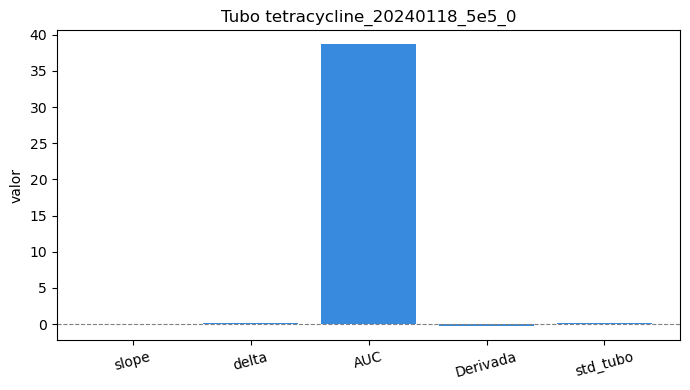

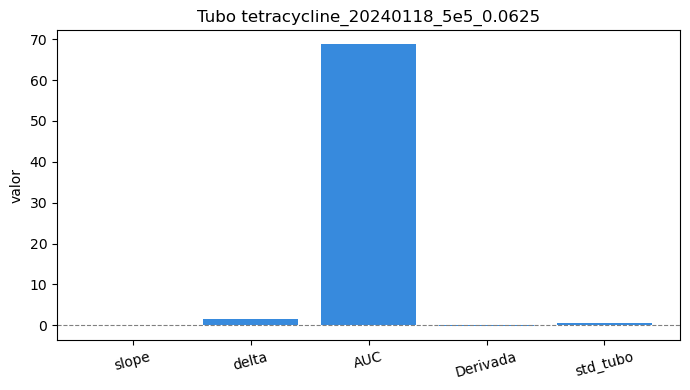

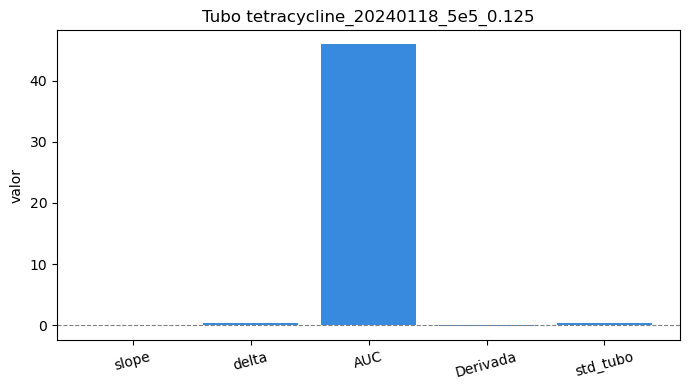

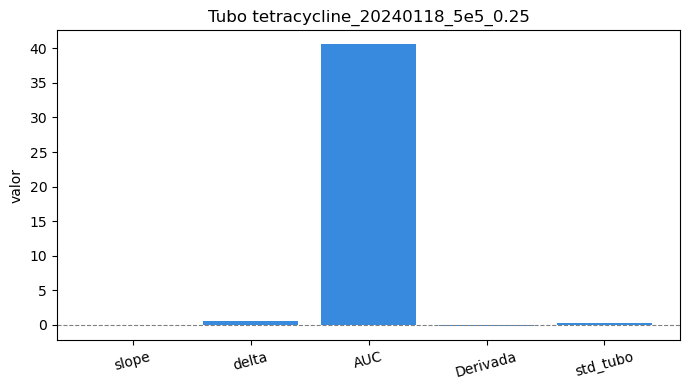

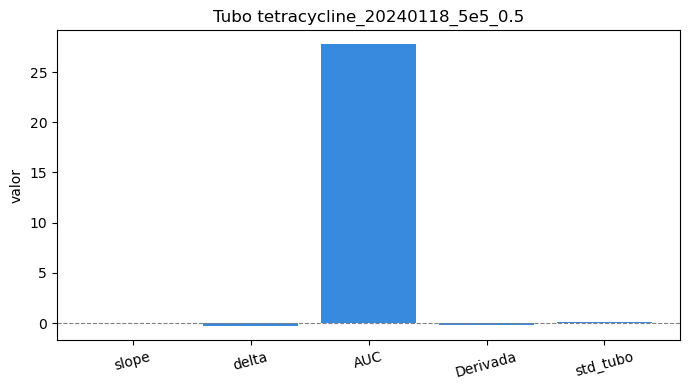

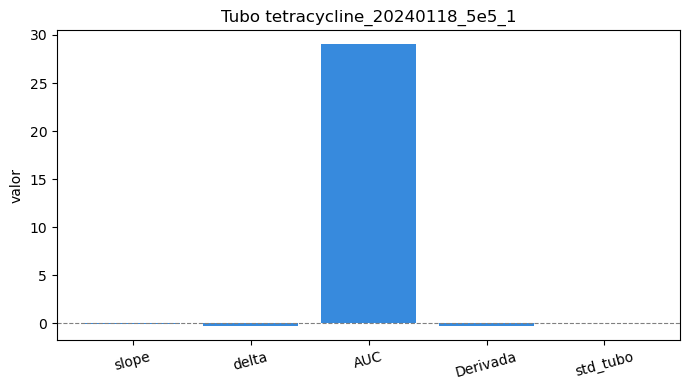

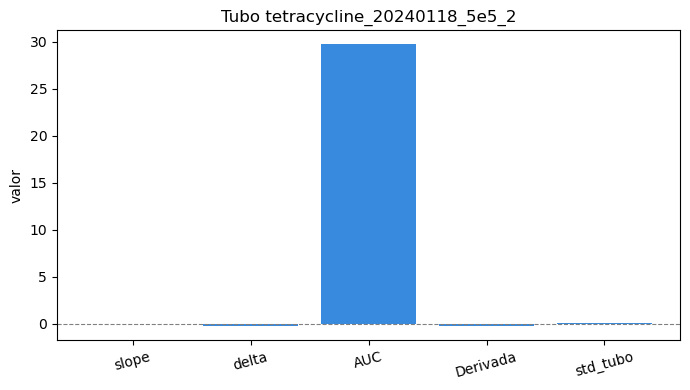

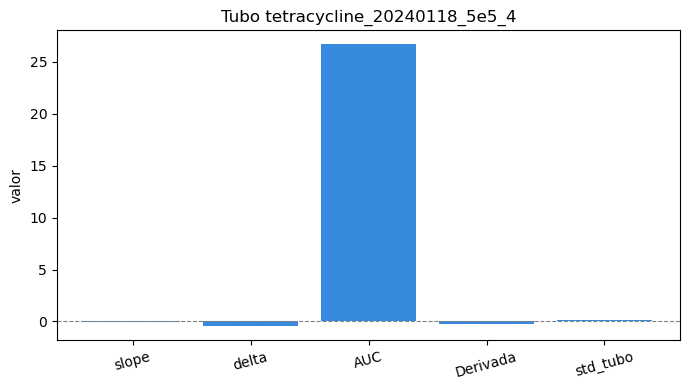

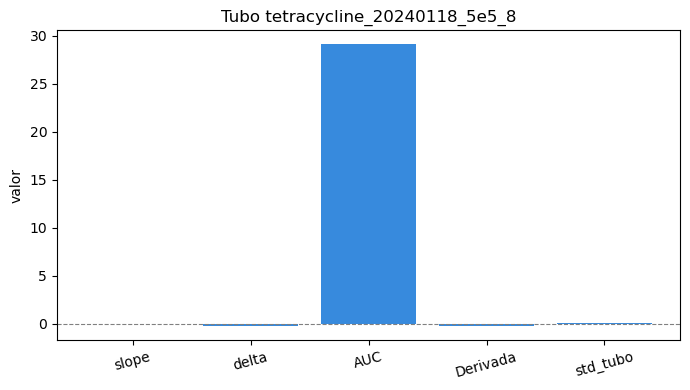

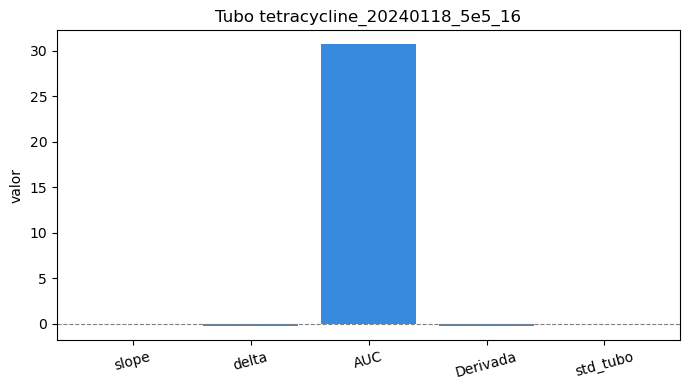

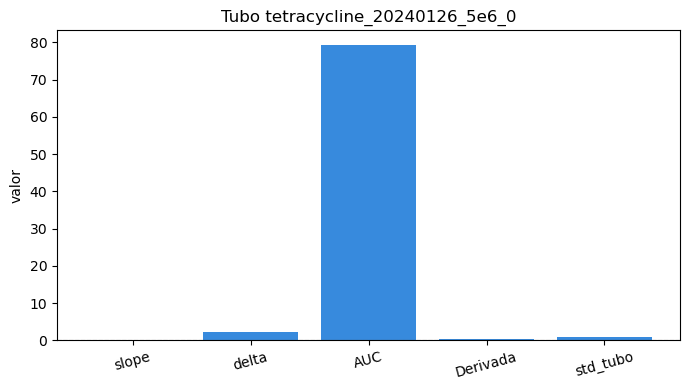

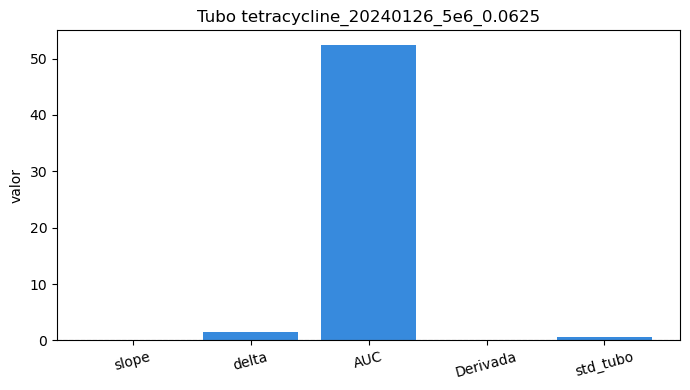

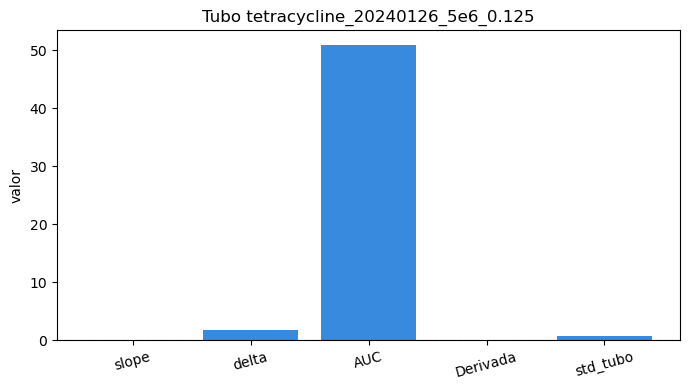

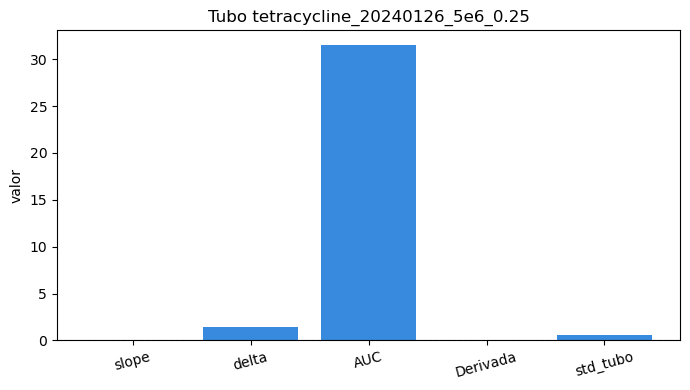

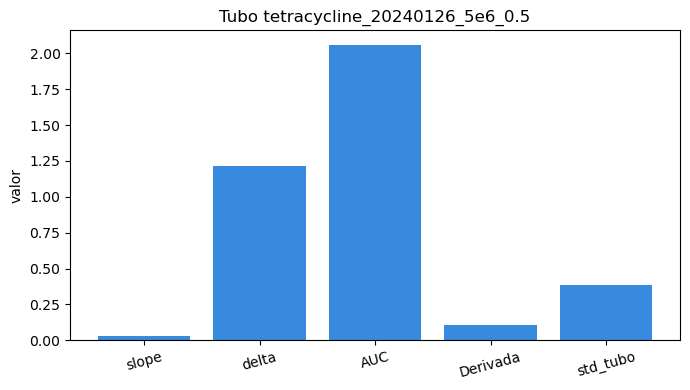

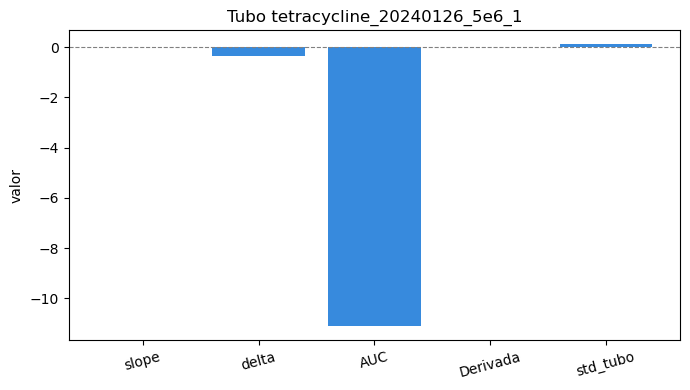

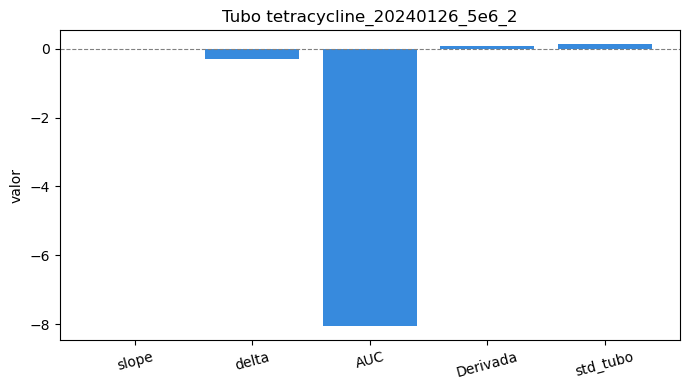

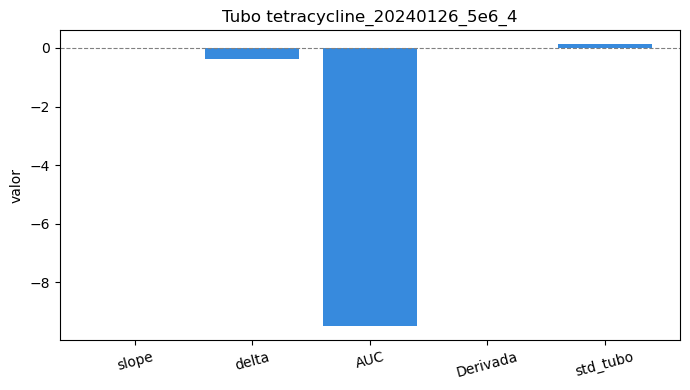

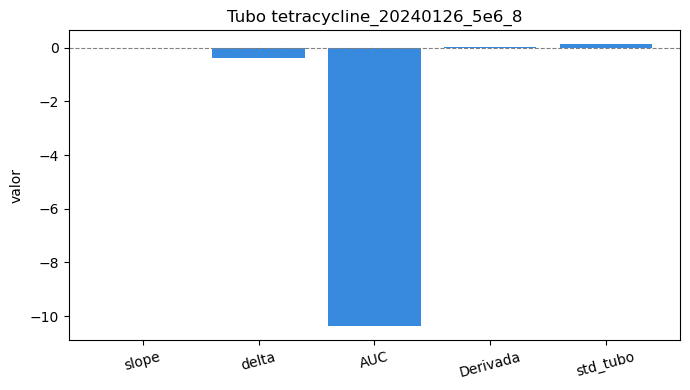

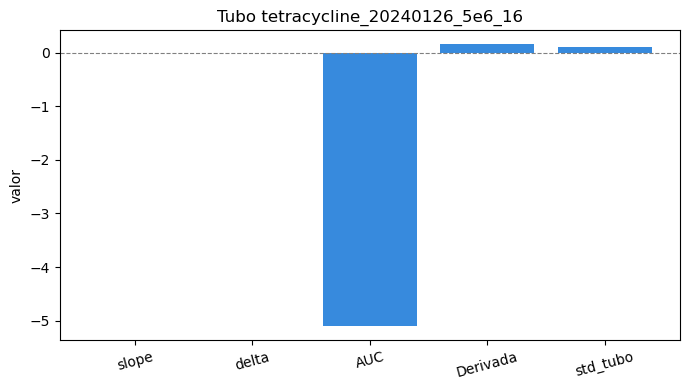

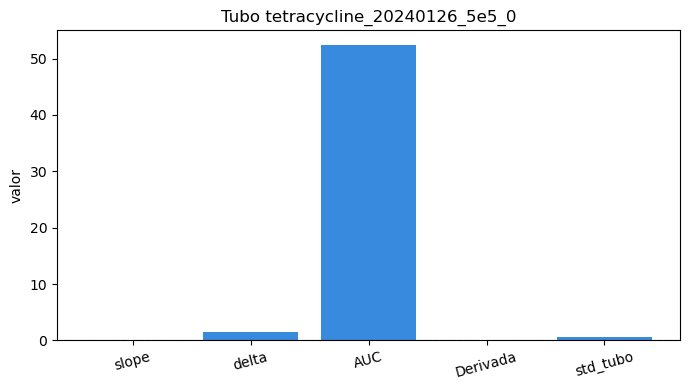

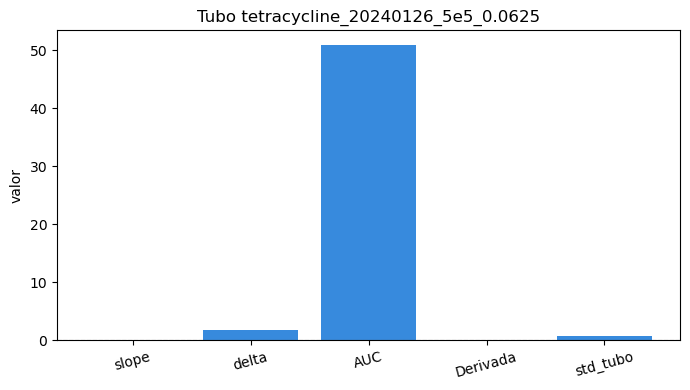

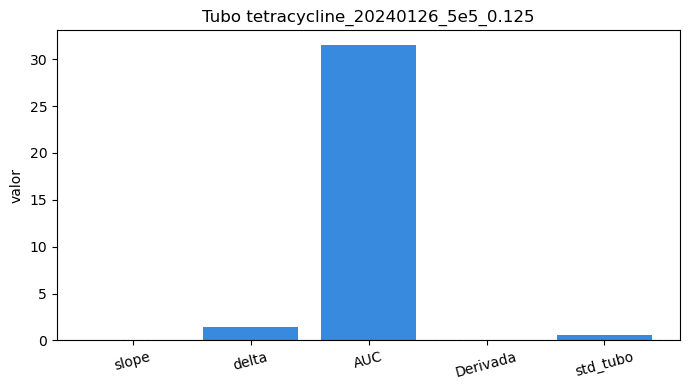

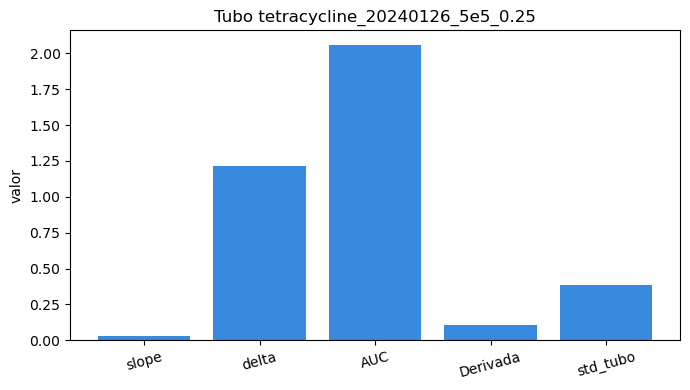

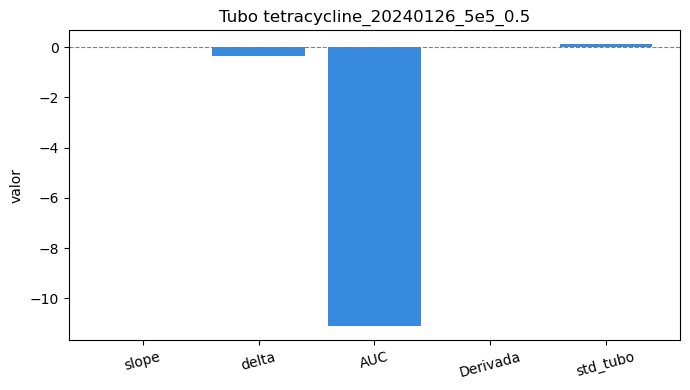

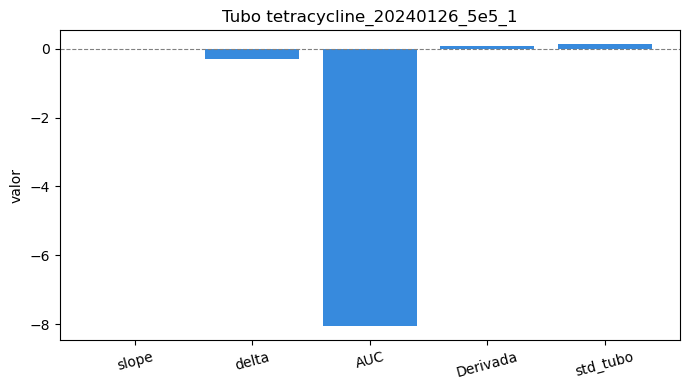

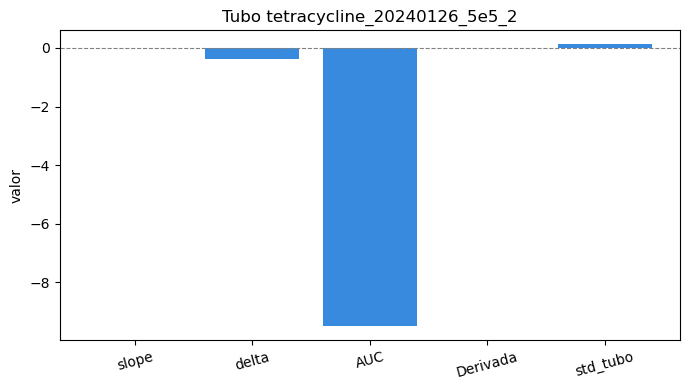

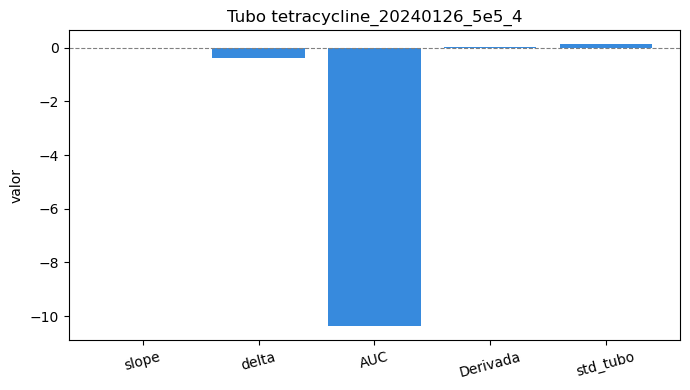

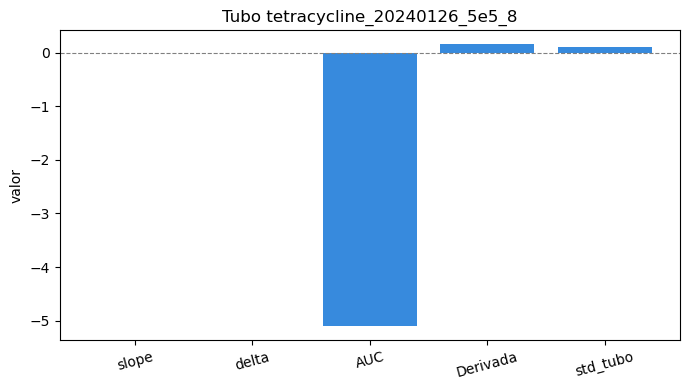

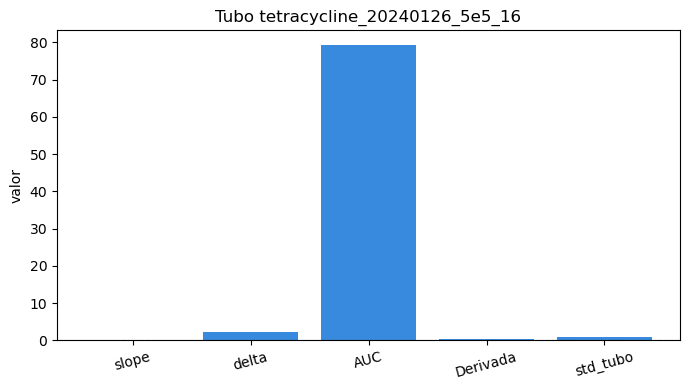

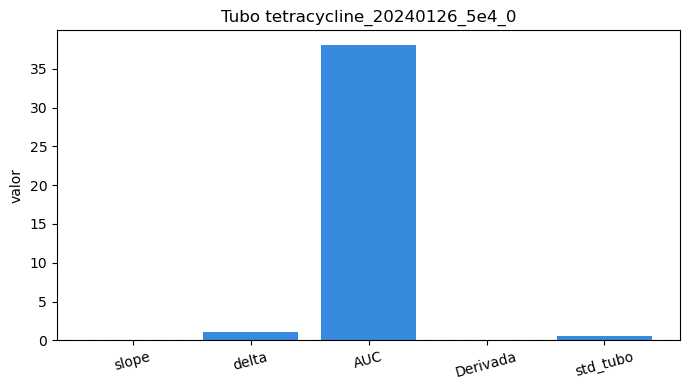

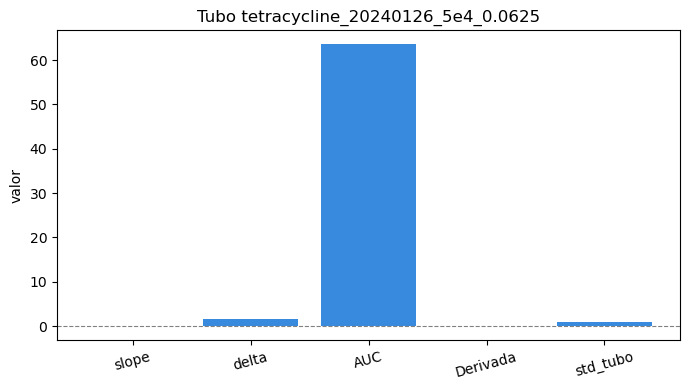

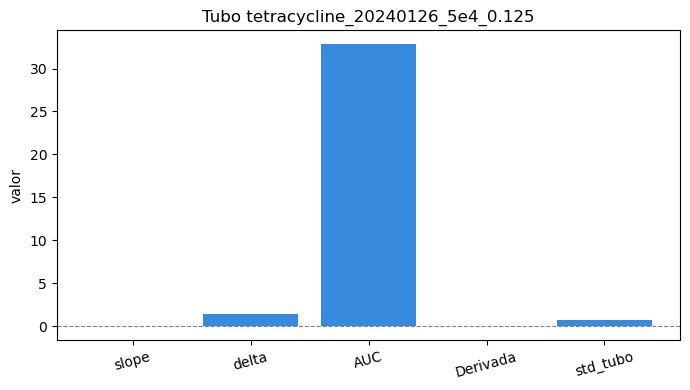

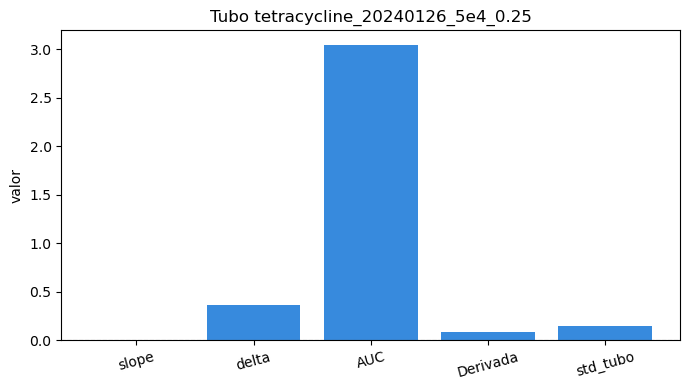

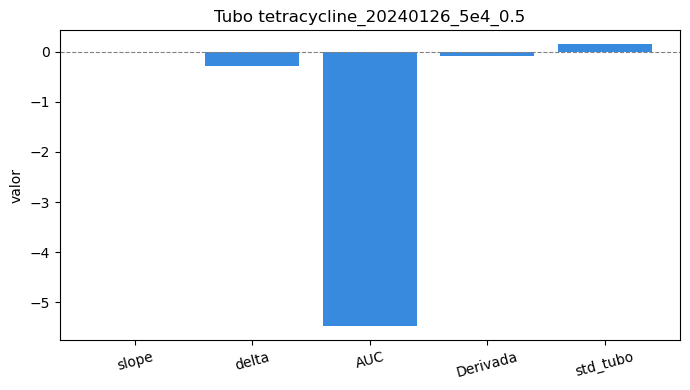

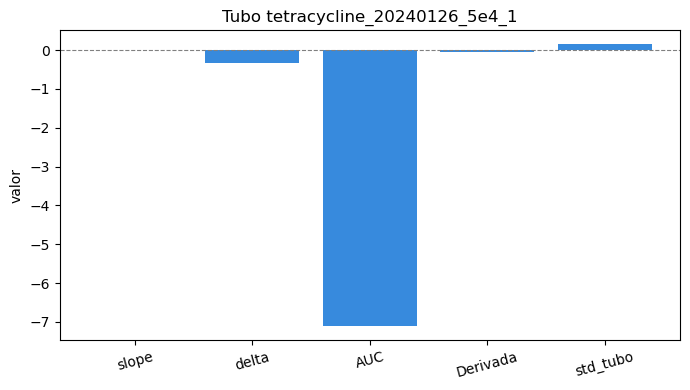

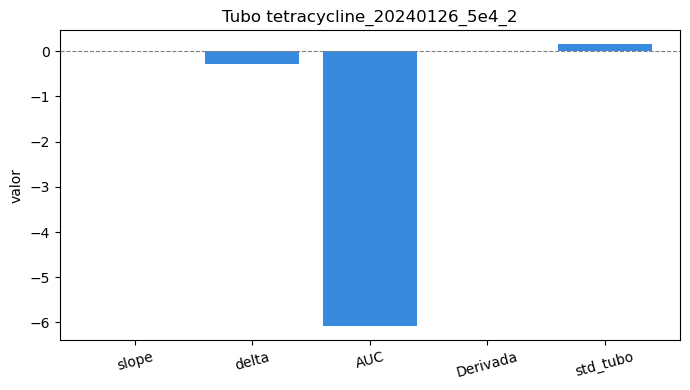

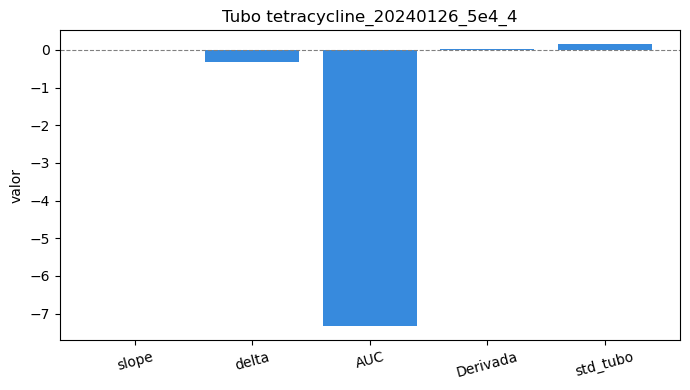

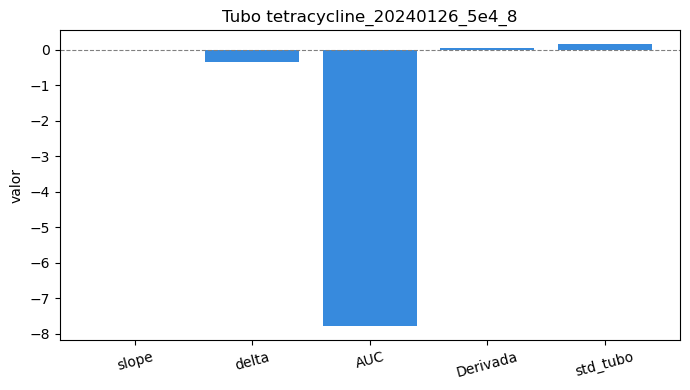

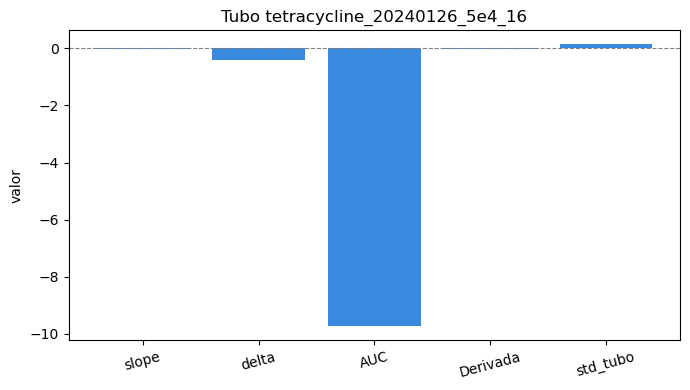

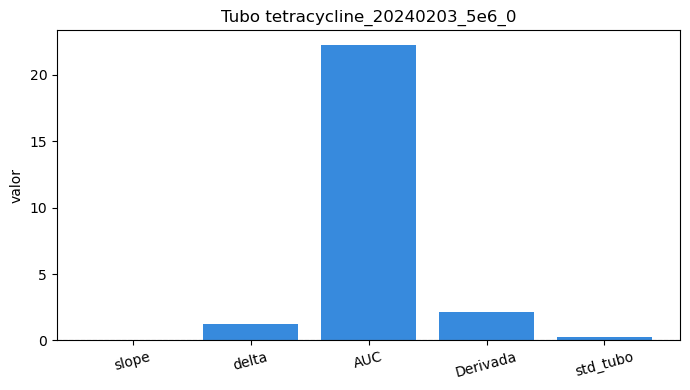

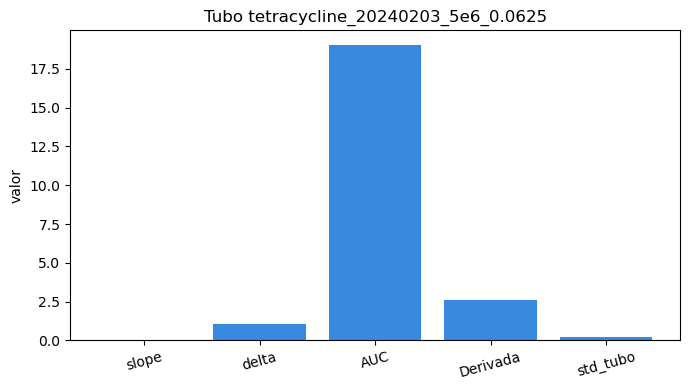

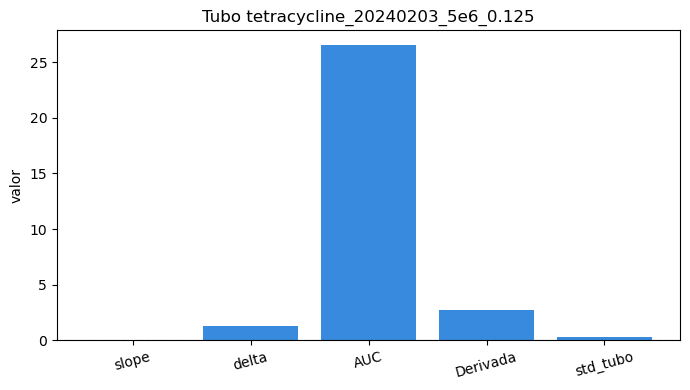

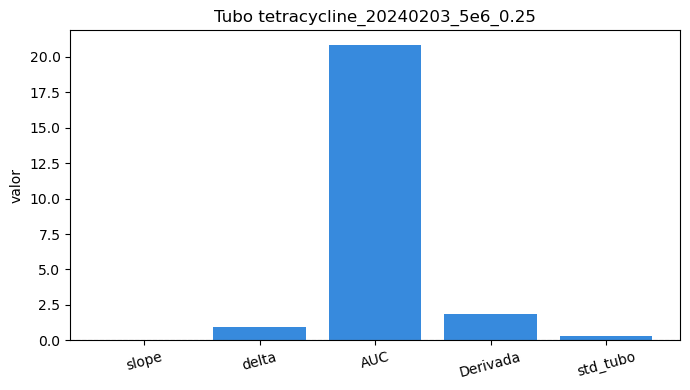

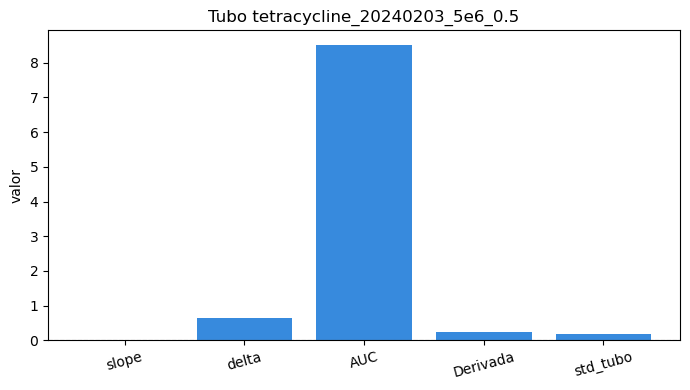

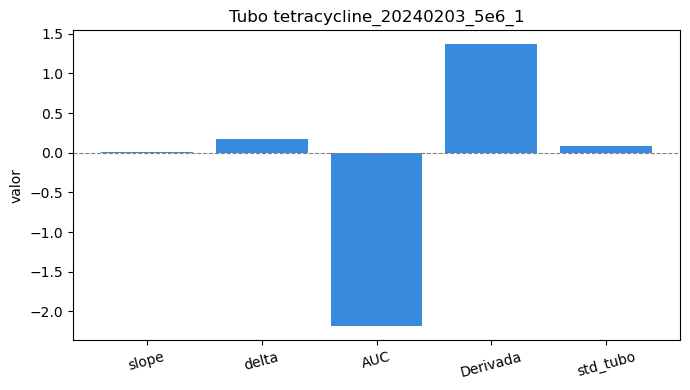

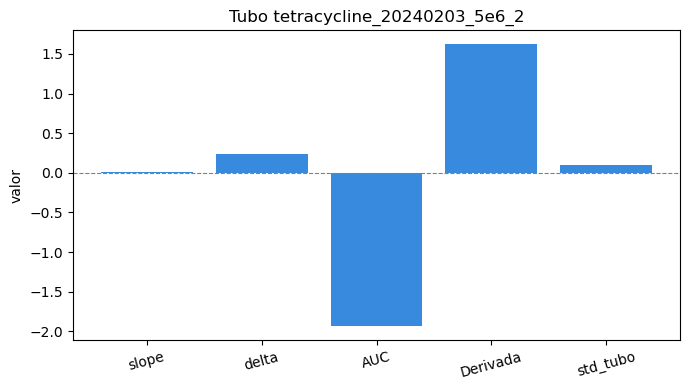

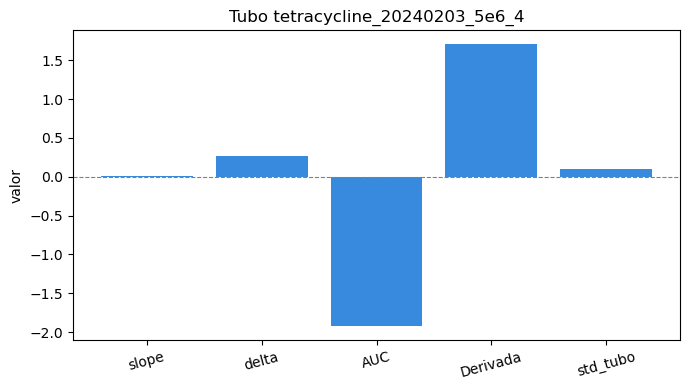

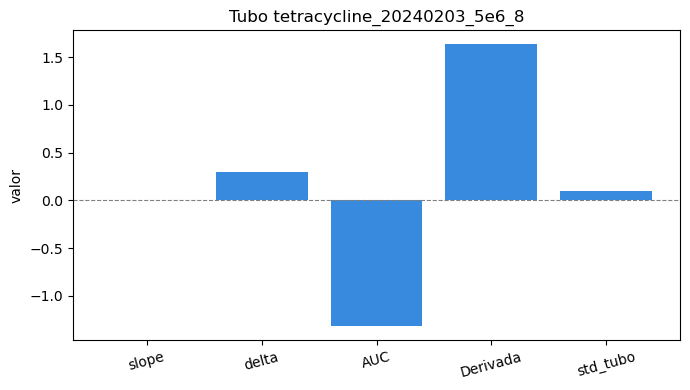

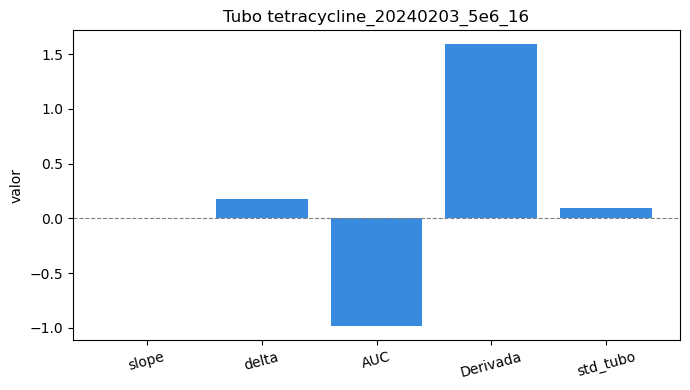

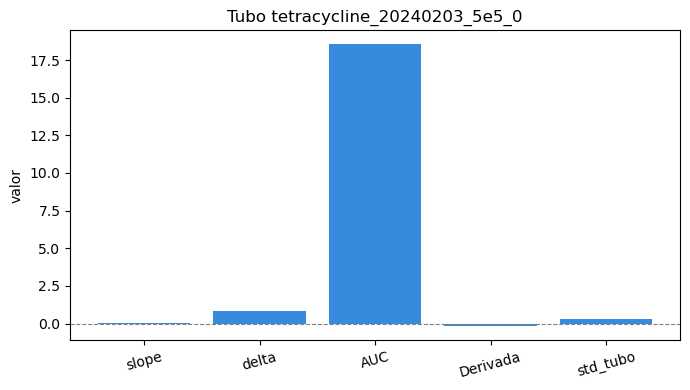

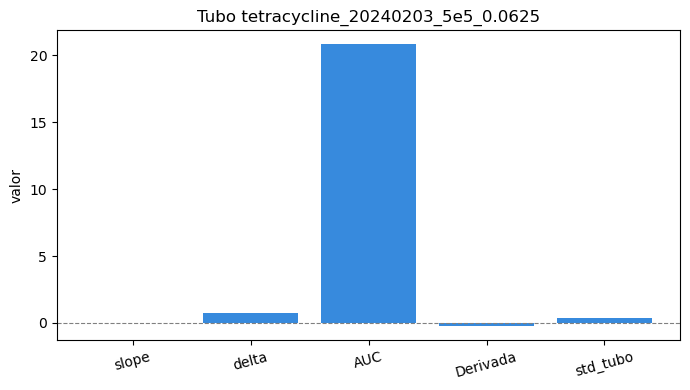

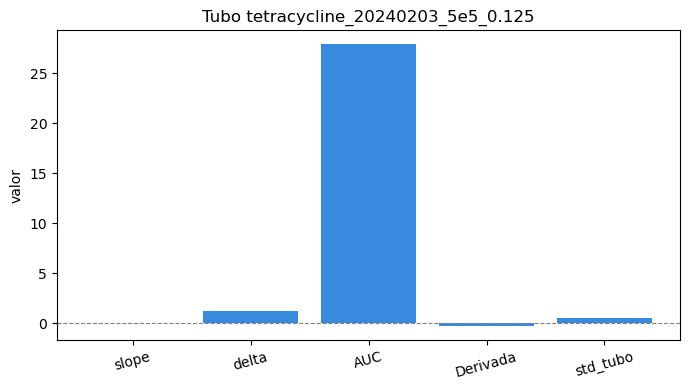

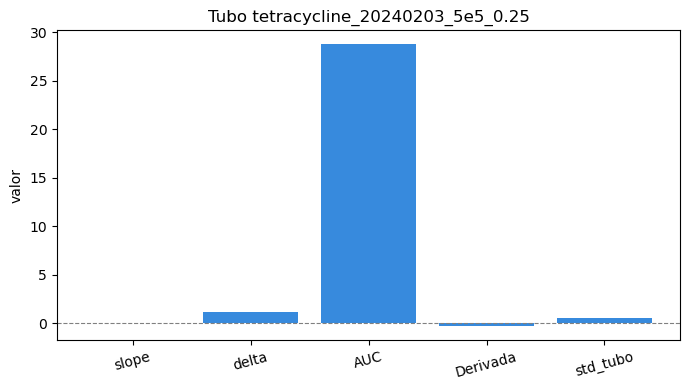

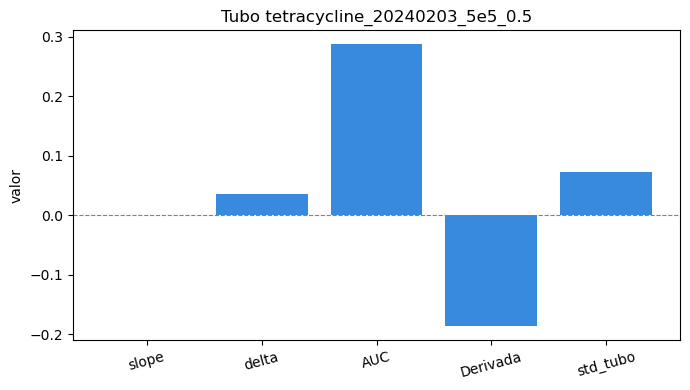

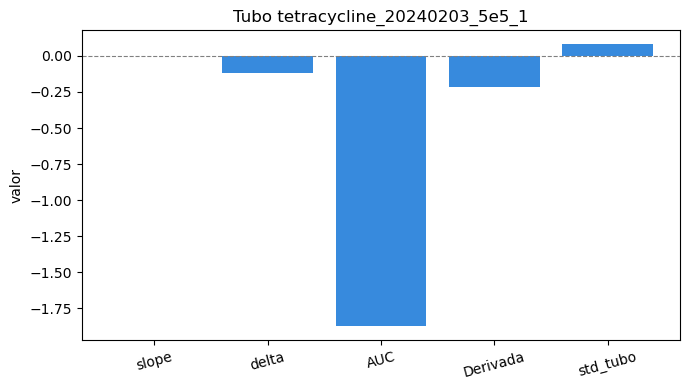

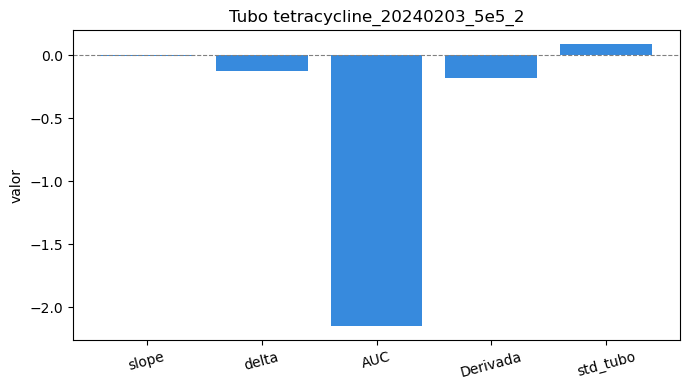

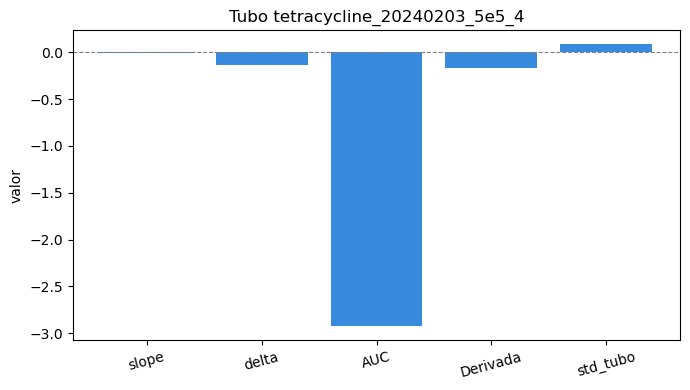

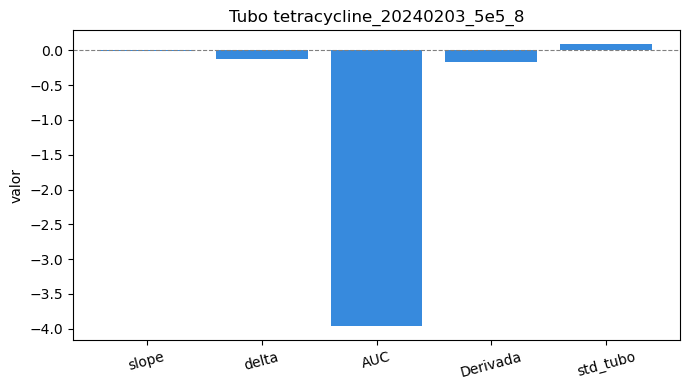

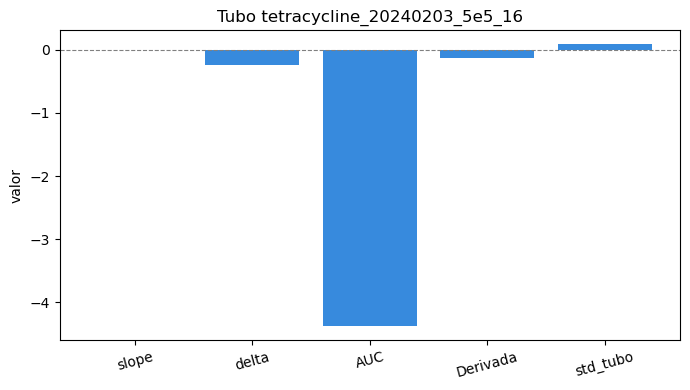

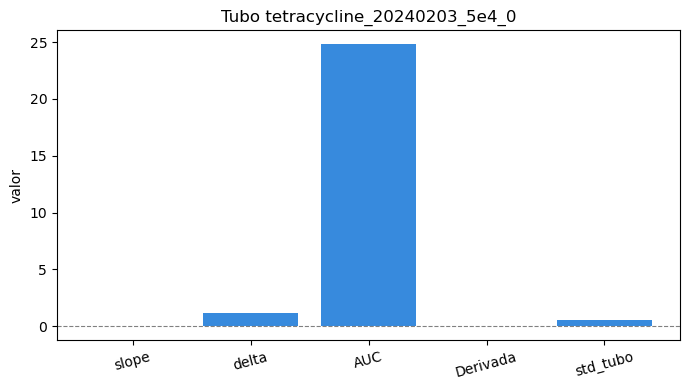

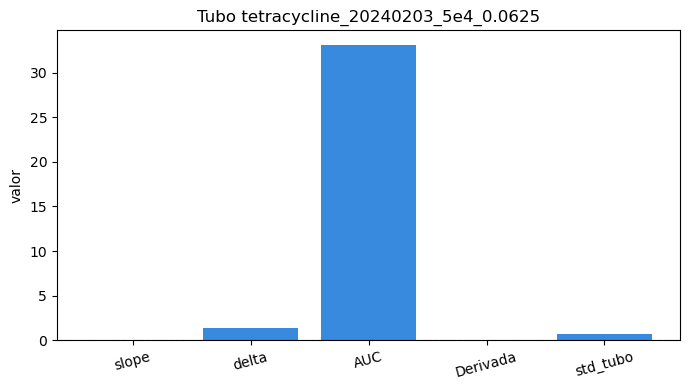

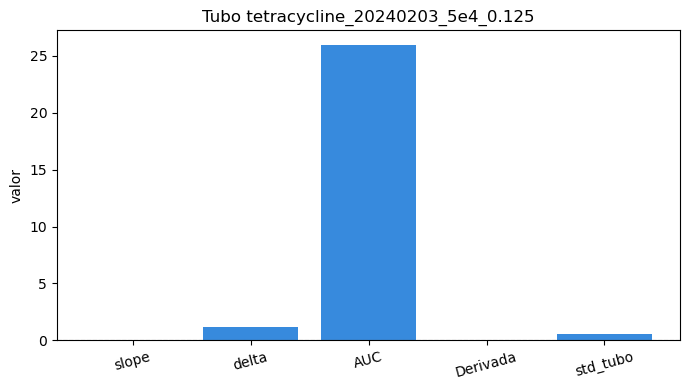

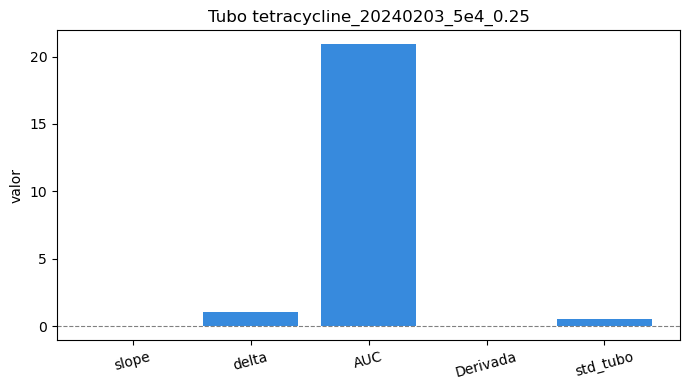

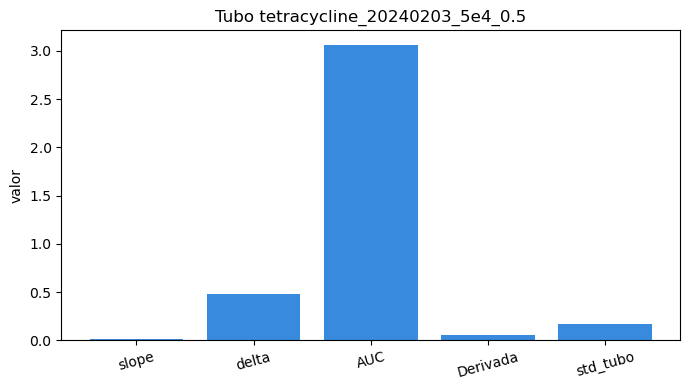

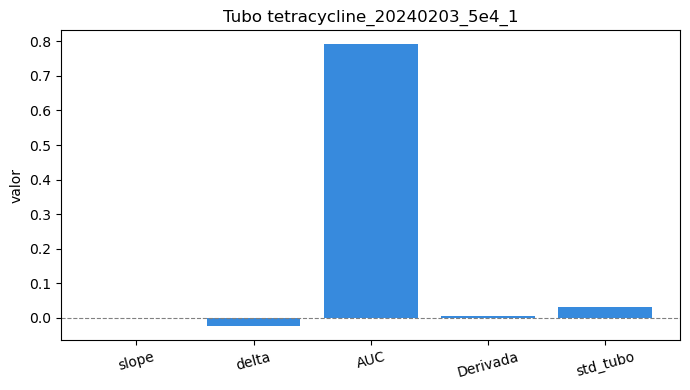

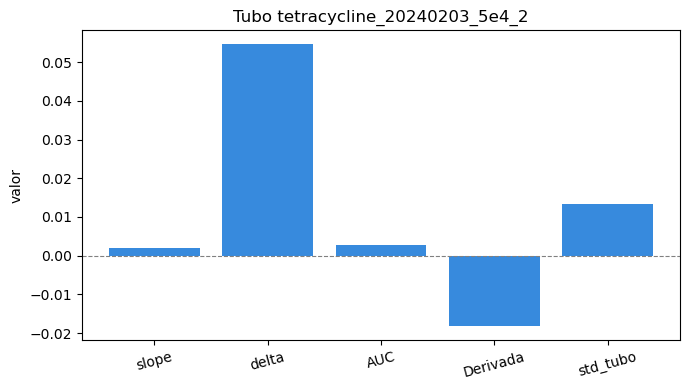

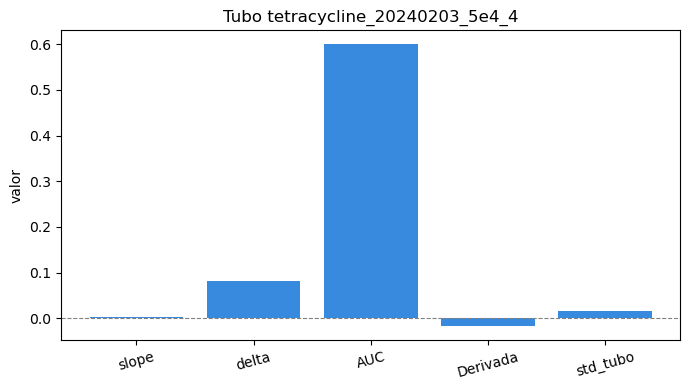

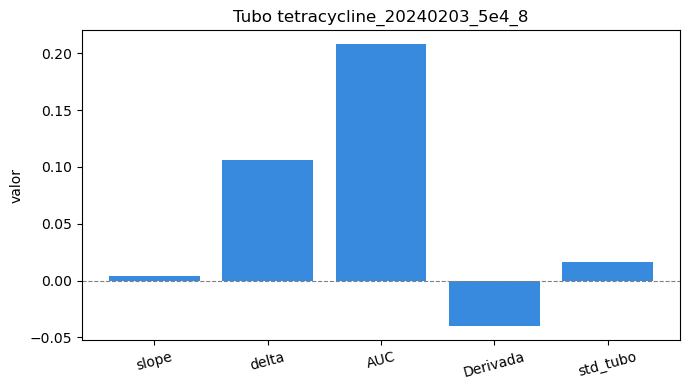

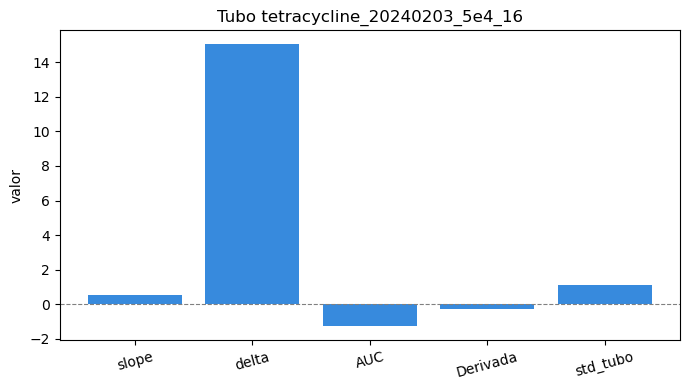

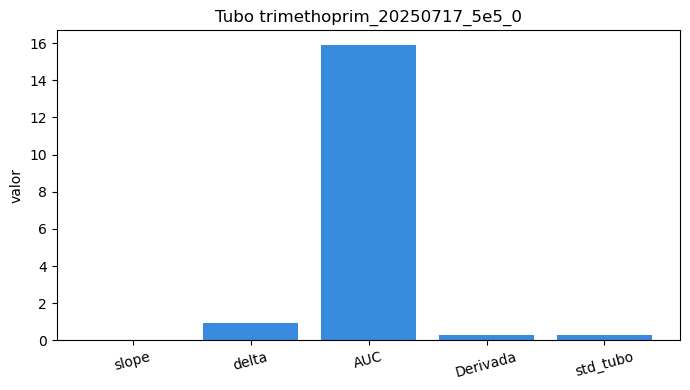

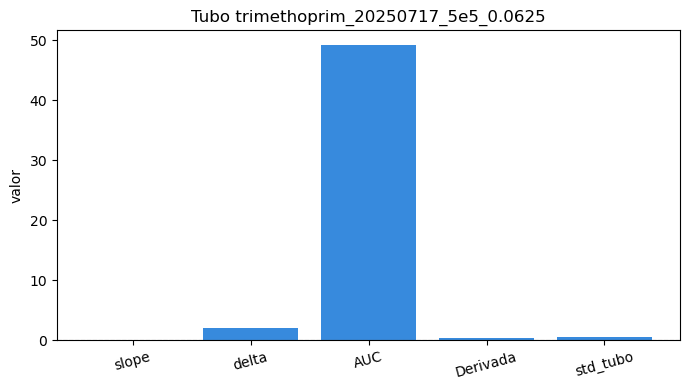

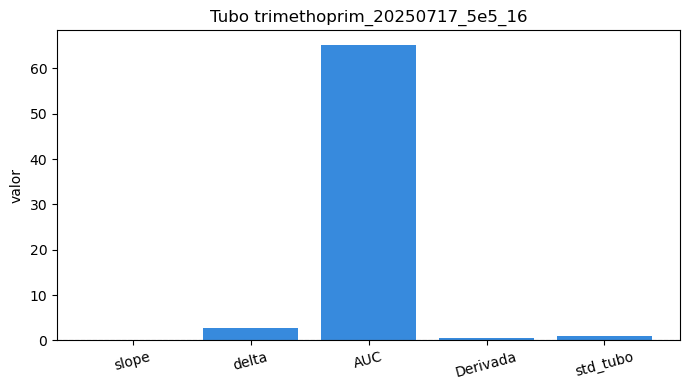

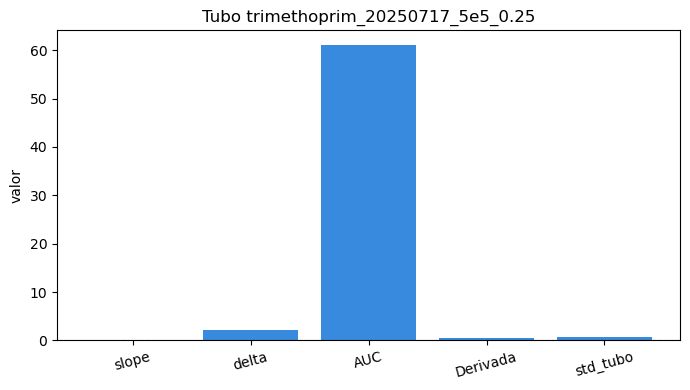

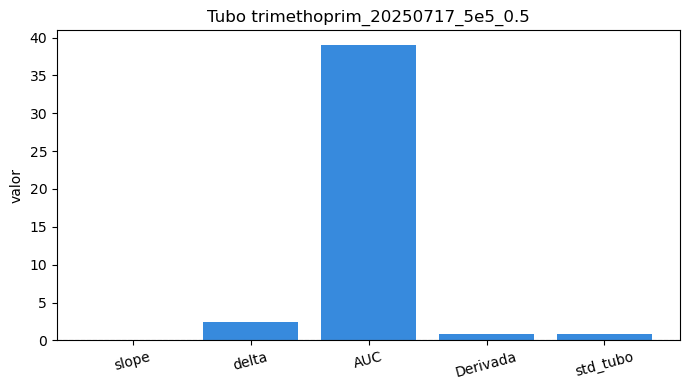

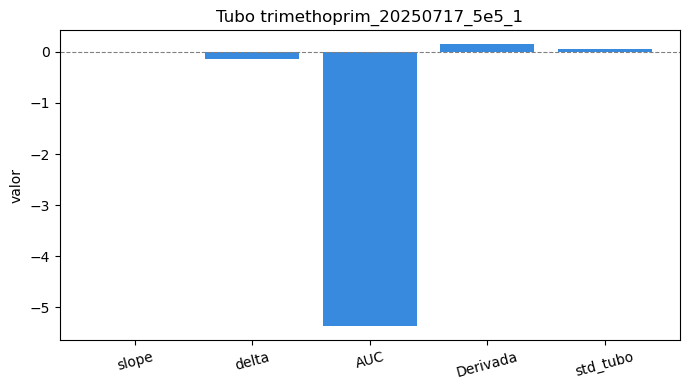

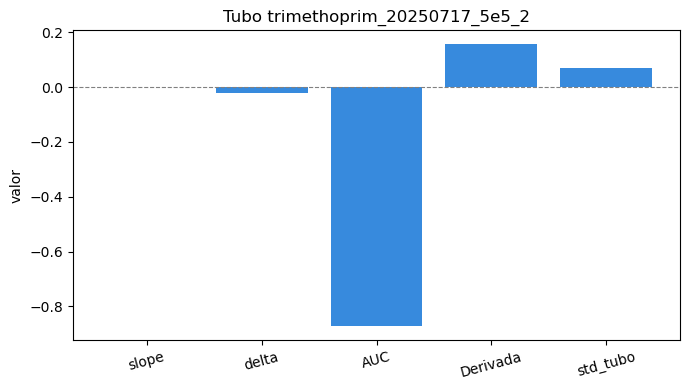

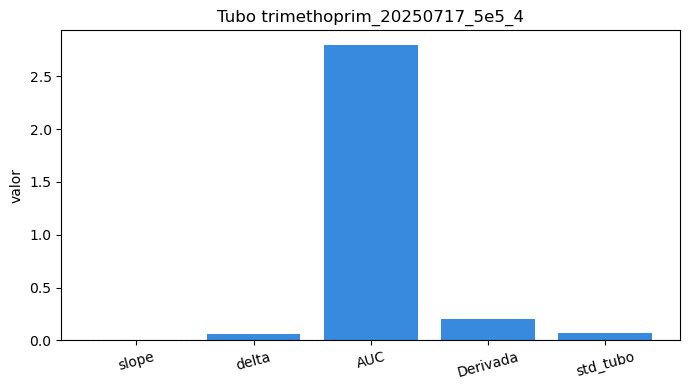

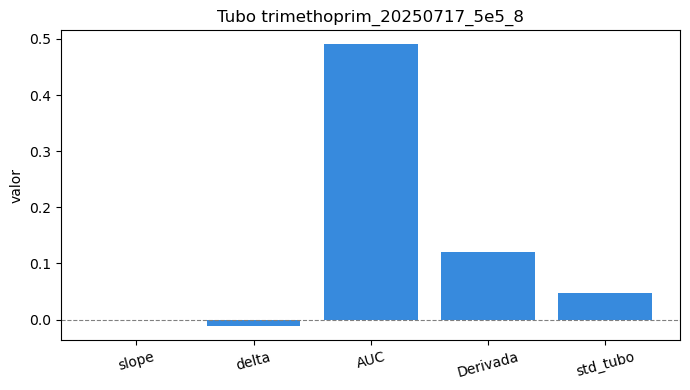

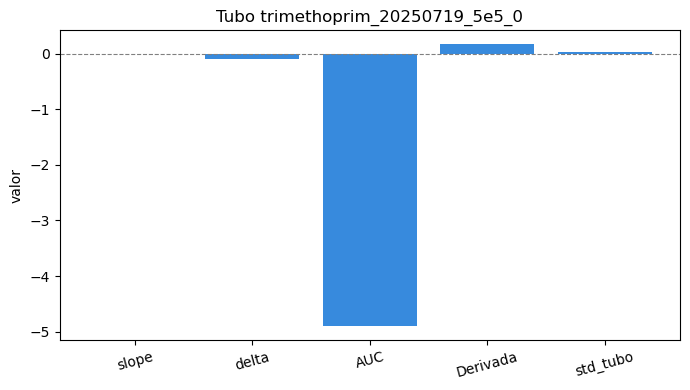

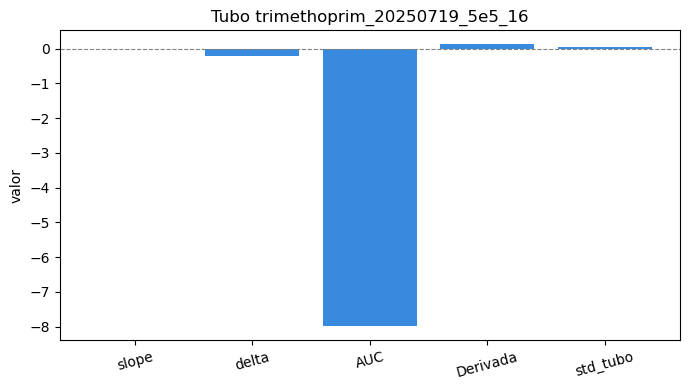

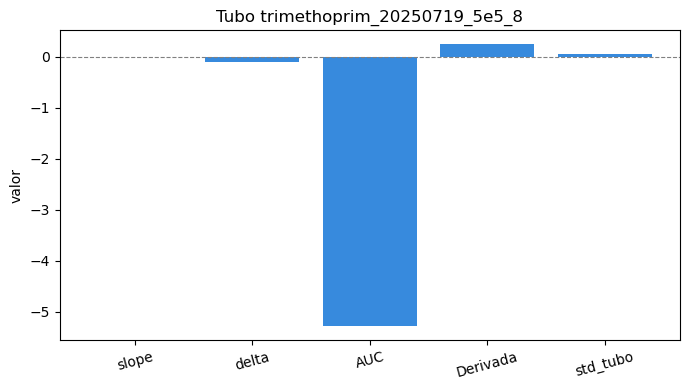

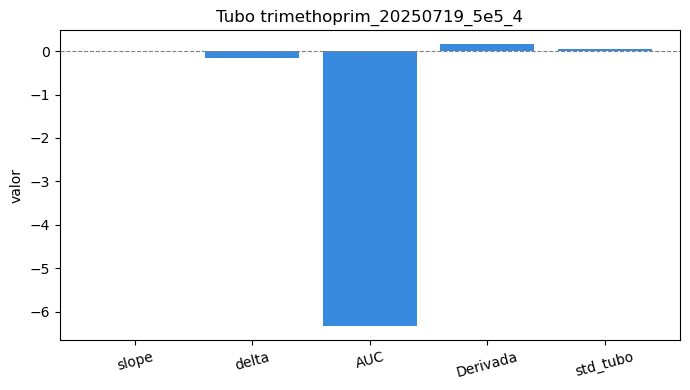

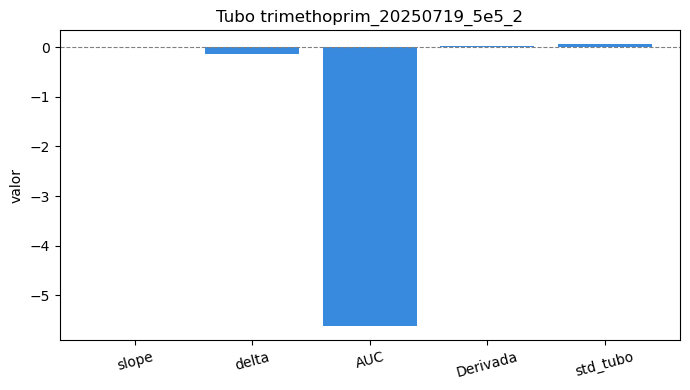

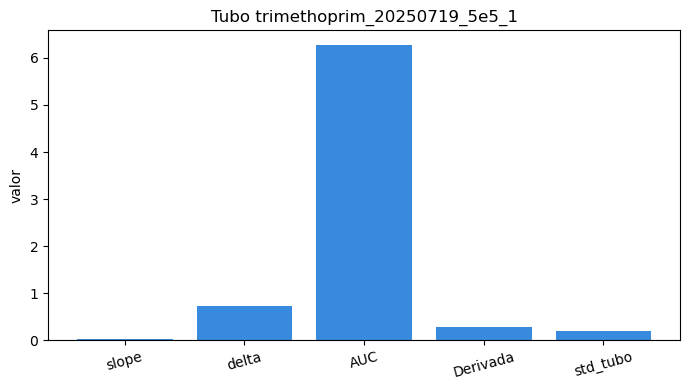

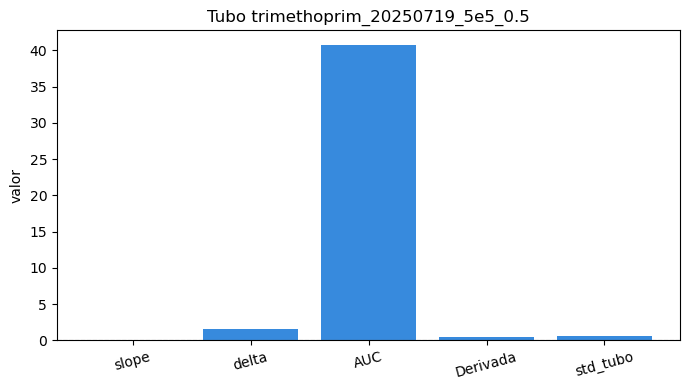

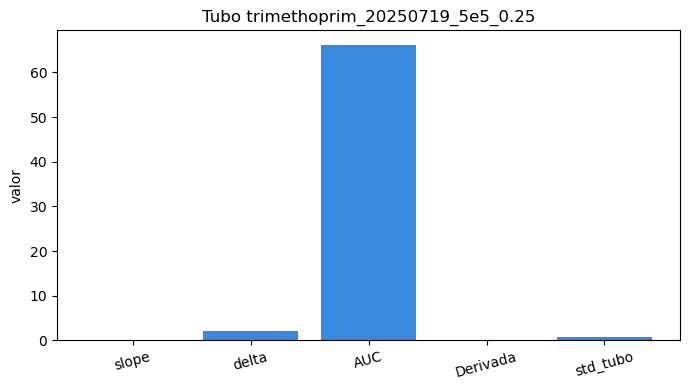

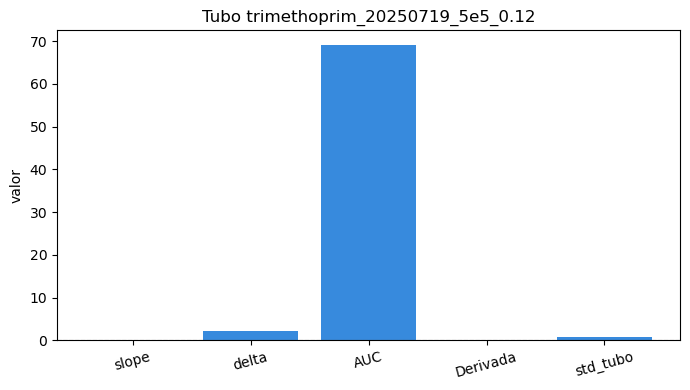

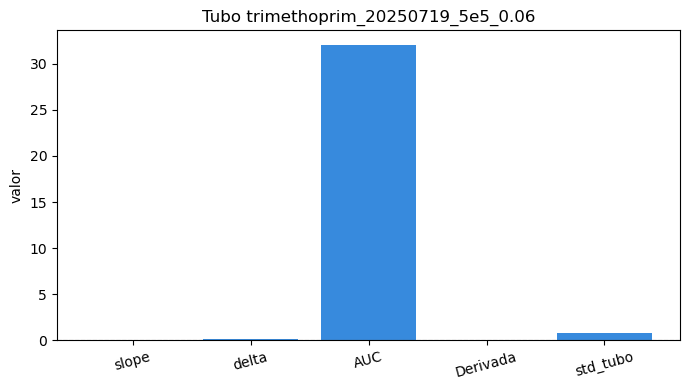

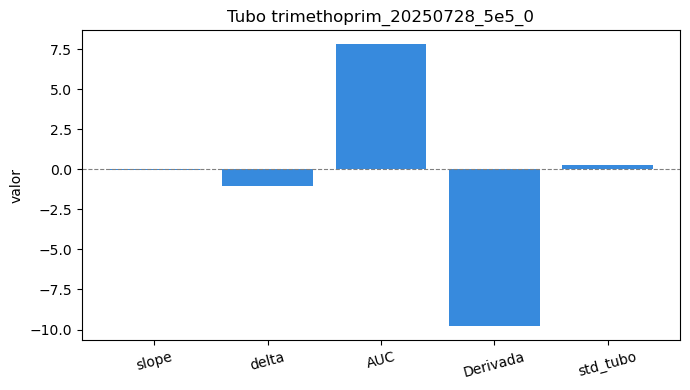

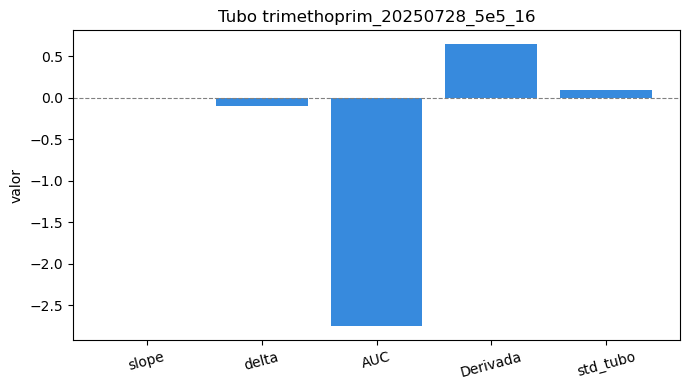

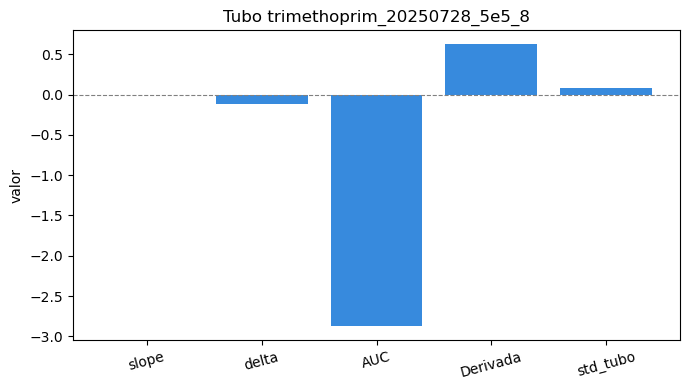

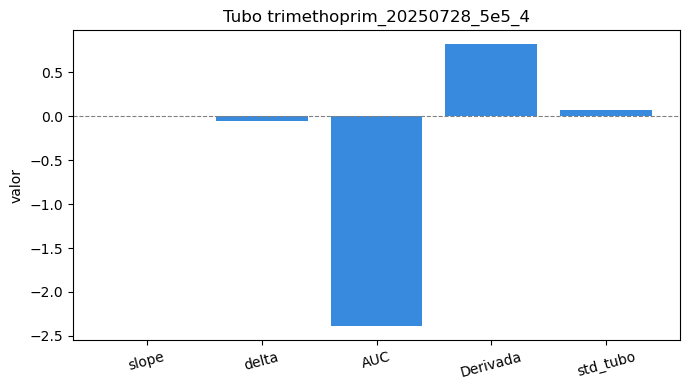

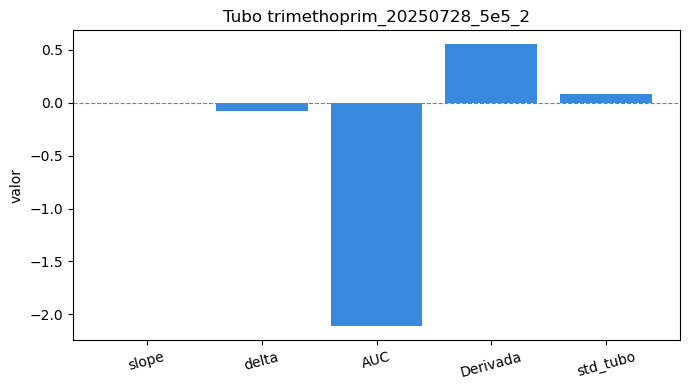

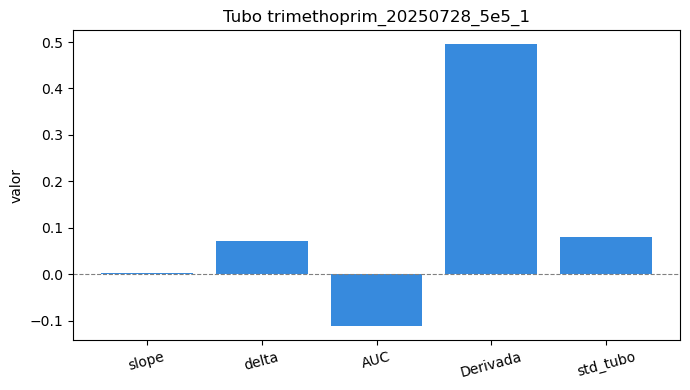

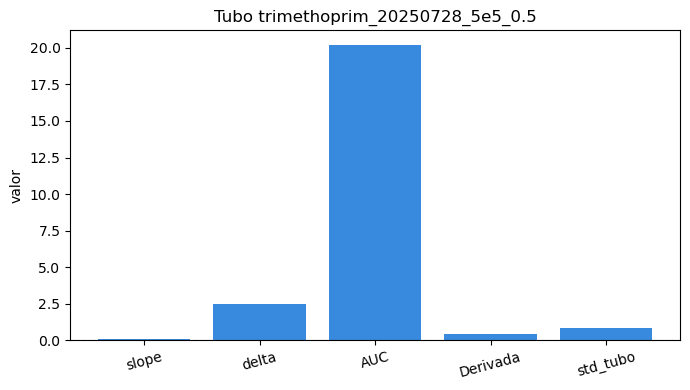

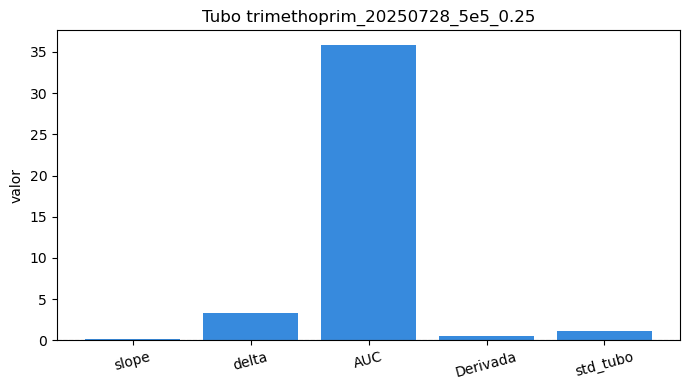

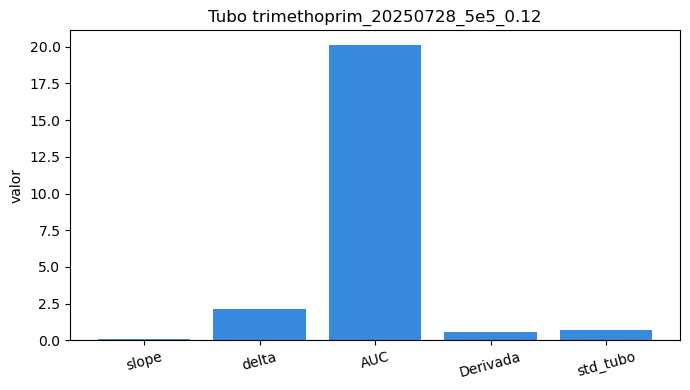

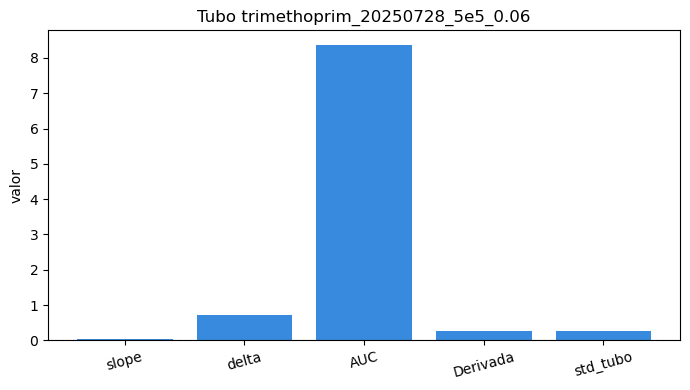

In [11]:

features = ["slope", "delta", "AUC", "Derivada", "std_tubo"]

df_final = for_ml.drop_duplicates("tubo_id", keep="last")[["tubo_id"] + features].reset_index(drop=True)

for _, row in df_final.iterrows():
    fig, ax = plt.subplots(figsize=(7, 4))
    
    ax.bar(features, row[features], color="#378ADD")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Tubo {row['tubo_id']}")
    ax.set_ylabel("valor")
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.show()

### 7.2 Label Definition

Labels are assigned based on bacterial growth, determined by the final AUC value:

| Label | Meaning | Condition |
|---|---|---|
| `0` | No growth | Final AUC ≤ 0 |
| `1` | Growth | Final AUC > 0 |

In [12]:
for id_tubo in for_ml["tubo_id"].unique():
    subset = for_ml[for_ml["tubo_id"] == id_tubo]
    ultimo = subset.iloc[-1]
    
    label = "1" if ultimo["AUC"] > 0 else "0"
    
    for_ml.loc[for_ml["tubo_id"] == id_tubo, "label"] = label

In [13]:
display(for_ml)

,experiencia,tubo_id,antibiotico,concentração,tempo,gvr,std_inicial,std_atual,std_tubo,slope,delta,AUC,Derivada,label
0,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.000000,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.000000,0.000000,1
1,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.166667,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.011647,0.000000,1
2,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.333333,-0.139765,0.008784,0.017568,0.098829,-0.628944,-0.209648,0.005824,-1.257887,1
3,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.500000,-0.199132,0.008784,0.025127,0.121492,-0.538028,-0.269014,-0.022418,-0.356198,1
4,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0,0.666667,-0.119479,0.008784,0.024350,0.112185,-0.284042,-0.189362,-0.048969,0.477916,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45337,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.333333,0.648233,0.023087,1.163355,0.271984,0.031497,0.640442,7.913390,-0.121403,1
45338,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.500000,0.663801,0.023087,1.156492,0.272000,0.032000,0.656010,8.022726,0.093407,1
45339,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.666667,0.657226,0.023087,1.162899,0.271947,0.031424,0.649435,8.132812,-0.039450,1
45340,trimethoprim_20250728_5e5,trimethoprim_20250728_5e5_0.06,trimethoprim,0.06,20.833333,0.688446,0.023087,1.206671,0.272131,0.032671,0.680656,8.244951,0.187322,1


### 8. Save Dataset

In [14]:
for_ml.to_csv("ecoli_data_ml.csv", index=False)

print("Dataset saved successfully.")
print(f"  Shape  : {for_ml.shape}")
print(f"  Labels : {for_ml['label'].value_counts()}")

Dataset saved successfully.
  Shape  : (45342, 14)
  Labels : label
1    27768
0    17574
Name: count, dtype: int64
